<a href="https://colab.research.google.com/github/basmafm/ecommerce-api-testing/blob/main/Tesis_Basma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ANALISIS
SENTIMEN TERHADAP REVISI UU TNI DI MEDIA SOSIAL X (TWITTER)**

#Setup Awal & Persiapan Environment

## Cell 1 - Setup Inti & Setup Library

In [ ]:
# ====================================================
# Cell 1a — Setup inti (numpy, pandas, scikit-learn)
# Kunci versi inti biar stabil di Colab Py3.12.
# Kalau beda versi setelah install -> sarankan restart runtime.
# ====================================================
import sys, subprocess, importlib, warnings, os, threading, itertools, time
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["PIP_NO_INPUT"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Spinner kecil biar ada progress visual
class Spinner:
    def __init__(self, text="Processing"):
        self.text = text
        self._it = itertools.cycle(["|","/","-","\\"])
        self._stop = False
        self._thr = threading.Thread(target=self._spin, daemon=True)
    def _spin(self):
        while not self._stop:
            sys.stdout.write(f"\r{self.text} {next(self._it)}")
            sys.stdout.flush()
            time.sleep(0.1)
    def start(self): self._thr.start()
    def stop(self):
        self._stop = True
        self._thr.join()
        sys.stdout.write("\r" + " " * 80 + "\r"); sys.stdout.flush()

def pip_install(*pkgs):
    sp = Spinner("Installing " + " ".join(pkgs))
    sp.start()
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "--no-cache-dir", *pkgs],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
    finally:
        sp.stop()
    print(f"  ✓ {' '.join(pkgs)}")

target = {
    "numpy": "2.0.2",
    "pandas": "2.3.2",
    "scikit-learn": "1.5.2",
}

print("[INFO] Pasang paket inti (numpy/pandas/sklearn)…")
pip_install(f"numpy=={target['numpy']}", f"pandas=={target['pandas']}", f"scikit-learn=={target['scikit-learn']}")

def ver(mod):
    try:
        m = importlib.import_module(mod)
        return getattr(m, "__version__", "not-found")
    except Exception:
        return "not-found"

print("\n[INFO] Versi paket inti (current / target):")
cur_numpy  = ver("numpy");   print(f"  numpy        : {cur_numpy} / {target['numpy']}")
cur_pandas = ver("pandas");  print(f"  pandas       : {cur_pandas} / {target['pandas']}")
cur_skl    = ver("sklearn"); print(f"  scikit-learn : {cur_skl} / {target['scikit-learn']}")

need_restart = (cur_numpy != target["numpy"]) or (cur_pandas != target["pandas"]) or (cur_skl != target["scikit-learn"])
if need_restart:
    print("\n⚠️  Saran: Runtime → Restart runtime, lalu jalankan Cell 1a lagi.")
else:
    print("\n[READY] Paket inti sudah stabil. Lanjut ke Cell 1b ✅")

[INFO] Pasang paket inti (numpy/pandas/sklearn)…
  ✓ numpy==2.0.2 pandas==2.3.2 scikit-learn==1.5.2

[INFO] Versi paket inti (current / target):
  numpy        : 2.0.2 / 2.0.2
  pandas       : 2.3.2 / 2.3.2
  scikit-learn : 1.5.2 / 1.5.2

[READY] Paket inti sudah stabil. Lanjut ke Cell 1b ✅


In [ ]:
# ====================================================
# Cell 1b — Setup library tambahan (tanpa gensim)
# - TF 2.20 (stabil untuk Py3.12)
# - pyLDAvis (kita pakai untuk sklearn LDA)
# - statsmodels (buat kappa/Fleiss)
# Setelah install, cek versi & pastikan core tidak berubah.
# ====================================================
import sys, subprocess, importlib, warnings, os, threading, itertools, time
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["PIP_NO_INPUT"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

class Spinner:
    def __init__(self, text="Processing"):
        self.text = text
        self._it = itertools.cycle(["|","/","-","\\"])
        self._stop = False
        self._thr = threading.Thread(target=self._spin, daemon=True)
    def _spin(self):
        while not self._stop:
            sys.stdout.write(f"\r{self.text} {next(self._it)}")
            sys.stdout.flush()
            time.sleep(0.1)
    def start(self): self._thr.start()
    def stop(self):
        self._stop = True
        self._thr.join()
        sys.stdout.write("\r" + " " * 80 + "\r"); sys.stdout.flush()

def pip_install(pkg):
    sp = Spinner(f"Installing {pkg}")
    sp.start()
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", pkg],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    finally:
        sp.stop()
    print(f"  ✓ {pkg}")

def ver(mod):
    try:
        m = importlib.import_module(mod)
        return getattr(m, "__version__", "not-found")
    except Exception:
        return "not-found"

extra = [
    "tensorflow==2.20.0",
    "keras",              # otomatis cocok dgn TF 2.20
    "transformers",
    "datasets",
    "accelerate",
    "evaluate",
    "sentencepiece",
    "pyLDAvis",           # dipakai utk visualisasi LDA (sklearn)
    "emoji",
    "wordcloud",
    "seaborn",
    "jedi",
    "statsmodels",        # untuk Fleiss' kappa (QA labeling)
]

print("[INFO] Install library tambahan…")
for p in extra:
    pip_install(p)

# ringkasan versi lib tambahan
mods = ["tensorflow","keras","transformers","datasets","accelerate","evaluate","pyLDAvis","seaborn","wordcloud","statsmodels"]
print("\n[INFO] Versi library tambahan:")
for m in mods:
    print(f"  {m:<12}: {ver(m)}")

# cek ulang core tidak berubah
def ver_core(mod):
    try:
        return importlib.import_module(mod).__version__
    except:
        return "not-found"
core_now = {"numpy":ver_core("numpy"), "pandas":ver_core("pandas"), "scikit-learn":ver_core("sklearn")}
print("\n[INFO] Cek ulang paket inti (should stay the same):")
print(f"  numpy        : {core_now['numpy']}")
print(f"  pandas       : {core_now['pandas']}")
print(f"  scikit-learn : {core_now['scikit-learn']}")

print("\n[READY] Library tambahan terpasang. Lanjut ke Cell 2 ✅")

[INFO] Install library tambahan…
  ✓ tensorflow==2.20.0
  ✓ keras
  ✓ transformers
  ✓ datasets
  ✓ accelerate
  ✓ evaluate
  ✓ sentencepiece
  ✓ pyLDAvis
  ✓ emoji
  ✓ wordcloud
  ✓ seaborn
  ✓ jedi
  ✓ statsmodels

[INFO] Versi library tambahan:
  tensorflow  : 2.20.0
  keras       : 3.10.0
  transformers: 4.57.1
  datasets    : 4.0.0
  accelerate  : 1.10.1
  evaluate    : 0.4.6


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  pyLDAvis    : 3.4.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  seaborn     : 0.13.2
  wordcloud   : 1.9.4
  statsmodels : 0.14.5

[INFO] Cek ulang paket inti (should stay the same):
  numpy        : 2.0.2
  pandas       : 2.3.2
  scikit-learn : 1.5.2

[READY] Library tambahan terpasang. Lanjut ke Cell 2 ✅


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Cell 2 - Import Library

In [ ]:
# ====================================================
# Cell 2 — Import Library Utama
# Siap untuk 3 dataset (tni1 berlabel, tni2 & tni3 auto-label),
# dan 3 tahap model: tradisional → deep learning → transformer.
# ====================================================

# core
import os, sys, re, string, random, importlib, warnings, gc, time, emoji
from datetime import datetime
from collections import Counter

# data
import numpy as np
import pandas as pd

# visual
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# tradisional (sklearn)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# deep learning (Keras/TensorFlow)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Embedding, LSTM, Bidirectional,
    Conv1D, GlobalMaxPooling1D, Dropout, Input
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# transformer (HuggingFace)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)

# topic modeling
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis

# style plot
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# info ringkas environment
print("[INFO] Versi library:")
print(f"  Python      : {sys.version.split()[0]}")
print(f"  numpy       : {np.__version__}")
print(f"  pandas      : {pd.__version__}")
import sklearn as _sk
print(f"  sklearn     : {_sk.__version__}")
print(f"  tensorflow  : {tf.__version__}")
print(f"  transformers: {importlib.import_module('transformers').__version__}")
print(f"  pyLDAvis    : {pyLDAvis.__version__}")

print("\n[READY] Import selesai. Lanjut ke konfigurasi (Cell 3) ✅")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[INFO] Versi library:
  Python      : 3.12.12
  numpy       : 2.0.2
  pandas      : 2.3.2
  sklearn     : 1.5.2
  tensorflow  : 2.20.0
  transformers: 4.57.1
  pyLDAvis    : 3.4.0

[READY] Import selesai. Lanjut ke konfigurasi (Cell 3) ✅


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Cell 3 - Config & Flag Model

In [ ]:
# ====================================================
# Cell 3 — Konfigurasi Global & Flag Model (3 Dataset)
# ====================================================

import os, json, random
import numpy as np

# --- 1) Reproducibility (seed) ---
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# kalau ada torch/tf, sekalian set
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
except Exception:
    pass

# --- 2) Path Dataset (Drive) ---
#  - tni1.xlsx = BERLABEL (manual / gold)
#  - tni2.xlsx = TANPA label (nanti auto-label)
#  - tni3.xlsx = TANPA label (nanti auto-label)
DATA_FILES = [
    "/content/drive/MyDrive/Dataset/tni1.xlsx",
    "/content/drive/MyDrive/Dataset/tni2.xlsx",
    "/content/drive/MyDrive/Dataset/tni3.xlsx",
]

# direktori output (model, metrik, gambar, dsb.)
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 3) Kandidat Nama Kolom (supaya fleksibel) ---
TEXT_COL_CANDIDATES  = ["clean_text", "text_clean", "preprocessed_text", "full_text", "text"]
LABEL_COL_CANDIDATES = ["sentimen", "label", "target"]
TIME_COL_CANDIDATES  = ["created_at", "time", "tanggal", "date"]
USER_COL_CANDIDATES  = ["username", "user", "account", "screen_name"]

# --- 4) Skema Label Target (final 3 kelas) ---
SENTIMENT_ORDER = ["negative", "neutral", "positive"]

# --- 5) Flag Model (total 10) ---
# a) Tradisional (TF-IDF + classifier)
ENABLE_TRADITIONAL = True    # master switch tradisional
ENABLE_LR   = True           # Logistic Regression: baseline kuat & cepat
ENABLE_NB   = True           # Multinomial Naive Bayes: efisien untuk teks kategori
ENABLE_SVM  = True           # Linear SVM: bagus di high-dim sparse (TF-IDF)
ENABLE_RF   = True           # Random Forest: ensemble pohon, non-linear

# b) Deep Learning klasik (Keras)
ENABLE_DL_CLASSIC   = True   # master switch DL klasik
ENABLE_CNN_TEXT     = True   # CNN-Text: tangkap pola lokal (n-gram)
ENABLE_BILSTM       = True   # BiLSTM: memori urutan dua arah
ENABLE_BILSTM_CNN   = True   # BiLSTM-CNN: gabungan LSTM + CNN

# c) Transformer (HuggingFace)
ENABLE_TRANSFORMER  = True   # master switch transformer
ENABLE_INDOBERT     = True   # IndoBERT (indobenchmark/indobert-base-p2)
ENABLE_MBERT_XLMR   = True   # mBERT atau XLM-R (pilih salah satu basis)
ENABLE_BERT_CNN     = True   # BERT backbone + CNN head

# --- 6) Parameter Umum ---
# TF-IDF
TFIDF_NGRAM  = (1, 2)
TFIDF_MIN_DF = 3
TFIDF_MAX_DF = 0.95

# Deep Learning klasik (Keras)
MAX_SEQ_LEN         = 256
MAX_VOCAB           = 50_000
EMB_DIM             = 128
BATCH_DL            = 64
EPOCHS_DL           = 15
EARLY_STOP_PATIENCE = 3

# Transformer (HF Trainer)
TRANSF_MAXLEN    = 256
TRANSF_LR        = 2e-5
TRANSF_EPOCHS    = 3
TRANSF_BS_TRAIN  = 16
TRANSF_BS_EVAL   = 32

# --- 7) Logger kecil & info perangkat ---
def log(msg): print(f"[CFG] {msg}")

def _device_info():
    info = {}
    try:
        import torch
        info["torch"] = f"{torch.__version__} / cuda={torch.cuda.is_available()}"
    except Exception:
        info["torch"] = "n/a"
    try:
        import tensorflow as tf
        gpus = tf.config.list_physical_devices("GPU")
        info["tf"] = getattr(tf, "__version__", "n/a")
        info["tf_gpu"] = len(gpus)
    except Exception:
        info["tf"] = "n/a"; info["tf_gpu"] = "n/a"
    return info

# --- 8) Ringkasan cepat ---
log(f"Seed                 : {SEED}")
log(f"Jumlah file dataset  : {len(DATA_FILES)}")
for i, p in enumerate(DATA_FILES, 1):
    print(f"   {i:>2}. {p}")

log(f"Output dir           : {OUTPUT_DIR}")
log(f"Target classes       : {', '.join(SENTIMENT_ORDER)}")

active_trad = [n for n, f in {"LR":ENABLE_LR, "NB":ENABLE_NB, "SVM":ENABLE_SVM, "RF":ENABLE_RF}.items() if f]
active_dl   = [n for n, f in {"CNN-Text":ENABLE_CNN_TEXT, "BiLSTM":ENABLE_BILSTM, "BiLSTM-CNN":ENABLE_BILSTM_CNN}.items() if f]
active_trf  = [n for n, f in {"IndoBERT":ENABLE_INDOBERT, "mBERT/XLM-R":ENABLE_MBERT_XLMR, "BERT+CNN":ENABLE_BERT_CNN}.items() if f]

log(f"Tradisional aktif    : {', '.join(active_trad)}")
log(f"DL klasik aktif      : {', '.join(active_dl)}")
log(f"Transformer aktif    : {', '.join(active_trf)}")

dev = _device_info()
log(f"Torch                : {dev.get('torch')}")
log(f"TensorFlow (GPU)     : {dev.get('tf')} (GPU={dev.get('tf_gpu')})")

# --- 9) Simpan CONFIG (dipakai cell berikutnya) ---
CONFIG = {
    "seed": SEED,
    "data_files": DATA_FILES,
    "output_dir": OUTPUT_DIR,
    "text_col_candidates": TEXT_COL_CANDIDATES,
    "label_col_candidates": LABEL_COL_CANDIDATES,
    "time_col_candidates": TIME_COL_CANDIDATES,
    "user_col_candidates": USER_COL_CANDIDATES,
    "sentiment_order": SENTIMENT_ORDER,
    "flags": {
        "traditional": active_trad,
        "dl_classic": active_dl,
        "transformer": active_trf,
        "enable_groups": {
            "traditional": ENABLE_TRADITIONAL,
            "dl_classic": ENABLE_DL_CLASSIC,
            "transformer": ENABLE_TRANSFORMER,
        }
    },
    "tfidf": {
        "ngram_range": TFIDF_NGRAM,
        "min_df": TFIDF_MIN_DF,
        "max_df": TFIDF_MAX_DF,
    },
    "dl_params": {
        "max_seq_len": MAX_SEQ_LEN,
        "max_vocab": MAX_VOCAB,
        "emb_dim": EMB_DIM,
        "batch": BATCH_DL,
        "epochs": EPOCHS_DL,
        "early_stop_patience": EARLY_STOP_PATIENCE,
    },
    "transformer_params": {
        "max_len": TRANSF_MAXLEN,
        "lr": TRANSF_LR,
        "epochs": TRANSF_EPOCHS,
        "bs_train": TRANSF_BS_TRAIN,
        "bs_eval": TRANSF_BS_EVAL,
    },
}

cfg_path = os.path.join(OUTPUT_DIR, "config_run.json")
with open(cfg_path, "w") as f:
    json.dump(CONFIG, f, indent=2)
print(f"[CFG] Config tersimpan → {cfg_path}")

[CFG] Seed                 : 42
[CFG] Jumlah file dataset  : 3
    1. /content/drive/MyDrive/Dataset/tni1.xlsx
    2. /content/drive/MyDrive/Dataset/tni2.xlsx
    3. /content/drive/MyDrive/Dataset/tni3.xlsx
[CFG] Output dir           : /content/outputs
[CFG] Target classes       : negative, neutral, positive
[CFG] Tradisional aktif    : LR, NB, SVM, RF
[CFG] DL klasik aktif      : CNN-Text, BiLSTM, BiLSTM-CNN
[CFG] Transformer aktif    : IndoBERT, mBERT/XLM-R, BERT+CNN
[CFG] Torch                : 2.8.0+cu126 / cuda=True
[CFG] TensorFlow (GPU)     : 2.20.0 (GPU=1)
[CFG] Config tersimpan → /content/outputs/config_run.json


## Cell 4 - Mount Google Drive

In [ ]:
# ====================================================
# Cell 4 — Mount Google Drive & Validasi Dataset
# ====================================================
from google.colab import drive
import os

print("[INFO] Mounting Google Drive…")
drive.mount("/content/drive")

# pastikan folder output ada
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[INFO] Output dir: {OUTPUT_DIR} (siap)")

# cek 3 file dataset
print("\n[INFO] Validasi file dataset (target 3 file):")
missing = []
for i, p in enumerate(DATA_FILES, 1):
    ok = os.path.exists(p)
    print(f"  {i:>2}. {p}\n     ↳ {'✅ ditemukan' if ok else '❌ TIDAK ditemukan'}")
    if not ok:
        missing.append(p)

if missing:
    print("\n⚠️ Ada file yang belum ketemu. Silakan cek path di Cell 3:")
    for p in missing:
        print("   -", p)
else:
    print("\n[READY] Semua file dataset ditemukan. Lanjut ke load & cleaning (Cell 5) ✅")

[INFO] Mounting Google Drive…
Mounted at /content/drive
[INFO] Output dir: /content/outputs (siap)

[INFO] Validasi file dataset (target 3 file):
   1. /content/drive/MyDrive/Dataset/tni1.xlsx
     ↳ ✅ ditemukan
   2. /content/drive/MyDrive/Dataset/tni2.xlsx
     ↳ ✅ ditemukan
   3. /content/drive/MyDrive/Dataset/tni3.xlsx
     ↳ ✅ ditemukan

[READY] Semua file dataset ditemukan. Lanjut ke load & cleaning (Cell 5) ✅


# Pengumpulan Data

## Cell 1 - Load Dataset & Cleaning

In [ ]:
# ====================================================
# Cell 1 — Load Dataset & Cleaning Awal
# ====================================================
import re, string
import pandas as pd

# helper: baca file apa saja
def read_any(path):
    if path.lower().endswith(".csv"):
        return pd.read_csv(path)
    elif path.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(path)
    else:
        raise ValueError(f"Format file tidak dikenali: {path}")

# helper: deteksi kolom dari kandidat
def detect_col(cands, cols):
    for c in cands:
        if c in cols: return c
    return None

# cleaner sederhana
URL_RE   = re.compile(r"http\S+|www\.\S+")
MENT_RE  = re.compile(r"@\w+")
HASH_RE  = re.compile(r"#\w+")
SPACE_RE = re.compile(r"\s+")

def clean_text(s: str) -> str:
    s = str(s).lower()
    s = URL_RE.sub(" ", s)
    s = MENT_RE.sub(" ", s)
    s = HASH_RE.sub(" ", s)
    s = emoji.replace_emoji(s, replace=" ")
    s = s.translate(str.maketrans("", "", string.punctuation))
    s = SPACE_RE.sub(" ", s).strip()
    return s

# 1) load tiga dataset
df1 = read_any(DATA_FILES[0])   # tni1 (berlabel)
df2 = read_any(DATA_FILES[1])   # tni2 (unlabeled)
df3 = read_any(DATA_FILES[2])   # tni3 (unlabeled)

print("[INFO] Shape awal:")
print(f"  tni1 (berlabel) : {df1.shape}")
print(f"  tni2 (unlabeled): {df2.shape}")
print(f"  tni3 (unlabeled): {df3.shape}")

# 2) deteksi kolom penting
TEXT_COL_1  = detect_col(TEXT_COL_CANDIDATES, df1.columns)
LABEL_COL_1 = detect_col(LABEL_COL_CANDIDATES, df1.columns)
TIME_COL_1  = detect_col(TIME_COL_CANDIDATES, df1.columns)
USER_COL_1  = detect_col(USER_COL_CANDIDATES, df1.columns)

TEXT_COL_2  = detect_col(TEXT_COL_CANDIDATES + ["full_text","text"], df2.columns)
TIME_COL_2  = detect_col(TIME_COL_CANDIDATES, df2.columns)
USER_COL_2  = detect_col(USER_COL_CANDIDATES, df2.columns)

TEXT_COL_3  = detect_col(TEXT_COL_CANDIDATES + ["full_text","text"], df3.columns)
TIME_COL_3  = detect_col(TIME_COL_CANDIDATES, df3.columns)
USER_COL_3  = detect_col(USER_COL_CANDIDATES, df3.columns)

assert TEXT_COL_1 and LABEL_COL_1, "Kolom text/label tni1 tidak ditemukan. Cek nama kolom!"
assert TEXT_COL_2, "Kolom text tni2 tidak ditemukan!"
assert TEXT_COL_3, "Kolom text tni3 tidak ditemukan!"

print("\n[INFO] Kolom terdeteksi:")
print(f"  tni1: text='{TEXT_COL_1}', label='{LABEL_COL_1}', time='{TIME_COL_1}', user='{USER_COL_1}'")
print(f"  tni2: text='{TEXT_COL_2}', time='{TIME_COL_2}', user='{USER_COL_2}'")
print(f"  tni3: text='{TEXT_COL_3}', time='{TIME_COL_3}', user='{USER_COL_3}'")

# 3) cleaning awal
df1["clean_text"] = df1[TEXT_COL_1].astype(str).apply(clean_text)
df2["clean_text"] = df2[TEXT_COL_2].astype(str).apply(clean_text)
df3["clean_text"] = df3[TEXT_COL_3].astype(str).apply(clean_text)

print("\n[READY] Cleaning awal selesai ✅")
print("  contoh tni1:", df1["clean_text"].iloc[0][:100] if len(df1) else "-")
print("  contoh tni2:", df2["clean_text"].iloc[0][:100] if len(df2) else "-")
print("  contoh tni3:", df3["clean_text"].iloc[0][:100] if len(df3) else "-")

[INFO] Shape awal:
  tni1 (berlabel) : (5040, 17)
  tni2 (unlabeled): (5040, 17)
  tni3 (unlabeled): (5040, 17)

[INFO] Kolom terdeteksi:
  tni1: text='full_text', label='sentimen', time='created_at', user='username'
  tni2: text='full_text', time='created_at', user='username'
  tni3: text='full_text', time='created_at', user='username'

[READY] Cleaning awal selesai ✅
  contoh tni1: menurut akademisi dan pengamat militer revisi uu tni menambah tugas pertahanan dan keamanan sehingga
  contoh tni2: menurut akademisi dan pengamat militer revisi uu tni menambah tugas pertahanan dan keamanan sehingga
  contoh tni3: menurut akademisi dan pengamat militer revisi uu tni menambah tugas pertahanan dan keamanan sehingga


##Cell 2 - Duplicate & Missing Value


In [ ]:
# 4) Cek duplikat
print("\n[INFO] Jumlah duplikat:")
print(f"  tni1: {df1.duplicated(subset='clean_text').sum()} duplikat")
print(f"  tni2: {df2.duplicated(subset='clean_text').sum()} duplikat")
print(f"  tni3: {df3.duplicated(subset='clean_text').sum()} duplikat")

df1.drop_duplicates(subset='clean_text', inplace=True)
df2.drop_duplicates(subset='clean_text', inplace=True)
df3.drop_duplicates(subset='clean_text', inplace=True)

# 5) Cek missing value
print("\n[INFO] Missing value di kolom clean_text:")
print(f"  tni1: {df1['clean_text'].isna().sum()} missing")
print(f"  tni2: {df2['clean_text'].isna().sum()} missing")
print(f"  tni3: {df3['clean_text'].isna().sum()} missing")

df1.dropna(subset=['clean_text'], inplace=True)
df2.dropna(subset=['clean_text'], inplace=True)
df3.dropna(subset=['clean_text'], inplace=True)


[INFO] Jumlah duplikat:
  tni1: 0 duplikat
  tni2: 0 duplikat
  tni3: 0 duplikat

[INFO] Missing value di kolom clean_text:
  tni1: 0 missing
  tni2: 0 missing
  tni3: 0 missing


In [ ]:
print(f"[INFO] Jumlah data untuk tni1: {len(df1)} tweet")
print(f"[INFO] Jumlah data untuk tni2: {len(df2)} tweet")
print(f"[INFO] Jumlah data untuk tni3: {len(df3)} tweet")

[INFO] Jumlah data untuk tni1: 5040 tweet
[INFO] Jumlah data untuk tni2: 5040 tweet
[INFO] Jumlah data untuk tni3: 5040 tweet


#Split Data Berdasarkan Waktu

In [ ]:
# ====================================================
# Cell 1 — Split Data Berdasarkan Waktu (tni1 manual)
# Tujuan: simulasi kondisi nyata & hindari data leakage
# ====================================================

from datetime import datetime

df1[TIME_COL_1] = pd.to_datetime(df1[TIME_COL_1], errors="coerce")

df1 = df1.dropna(subset=[TIME_COL_1])

df1_sorted = df1.sort_values(TIME_COL_1)

split_idx = int(0.8 * len(df1_sorted))
df1_train = df1_sorted.iloc[:split_idx].copy()
df1_val   = df1_sorted.iloc[split_idx:].copy()

print("[INFO] Split berdasarkan waktu selesai ✅")
print(f"  Train : {len(df1_train)} tweet")
print(f"  Val   : {len(df1_val)} tweet")
print(f"  Range waktu train : {df1_train[TIME_COL_1].min()} → {df1_train[TIME_COL_1].max()}")
print(f"  Range waktu val   : {df1_val[TIME_COL_1].min()} → {df1_val[TIME_COL_1].max()}")

[INFO] Split berdasarkan waktu selesai ✅
  Train : 4032 tweet
  Val   : 1008 tweet
  Range waktu train : 2025-02-06 18:27:22+00:00 → 2025-04-24 22:02:04+00:00
  Range waktu val   : 2025-04-24 23:28:49+00:00 → 2025-06-16 14:58:11+00:00


#Labelling Sentimen

## Cell 1 - Encode Label & Stratified Split

In [ ]:
# ============================================
# 🏷️ Cell 4 — Encode Label & Stratified Split
# ============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# --- 1) Normalisasi label manual ke skema 3 kelas ---
_norm = {
    "negatif": "negative", "neg": "negative", "-1": "negative",
    "positif": "positive", "pos": "positive", "+1": "positive",
    "netral": "neutral", "ntrl": "neutral", "0": "neutral"
}

df1[LABEL_COL_1] = (
    df1[LABEL_COL_1]
    .astype(str).str.lower().str.strip()
    .map(lambda x: _norm.get(x, x))
)

# --- 2) Filter hanya label valid ---
valid_lbl = set(SENTIMENT_ORDER)
before_filter = len(df1)
df1 = df1[df1[LABEL_COL_1].isin(valid_lbl)].copy()
after_filter = len(df1)
assert not df1.empty, "tni1 kosong setelah filter label. Cek isi kolom label!"

print(f"[INFO] Jumlah data tni1 sebelum filter label: {before_filter}")
print(f"[INFO] Setelah filter label valid: {after_filter}")

# --- 3) Mapping label <-> ID ---
label2id = {lab: i for i, lab in enumerate(SENTIMENT_ORDER)}
id2label = {i: lab for lab, i in label2id.items()}
df1["__label_id"] = df1[LABEL_COL_1].map(label2id).astype(int)

# --- 4) Pastikan kolom waktu ke datetime (jika ada) ---
def _to_datetime_safe(s):
    try:
        return pd.to_datetime(s, errors="coerce", utc=True)
    except Exception:
        return pd.to_datetime(s.astype(str), errors="coerce", utc=True)

if TIME_COL_1 and TIME_COL_1 in df1.columns:
    df1[TIME_COL_1] = _to_datetime_safe(df1[TIME_COL_1])

# --- 5) Stratified Split untuk modeling ---
X_all = df1["clean_text"].astype(str).values
y_all = df1["__label_id"].values

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

def _dist(y):
    u, c = np.unique(y, return_counts=True)
    return {id2label[int(i)]: int(v) for i, v in zip(u, c)}

print("\n[INFO] Split tni1 → train/val (stratified)")
print(f"  Train: {len(X_train)} | Val: {len(X_val)}")
print(f"  Distribusi Train: {_dist(y_train)}")
print(f"  Distribusi Val  : {_dist(y_val)}")

# --- 6) Simpan hasil split ke dict global ---
DATA_SPLIT = {
    "X_train": X_train, "y_train": y_train,
    "X_val":   X_val,   "y_val":   y_val,
    "label_map": label2id,
    "id2label": id2label,
    "text_col": TEXT_COL_1,
    "label_col": LABEL_COL_1,
    "time_col": TIME_COL_1,
}

print("\n[READY] Label encoded & split siap. Lanjut ke auto-label tni2 & tni3 ✅")

[INFO] Jumlah data tni1 sebelum filter label: 5040
[INFO] Setelah filter label valid: 5040

[INFO] Split tni1 → train/val (stratified)
  Train: 4032 | Val: 1008
  Distribusi Train: {'negative': 2194, 'neutral': 1222, 'positive': 616}
  Distribusi Val  : {'negative': 548, 'neutral': 306, 'positive': 154}

[READY] Label encoded & split siap. Lanjut ke auto-label tni2 & tni3 ✅


## Cell 2 - Auto-label tni2 & tni3 (TF-IDF + LinearSVC)

In [ ]:
# ====================================================
# Cell 2 — Auto-label tni2 & tni3 (TF-IDF + LinearSVC)
#   • Train baseline di tni1 (train)
#   • Prediksi label untuk tni2 & tni3
#   • Simpan hasil autolabel ke OUTPUT_DIR (Excel, tz-naive)
#   • Tampilkan 10 contoh hasil untuk tni2 & tni3
# ====================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
import numpy as np
import pandas as pd
import os

# 1) Vectorizer + model baseline (latih dari tni1 train)
tfidf_base = TfidfVectorizer(
    ngram_range=TFIDF_NGRAM,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF
)
Xtr_base = tfidf_base.fit_transform(DATA_SPLIT["X_train"])
ytr_base = DATA_SPLIT["y_train"]

svm_base = LinearSVC()
svm_base.fit(Xtr_base, ytr_base)

# 2) Helper autolabel
def autolabel_df(df_in, name="tniX", time_col=None):
    texts = df_in["clean_text"].astype(str).values
    X = tfidf_base.transform(texts)
    y_pred = svm_base.predict(X)

    # pseudo-confidence (margin decision_function)
    try:
        dec = svm_base.decision_function(X)
        conf = np.abs(dec) if dec.ndim == 1 else np.max(dec, axis=1)
    except Exception:
        conf = np.zeros(len(texts), dtype=float)

    id2label = DATA_SPLIT["id2label"]
    labels_str = [id2label[int(k)] for k in y_pred]

    out = df_in.copy()
    out["sentimen_auto"]   = labels_str
    out["auto_confidence"] = conf

    # --- parse kolom waktu → tz-naive ---
    def _to_datetime_safe(col_series):
        try:
            s = pd.to_datetime(col_series, errors="coerce", utc=True)
        except Exception:
            s = pd.to_datetime(col_series.astype(str), errors="coerce", utc=True)
        # hilangkan timezone agar bisa disimpan ke Excel
        try:
            s = s.dt.tz_localize(None)
        except Exception:
            pass
        return s

    if time_col and time_col in out.columns:
        out[time_col] = _to_datetime_safe(out[time_col])

    # cek semua kolom datetime lain → buat tz-naive juga
    for col in out.columns:
        if np.issubdtype(out[col].dtype, np.datetime64):
            try:
                if getattr(out[col].dt, "tz", None) is not None:
                    out[col] = out[col].dt.tz_localize(None)
            except Exception:
                pass

    # ringkasan distribusi
    u, c = np.unique(y_pred, return_counts=True)
    dist = {id2label[int(ui)]: int(ci) for ui, ci in zip(u, c)}
    print(f"[INFO] Distribusi auto-label ({name}): {dist}")

    # simpan ke Excel (naive datetime aman)
    fout = os.path.join(OUTPUT_DIR, f"{name}_autolabeled.xlsx")
    out.to_excel(fout, index=False)
    print(f"[OK] Disimpan → {fout}")
    return out

# 3) Jalankan untuk tni2 & tni3
df2_auto = autolabel_df(df2, name="tni2", time_col=TIME_COL_2)
df3_auto = autolabel_df(df3, name="tni3", time_col=TIME_COL_3)

# 4) Tampilkan 10 contoh hasil auto-label (rapi)
def preview_examples(df, name, text_col, time_col=None, user_col=None, n=10):
    # kolom yang ingin diprioritaskan tampil
    prefer = [col for col in [
        text_col,
        "clean_text",
        time_col if time_col else None,
        user_col if user_col else None,
        "sentimen_auto",
        "auto_confidence"
    ] if col and col in df.columns]

    # bulatkan confidence biar enak dibaca
    if "auto_confidence" in df.columns:
        df = df.copy()
        df["auto_confidence"] = df["auto_confidence"].astype(float).round(3)

    print(f"\n== Contoh {n} baris hasil auto-label: {name} ==")
    try:
        display(df[prefer].head(n))
    except Exception:
        # fallback kalau display tidak tersedia
        print(df[prefer].head(n).to_string(index=False))

# Preview 10 baris untuk tni2 & tni3
preview_examples(df2_auto, "tni2", text_col=TEXT_COL_2, time_col=TIME_COL_2, user_col=USER_COL_2, n=10)
preview_examples(df3_auto, "tni3", text_col=TEXT_COL_3, time_col=TIME_COL_3, user_col=USER_COL_3, n=10)

print("\n[READY] Auto-label & preview contoh selesai. lanjut Pengecekan Validasi Label (Cell 7a) ✅")

[INFO] Distribusi auto-label (tni2): {'negative': 2869, 'neutral': 1500, 'positive': 671}
[OK] Disimpan → /content/outputs/tni2_autolabeled.xlsx
[INFO] Distribusi auto-label (tni3): {'negative': 2869, 'neutral': 1500, 'positive': 671}
[OK] Disimpan → /content/outputs/tni3_autolabeled.xlsx

== Contoh 10 baris hasil auto-label: tni2 ==


,full_text,clean_text,created_at,username,sentimen_auto,auto_confidence
0,@vhaniiaa_ Menurut akademisi dan pengamat mili...,menurut akademisi dan pengamat militer revisi ...,2025-06-16 14:58:11,tasselem,neutral,0.541
1,@yankedaddies Setelah revisi UU TNI disahkan p...,setelah revisi uu tni disahkan pada 26 maret 2...,2025-06-16 14:57:12,Televisiii,neutral,0.728
2,Kita gak perlu rasanya meributkan disahkannya ...,kita gak perlu rasanya meributkan disahkannya ...,2025-06-16 12:05:01,OllieOllieputri,negative,0.514
3,Revisi UU TNI yang diputuskan sekarang menegas...,revisi uu tni yang diputuskan sekarang menegas...,2025-06-16 12:00:10,aliajoytobigwin,neutral,0.911
4,isu dwifungsi rame banget tapi dari pernyataan...,isu dwifungsi rame banget tapi dari pernyataan...,2025-06-16 12:00:03,Setieawati_,neutral,0.858
5,revisi uu tni disahkan maret 2025 isinya namba...,revisi uu tni disahkan maret 2025 isinya namba...,2025-06-16 12:00:03,Yurieko_,neutral,0.965
6,@your_boba28 Cari aman sih paling mungkin ngum...,cari aman sih paling mungkin ngumpet dari kedu...,2025-06-16 11:04:39,Skydrea7215897,negative,0.710
7,@your_boba28 UU TNI malah didemo lol harusnya ...,uu tni malah didemo lol harusnya 1 miliar bisa...,2025-06-16 10:48:07,pecintaikannih,negative,0.993
8,@Meme_Pemerintah Revisi UU TNI menunjukkan bah...,revisi uu tni menunjukkan bahwa negara hadir d...,2025-06-16 09:03:07,CharakaSatya,positive,0.414
9,@Meme_Pemerintah Pengesahan UU TNI memberikan ...,pengesahan uu tni memberikan landasan hukum ya...,2025-06-16 09:02:43,CharakaSatya,neutral,1.090



== Contoh 10 baris hasil auto-label: tni3 ==


,full_text,clean_text,created_at,username,sentimen_auto,auto_confidence
0,@vhaniiaa_ Menurut akademisi dan pengamat mili...,menurut akademisi dan pengamat militer revisi ...,2025-06-16 14:58:11,tasselem,neutral,0.541
1,@yankedaddies Setelah revisi UU TNI disahkan p...,setelah revisi uu tni disahkan pada 26 maret 2...,2025-06-16 14:57:12,Televisiii,neutral,0.728
2,Kita gak perlu rasanya meributkan disahkannya ...,kita gak perlu rasanya meributkan disahkannya ...,2025-06-16 12:05:01,OllieOllieputri,negative,0.514
3,Revisi UU TNI yang diputuskan sekarang menegas...,revisi uu tni yang diputuskan sekarang menegas...,2025-06-16 12:00:10,aliajoytobigwin,neutral,0.911
4,isu dwifungsi rame banget tapi dari pernyataan...,isu dwifungsi rame banget tapi dari pernyataan...,2025-06-16 12:00:03,Setieawati_,neutral,0.858
5,revisi uu tni disahkan maret 2025 isinya namba...,revisi uu tni disahkan maret 2025 isinya namba...,2025-06-16 12:00:03,Yurieko_,neutral,0.965
6,@your_boba28 Cari aman sih paling mungkin ngum...,cari aman sih paling mungkin ngumpet dari kedu...,2025-06-16 11:04:39,Skydrea7215897,negative,0.710
7,@your_boba28 UU TNI malah didemo lol harusnya ...,uu tni malah didemo lol harusnya 1 miliar bisa...,2025-06-16 10:48:07,pecintaikannih,negative,0.993
8,@Meme_Pemerintah Revisi UU TNI menunjukkan bah...,revisi uu tni menunjukkan bahwa negara hadir d...,2025-06-16 09:03:07,CharakaSatya,positive,0.414
9,@Meme_Pemerintah Pengesahan UU TNI memberikan ...,pengesahan uu tni memberikan landasan hukum ya...,2025-06-16 09:02:43,CharakaSatya,neutral,1.090



[READY] Auto-label & preview contoh selesai. lanjut Pengecekan Validasi Label (Cell 7a) ✅


[INFO] Nilai unik sentimen (setelah normalisasi):
sentimen_norm
negative    2742
neutral     1528
positive     770
Name: count, dtype: int64
✅ Semua sentimen valid (negative, neutral, positive).


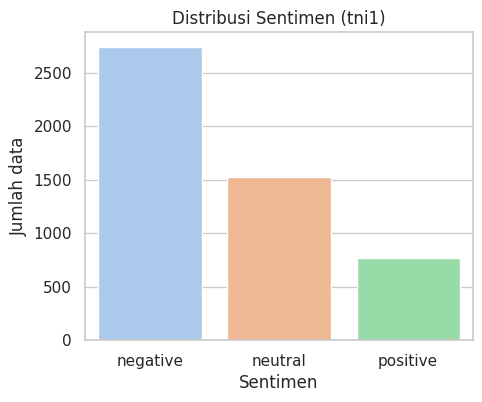

In [ ]:
# ====================================================
# — QA Validasi Label Manual
#   • Cek nilai unik di kolom sentimen
#   • Normalisasi ke 3 kelas utama (negative, neutral, positive)
#   • Deteksi label invalid
#   • Distribusi jumlah per sentimen
#   • Visualisasi bar chart
# ====================================================

import seaborn as sns
import matplotlib.pyplot as plt

LABEL_COL = LABEL_COL_1  # kolom label manual di tni1

# mapping normalisasi label
norm_map = {
    "negatif": "negative", "neg": "negative", "-1": "negative",
    "positif": "positive", "pos": "positive", "+1": "positive",
    "netral": "neutral", "ntrl": "neutral", "0": "neutral"
}

# buat kolom sentimen_norm hasil normalisasi
df1["sentimen_norm"] = (
    df1[LABEL_COL]
    .astype(str).str.lower().str.strip()
    .map(lambda x: norm_map.get(x, x))
)

# cek nilai unik
print("[INFO] Nilai unik sentimen (setelah normalisasi):")
print(df1["sentimen_norm"].value_counts())

# cek ada yang tidak valid
invalid = set(df1["sentimen_norm"].unique()) - set(SENTIMENT_ORDER)
if invalid:
    print(f"⚠️ Ada sentimen tidak valid: {invalid}")
else:
    print("✅ Semua sentimen valid (negative, neutral, positive).")

# distribusi visual
plt.figure(figsize=(5,4))
sns.countplot(
    x="sentimen_norm", data=df1,
    order=SENTIMENT_ORDER, palette="pastel"
)
plt.title("Distribusi Sentimen (tni1)")
plt.ylabel("Jumlah data")
plt.xlabel("Sentimen")
plt.show()

## Cell 3 - Validasi Fleiss’ Kappa

In [ ]:
# ====================================================
# Cell 3 — Validasi Konsistensi Label (Fleiss’ Kappa)
#   • Gabungkan label dari tni1 (manual), tni2 & tni3 (auto)
#   • Ubah ke format matriks kategori untuk 3 kelas
#   • Hitung skor Fleiss’ Kappa untuk 5000 tweet
#   • Interpretasi tingkat kesepakatan antar annotator
# ====================================================
from statsmodels.stats.inter_rater import fleiss_kappa

# pastikan label sudah distandarkan
def normalize_label(lbl):
    norm_map = {
        "negatif": "negative", "neg": "negative", "-1": "negative",
        "positif": "positive", "pos": "positive", "+1": "positive",
        "netral": "neutral", "ntrl": "neutral", "0": "neutral"
    }
    return norm_map.get(str(lbl).lower().strip(), str(lbl).lower().strip())

# ambil label dari masing-masing sumber
labels_1 = df1[LABEL_COL_1].map(normalize_label).values[:5000]
labels_2 = df2_auto["sentimen_auto"].map(normalize_label).values[:5000]
labels_3 = df3_auto["sentimen_auto"].map(normalize_label).values[:5000]

# pastikan panjang sama
assert len(labels_1) == len(labels_2) == len(labels_3), "Jumlah tweet tidak konsisten!"

# buat matriks kategori: [neg, neut, pos] → jumlah annotator per kelas
label_set = SENTIMENT_ORDER
label_to_idx = {lab: i for i, lab in enumerate(label_set)}

matrix = np.zeros((len(labels_1), len(label_set)), dtype=int)
for i, (l1, l2, l3) in enumerate(zip(labels_1, labels_2, labels_3)):
    for lbl in [l1, l2, l3]:
        idx = label_to_idx.get(lbl)
        if idx is not None:
            matrix[i, idx] += 1

# hitung Fleiss’ Kappa
kappa_score = fleiss_kappa(matrix, method='fleiss')
print(f"\n[RESULT] Fleiss’ Kappa untuk 5000 tweet: {kappa_score:.4f}")

# interpretasi sederhana
def interpret_kappa(k):
    if k < 0.0: return "Tidak ada kesepakatan"
    elif k < 0.21: return "Sangat rendah"
    elif k < 0.41: return "Rendah"
    elif k < 0.61: return "Sedang"
    elif k < 0.81: return "Tinggi"
    else: return "Sangat tinggi"

print(f"[INFO] Interpretasi: {interpret_kappa(kappa_score)}")


[RESULT] Fleiss’ Kappa untuk 5000 tweet: 0.9103
[INFO] Interpretasi: Sangat tinggi


Validasi konsistensi label dilakukan menggunakan Fleiss’ Kappa pada 5000 tweet dengan 3 sumber annotator. Hasil menunjukkan nilai 𝜅 = 0.9103, yang mengindikasikan kesepakatan sangat tinggi antar annotator.

In [ ]:
# ====================================================
# — Analisis Per Kelas & Kesepakatan Annotator
#   • Hitung distribusi total pilihan label dari 3 annotator
#   • Hitung tingkat kesepakatan per tweet (3/3, 2/3, 1/3)
#   • Identifikasi kelas paling konsisten (3 annotator setuju)
#   • Tampilkan insight distribusi dan potensi bias label
# ====================================================

from collections import Counter
import numpy as np

# 1) Distribusi total pilihan label dari 3 annotator
all_labels = np.concatenate([labels_1, labels_2, labels_3])
label_counts = Counter(all_labels)

print("[INFO] Total pilihan label dari 3 annotator:")
for label in SENTIMENT_ORDER:
    print(f"  {label:<8}: {label_counts[label]} pilihan")

# 2) Tingkat kesepakatan per tweet
agree_3 = 0
agree_2 = 0
disagree = 0

for l1, l2, l3 in zip(labels_1, labels_2, labels_3):
    unique = set([l1, l2, l3])
    if len(unique) == 1:
        agree_3 += 1
    elif len(unique) == 2:
        agree_2 += 1
    else:
        disagree += 1

print("\n[INFO] Tingkat kesepakatan per tweet:")
print(f"  Setuju semua (3/3) : {agree_3}")
print(f"  Setuju sebagian (2/3): {agree_2}")
print(f"  Tidak setuju (1/3)  : {disagree}")

# 3) Kelas paling konsisten (3 annotator setuju)
consistent_labels = []
for l1, l2, l3 in zip(labels_1, labels_2, labels_3):
    if l1 == l2 == l3:
        consistent_labels.append(l1)

consistency_counts = Counter(consistent_labels)
print("\n[INFO] Kelas paling konsisten (3/3 setuju):")
for label in SENTIMENT_ORDER:
    print(f"  {label:<8}: {consistency_counts[label]} tweet")

# 4) Insight tambahan
print("\n[INSIGHT]")
most_consistent = max(consistency_counts, key=consistency_counts.get)
least_consistent = min(consistency_counts, key=consistency_counts.get)
print(f"  🔹 Kelas paling stabil: {most_consistent}")
print(f"  🔸 Kelas paling rentan beda pendapat: {least_consistent}")
print("  💡 Pertimbangkan analisis lebih lanjut atau pelatihan khusus untuk kelas yang kurang konsisten.")

[INFO] Total pilihan label dari 3 annotator:
  negative: 8411 pilihan
  neutral : 4489 pilihan
  positive: 2100 pilihan

[INFO] Tingkat kesepakatan per tweet:
  Setuju semua (3/3) : 4612
  Setuju sebagian (2/3): 388
  Tidak setuju (1/3)  : 0

[INFO] Kelas paling konsisten (3/3 setuju):
  negative: 2629 tweet
  neutral : 1370 tweet
  positive: 613 tweet

[INSIGHT]
  🔹 Kelas paling stabil: negative
  🔸 Kelas paling rentan beda pendapat: positive
  💡 Pertimbangkan analisis lebih lanjut atau pelatihan khusus untuk kelas yang kurang konsisten.


## Cell 4 - Filter Tweet dengan Kesepakatan Penuh (3/3)

In [ ]:
agree_3 = []
for i, (l1, l2, l3) in enumerate(zip(labels_1, labels_2, labels_3)):
    if l1 == l2 == l3:
        agree_3.append(i)

df_agreed = df1.iloc[agree_3].copy()
print(f"[INFO] Data dengan kesepakatan penuh (3/3): {len(df_agreed)} tweet")

# === Override tni1_manual dengan gold standard ===
DATA_SPLIT["X_train"] = df_agreed["clean_text"].astype(str).values
DATA_SPLIT["y_train"] = df_agreed["sentimen_norm"].map(label2id).astype(int).values
print(f"[INFO] tni1_manual diganti dengan gold standard (n={len(DATA_SPLIT['X_train'])})")

[INFO] Data dengan kesepakatan penuh (3/3): 4612 tweet
[INFO] tni1_manual diganti dengan gold standard (n=4612)


In [ ]:
# ====================================================
# Cell 7d — Bandingkan Dataset dengan Baseline ML (no parallel)
#   • Baseline: TF-IDF + Logistic Regression
#   • Train di: tni1_manual, tni2_auto, tni3_auto
#   • Eval di  : val tni1 (manual)
#   • TANPA multiprocessing (hindari BrokenProcessPool/loky)
# ====================================================

import os
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Matikan paralel di level BLAS/OMP untuk stabilitas
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
# Matikan heuristik joblib/loky
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

TFIDF_ARGS = dict(ngram_range=TFIDF_NGRAM, min_df=TFIDF_MIN_DF, max_df=TFIDF_MAX_DF)

def eval_dataset(train_texts, train_labels, track_name):
    assert len(train_texts) == len(train_labels), f"Jumlah teks & label tidak sama untuk {track_name}"
    assert len(train_texts) > 0, f"Dataset kosong: {track_name}"

    tfidf = TfidfVectorizer(**TFIDF_ARGS)
    Xtr = tfidf.fit_transform(train_texts)
    Xva = tfidf.transform(DATA_SPLIT["X_val"])
    yva = np.asarray(DATA_SPLIT["y_val"], dtype=int)

    # Penting: gunakan solver 'liblinear' & n_jobs=1 (no subprocess)
    model = LogisticRegression(
        solver="liblinear",
        max_iter=300,
        random_state=SEED,
        n_jobs=1
    )
    model.fit(Xtr, train_labels)
    ypred = model.predict(Xva)

    acc = accuracy_score(yva, ypred)
    pre = precision_score(yva, ypred, average="micro", zero_division=0)
    rec = recall_score(yva, ypred, average="micro", zero_division=0)
    f1  = f1_score(yva, ypred, average="micro", zero_division=0)

    print(f"[{track_name}] Acc={acc:.4f} | Prec={pre:.4f} | Rec={rec:.4f} | F1={f1:.4f}")
    return {"dataset": track_name, "accuracy": acc, "precision": pre, "recall": rec, "f1": f1}

# ===== Jalankan evaluasi untuk ketiga dataset =====
label2id = DATA_SPLIT["label_map"]

# Track A — tni1
X_train_A = DATA_SPLIT["X_train"]
y_train_A = np.asarray(DATA_SPLIT["y_train"], dtype=int)
resA = eval_dataset(X_train_A, y_train_A, "tni1_manual")

# Ringkasan & rekomendasi
df_eval = pd.DataFrame([resA])
print("\n[INFO] Ringkasan evaluasi baseline (no-parallel):")
print(df_eval)

best = df_eval.sort_values("f1", ascending=False).iloc[0]
recommend = best["dataset"]
print(f"\n[REKOMENDASI] Dataset terbaik untuk lanjut modeling: {recommend}")

[tni1_manual] Acc=0.7421 | Prec=0.7421 | Rec=0.7421 | F1=0.7421
[tni2_auto] Acc=0.7212 | Prec=0.7212 | Rec=0.7212 | F1=0.7212
[tni3_auto] Acc=0.7212 | Prec=0.7212 | Rec=0.7212 | F1=0.7212

[INFO] Ringkasan evaluasi baseline (no-parallel):
       dataset  accuracy  precision    recall        f1
0  tni1_manual  0.742063   0.742063  0.742063  0.742063
1    tni2_auto  0.721230   0.721230  0.721230  0.721230
2    tni3_auto  0.721230   0.721230  0.721230  0.721230

[REKOMENDASI] Dataset terbaik untuk lanjut modeling: tni1_manual


#Model Sentiment

## Cell 1 - Tradisional (Machine Learning)

In [ ]:
# ====================================================
# Cell 8 — Model Tradisional pada Dataset Rekomendasi (dari 7d)
#   • Train  : dataset rekomendasi (tni1_manual / tni1_gold / tni2_auto / tni3_auto)
#   • Eval   : val tni1 (manual)
#   • Model  : LR, NB, SVM, RF (kontrol via flag di Cell 3)
#   • Output : outputs/metrics_recommended_trad.csv
# ====================================================

import os
import numpy as np
import pandas as pd

# Matikan paralel BLAS/OMP untuk stabilitas
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------- Check if DATA_SPLIT is defined ----------
if "DATA_SPLIT" not in globals():
    raise RuntimeError("DATA_SPLIT belum didefinisikan. Harap jalankan Cell 6 terlebih dahulu.")

# ---------- 1) Tentukan dataset rekomendasi ----------
label2id = DATA_SPLIT["label_map"]

# Gunakan hasil evaluasi sebelumnya jika tersedia
if "df_eval" in globals() and isinstance(df_eval, pd.DataFrame) and not df_eval.empty:
    _best_row = df_eval.sort_values("f1", ascending=False).iloc[0]
    RECOMMENDED_DATASET = _best_row["dataset"]
else:
    RECOMMENDED_DATASET = "tni1_manual"  # fallback aman

# Alias agar "tni1_gold" dianggap sama dengan "tni1_manual"
if RECOMMENDED_DATASET == "tni1_gold":
    RECOMMENDED_DATASET = "tni1_manual"

if RECOMMENDED_DATASET == "tni1_manual":
    TRAIN_TEXTS = DATA_SPLIT["X_train"]
    TRAIN_LABELS = np.asarray(DATA_SPLIT["y_train"], dtype=int)
    RECO_NAME = "tni1_manual"
elif RECOMMENDED_DATASET == "tni2_auto":
    TRAIN_TEXTS = df2_auto["clean_text"].astype(str).values
    TRAIN_LABELS = np.asarray([label2id[s] for s in df2_auto["sentimen_auto"].astype(str).values], dtype=int)
    RECO_NAME = "tni2_auto"
elif RECOMMENDED_DATASET == "tni3_auto":
    TRAIN_TEXTS = df3_auto["clean_text"].astype(str).values
    TRAIN_LABELS = np.asarray([label2id[s] for s in df3_auto["sentimen_auto"].astype(str).values], dtype=int)
    RECO_NAME = "tni3_auto"
else:
    raise ValueError(f"Unknown recommended dataset: {RECOMMENDED_DATASET}")

X_VAL = DATA_SPLIT["X_val"]
Y_VAL = np.asarray(DATA_SPLIT["y_val"], dtype=int)

print(f"[INFO] Dataset rekomendasi: {RECO_NAME} | n_train={len(TRAIN_TEXTS)} | Eval=val tni1 | n_val={len(X_VAL)}")

# ---------- 2) Vectorize ----------
tfidf = TfidfVectorizer(
    ngram_range=TFIDF_NGRAM,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF
)
X_TR = tfidf.fit_transform(TRAIN_TEXTS)
X_VA = tfidf.transform(X_VAL)

# ---------- 3) Train & Eval ----------
rows = []

def _score_and_log(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average="micro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="micro", zero_division=0)
    f1  = f1_score(y_true, y_pred, average="micro", zero_division=0)
    rows.append({"model": name, "accuracy": acc, "precision": pre, "recall": rec, "f1": f1})
    print(f"  {name:3s} → Acc={acc:.4f} | Prec={pre:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

print("\n[RUN] Model tradisional pada dataset rekomendasi:")

if ENABLE_TRADITIONAL and ENABLE_LR:
    lr = LogisticRegression(
        solver="liblinear",
        max_iter=300,
        random_state=SEED,
        n_jobs=1
    )
    lr.fit(X_TR, TRAIN_LABELS)
    _score_and_log(Y_VAL, lr.predict(X_VA), "LR")

if ENABLE_TRADITIONAL and ENABLE_NB:
    nb = MultinomialNB()
    nb.fit(X_TR, TRAIN_LABELS)
    _score_and_log(Y_VAL, nb.predict(X_VA), "NB")

if ENABLE_TRADITIONAL and ENABLE_SVM:
    svm = LinearSVC()
    svm.fit(X_TR, TRAIN_LABELS)
    _score_and_log(Y_VAL, svm.predict(X_VA), "SVM")

if ENABLE_TRADITIONAL and ENABLE_RF:
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        n_jobs=1
    )
    rf.fit(X_TR, TRAIN_LABELS)
    _score_and_log(Y_VAL, rf.predict(X_VA), "RF")

# ---------- 4) Simpan metrik ----------
df_metrics_reco = pd.DataFrame(rows).sort_values("f1", ascending=False)
out_csv = os.path.join(OUTPUT_DIR, "metrics_recommended_trad.csv")
df_metrics_reco.to_csv(out_csv, index=False)
print(f"\n[OK] Simpan metrik → {out_csv}")

if not df_metrics_reco.empty:
    top1 = df_metrics_reco.iloc[0]
    print(f"[TOP-1] {RECO_NAME}: {top1['model']} (F1={top1['f1']:.4f})")
else:
    print("[WARN] Tidak ada metrik yang tersimpan. Cek flag ENABLE_* di Cell 3 atau data train.")

[INFO] Dataset rekomendasi: tni1_manual | n_train=4612 | Eval=val tni1 | n_val=1008

[RUN] Model tradisional pada dataset rekomendasi:
  LR  → Acc=0.7421 | Prec=0.7421 | Rec=0.7421 | F1=0.7421
  NB  → Acc=0.7222 | Prec=0.7222 | Rec=0.7222 | F1=0.7222
  SVM → Acc=0.7728 | Prec=0.7728 | Rec=0.7728 | F1=0.7728
  RF  → Acc=0.8016 | Prec=0.8016 | Rec=0.8016 | F1=0.8016

[OK] Simpan metrik → /content/outputs/metrics_recommended_trad.csv
[TOP-1] tni1_manual: RF (F1=0.8016)


## Cell 2 - DeepLearning

[INFO] DL — Train on: tni1_manual (n=4612) | Eval on: val tni1 (n=1008)

[RUN] CNN_Text — training…
Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - accuracy: 0.5620 - loss: 0.9360 - val_accuracy: 0.6905 - val_loss: 0.7199
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7780 - loss: 0.5790 - val_accuracy: 0.7758 - val_loss: 0.5644
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9066 - loss: 0.2767 - val_accuracy: 0.8165 - val_loss: 0.6002
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9687 - loss: 0.0942 - val_accuracy: 0.8175 - val_loss: 0.7239
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9938 - loss: 0.0299 - val_accuracy: 0.8185 - val_loss: 0.8041
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


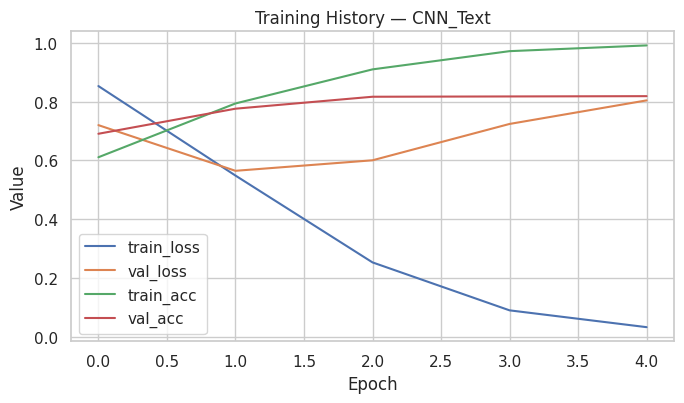

[OK] Simpan history: /content/outputs/hist_CNN_Text.png
[VAL] CNN_Text → Acc=0.7758 | Prec=0.7758 | Rec=0.7758 | F1=0.7758


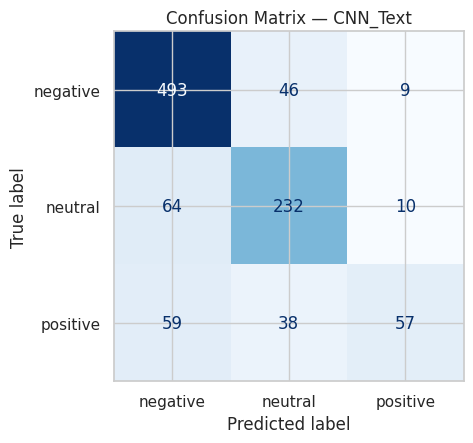

[OK] Simpan CM: /content/outputs/confmat_CNN_Text.png
[OK] Simpan model: /content/outputs/CNN_Text.keras

[RUN] BiLSTM — training…
Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.5609 - loss: 0.9354 - val_accuracy: 0.7103 - val_loss: 0.6966
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.8058 - loss: 0.5173 - val_accuracy: 0.7867 - val_loss: 0.5804
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.9266 - loss: 0.2152 - val_accuracy: 0.8125 - val_loss: 0.6144
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.9689 - loss: 0.0922 - val_accuracy: 0.8204 - val_loss: 0.6890
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9758 - loss: 0.0793 - val_accuracy: 0.8194 - val_loss: 0.9099
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


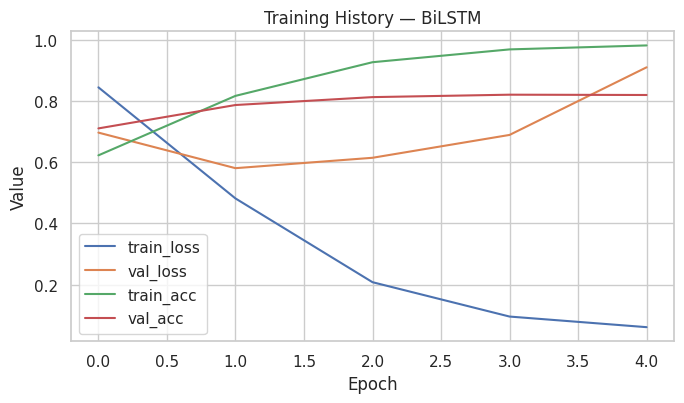

[OK] Simpan history: /content/outputs/hist_BiLSTM.png
[VAL] BiLSTM → Acc=0.7867 | Prec=0.7867 | Rec=0.7867 | F1=0.7867


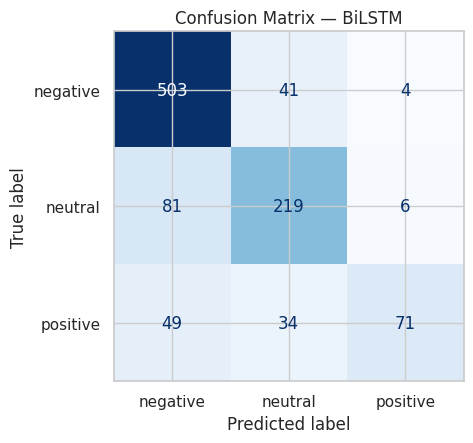

[OK] Simpan CM: /content/outputs/confmat_BiLSTM.png
[OK] Simpan model: /content/outputs/BiLSTM.keras

[RUN] BiLSTM_CNN — training…
Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.5938 - loss: 0.9181 - val_accuracy: 0.7232 - val_loss: 0.7102
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.8056 - loss: 0.5098 - val_accuracy: 0.7857 - val_loss: 0.6094
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9264 - loss: 0.2064 - val_accuracy: 0.8135 - val_loss: 0.6148
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9474 - loss: 0.1548 - val_accuracy: 0.8056 - val_loss: 1.0956
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9843 - loss: 0.0447 - val_accuracy: 0.8135 - val_loss: 1.0301
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


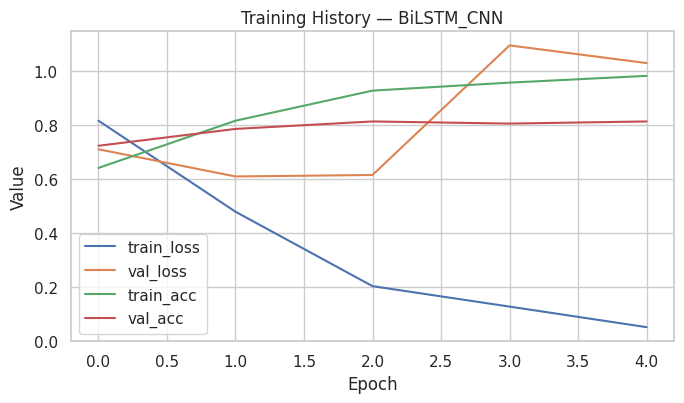

[OK] Simpan history: /content/outputs/hist_BiLSTM_CNN.png
[VAL] BiLSTM_CNN → Acc=0.7857 | Prec=0.7857 | Rec=0.7857 | F1=0.7857


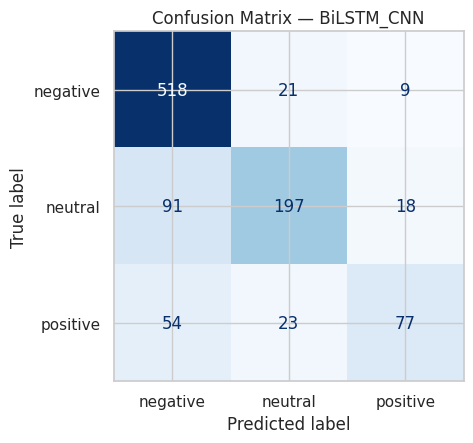

[OK] Simpan CM: /content/outputs/confmat_BiLSTM_CNN.png
[OK] Simpan model: /content/outputs/BiLSTM_CNN.keras

[OK] Simpan metrik DL → /content/outputs/metrics_recommended_dl.csv

[RESULT] Ringkasan metrik Deep Learning (urut F1 menurun):


,model,accuracy,precision,recall,f1
1,BiLSTM,0.7867,0.7867,0.7867,0.7867
2,BiLSTM_CNN,0.7857,0.7857,0.7857,0.7857
0,CNN_Text,0.7758,0.7758,0.7758,0.7758


In [ ]:
# ====================================================
# Cell 9 — Deep Learning Klasik (Keras) pada Dataset Rekomendasi
#   • Train on : dataset rekomendasi (tni1_manual / tni2_auto / tni3_auto)
#   • Eval on  : val tni1 (manual)
#   • Models   : CNN-Text, BiLSTM, BiLSTM+CNN  (ikut flag di Cell 3)
#   • Output   :
#       - outputs/metrics_recommended_dl.csv
#       - outputs/hist_<MODEL>.png  (juga ditampilkan after training)
#       - outputs/confmat_<MODEL>.png  (juga ditampilkan after eval)
#       - outputs/<MODEL>.keras
#       - Tabel ringkasan metrik di akhir cell
# ====================================================

import os, gc, numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display

sns.set(style="whitegrid")

# ------------------- 1) Dataset rekomendasi -------------------
if "df_eval" in globals() and isinstance(df_eval, pd.DataFrame) and not df_eval.empty:
    _best_row = df_eval.sort_values("f1", ascending=False).iloc[0]
    RECOMMENDED_DATASET = _best_row["dataset"]
else:
    RECOMMENDED_DATASET = "tni1_manual"  # fallback

label2id = DATA_SPLIT["label_map"]
id2label = DATA_SPLIT["id2label"]

if RECOMMENDED_DATASET == "tni1_manual":
    TRAIN_TEXTS = DATA_SPLIT["X_train"]
    TRAIN_LABELS = np.asarray(DATA_SPLIT["y_train"], dtype=int)
    RECO_NAME = "tni1_manual"
elif RECOMMENDED_DATASET == "tni2_auto":
    TRAIN_TEXTS = df2_auto["clean_text"].astype(str).values
    TRAIN_LABELS = np.asarray([label2id[s] for s in df2_auto["sentimen_auto"].astype(str).values], dtype=int)
    RECO_NAME = "tni2_auto"
elif RECOMMENDED_DATASET == "tni3_auto":
    TRAIN_TEXTS = df3_auto["clean_text"].astype(str).values
    TRAIN_LABELS = np.asarray([label2id[s] for s in df3_auto["sentimen_auto"].astype(str).values], dtype=int)
    RECO_NAME = "tni3_auto"
else:
    raise ValueError(f"Unknown recommended dataset: {RECOMMENDED_DATASET}")

X_VAL_TEXTS = DATA_SPLIT["X_val"]
Y_VAL = np.asarray(DATA_SPLIT["y_val"], dtype=int)

print(f"[INFO] DL — Train on: {RECO_NAME} (n={len(TRAIN_TEXTS)}) | Eval on: val tni1 (n={len(X_VAL_TEXTS)})")

# ------------------- 2) Tokenizer & sequences -------------------
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(TRAIN_TEXTS)

def to_seq(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_SEQ_LEN, padding="post", truncating="post")

X_TR_SEQ = to_seq(TRAIN_TEXTS)
X_VA_SEQ = to_seq(X_VAL_TEXTS)
num_classes = len(SENTIMENT_ORDER)

# ------------------- 3) tf.data pipeline -------------------
BATCH = BATCH_DL
ds_tr = tf.data.Dataset.from_tensor_slices((X_TR_SEQ, TRAIN_LABELS)).shuffle(len(TRAIN_LABELS), seed=SEED).batch(BATCH).prefetch(tf.data.AUTOTUNE)
ds_va = tf.data.Dataset.from_tensor_slices((X_VA_SEQ, Y_VAL)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

# ------------------- 4) Model builders -------------------
def build_cnn_text():
    inp = layers.Input(shape=(MAX_SEQ_LEN,), dtype="int32")
    x = layers.Embedding(min(len(tokenizer.word_index)+1, MAX_VOCAB), EMB_DIM)(inp)
    x = layers.Conv1D(256, 3, padding="same", activation="relu")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inp, out, name="CNN_Text")
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

def build_bilstm():
    inp = layers.Input(shape=(MAX_SEQ_LEN,), dtype="int32")
    x = layers.Embedding(min(len(tokenizer.word_index)+1, MAX_VOCAB), EMB_DIM)(inp)
    x = layers.Bidirectional(layers.LSTM(128))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inp, out, name="BiLSTM")
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

def build_bilstm_cnn():
    inp = layers.Input(shape=(MAX_SEQ_LEN,), dtype="int32")
    x = layers.Embedding(min(len(tokenizer.word_index)+1, MAX_VOCAB), EMB_DIM)(inp)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Conv1D(256, 3, padding="same", activation="relu")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inp, out, name="BiLSTM_CNN")
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

# ------------------- 5) Callbacks -------------------
cb = [callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE,
                              restore_best_weights=True, verbose=1)]

# ------------------- 6) Train & Eval util (tampilkan & simpan gambar) -------------------
def train_and_eval(build_fn, model_name):
    print(f"\n[RUN] {model_name} — training…")
    model = build_fn()
    hist = model.fit(ds_tr, validation_data=ds_va,
                     epochs=EPOCHS_DL, verbose=1, callbacks=cb)

    # ===== History plot (tampilkan & simpan) =====
    hist_df = pd.DataFrame(hist.history)
    plt.figure(figsize=(7,4.2))
    plt.plot(hist_df["loss"], label="train_loss")
    plt.plot(hist_df["val_loss"], label="val_loss")
    if "accuracy" in hist_df: plt.plot(hist_df["accuracy"], label="train_acc")
    if "val_accuracy" in hist_df: plt.plot(hist_df["val_accuracy"], label="val_acc")
    plt.title(f"Training History — {model_name}")
    plt.xlabel("Epoch"); plt.ylabel("Value"); plt.legend()
    plt.tight_layout()
    hist_path = os.path.join(OUTPUT_DIR, f"hist_{model_name}.png")
    plt.savefig(hist_path, dpi=130)
    plt.show()   # <<< tampilkan langsung
    print(f"[OK] Simpan history: {hist_path}")

    # ===== Evaluasi & Confusion Matrix =====
    y_pred = np.argmax(model.predict(ds_va, verbose=0), axis=1)
    acc = accuracy_score(Y_VAL, y_pred)
    pre = precision_score(Y_VAL, y_pred, average="micro", zero_division=0)
    rec = recall_score(Y_VAL, y_pred, average="micro", zero_division=0)
    f1  = f1_score(Y_VAL, y_pred, average="micro", zero_division=0)
    print(f"[VAL] {model_name} → Acc={acc:.4f} | Prec={pre:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

    cm = confusion_matrix(Y_VAL, y_pred, labels=list(range(num_classes)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SENTIMENT_ORDER)
    fig, ax = plt.subplots(figsize=(5.6,4.6))
    disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    cm_path = os.path.join(OUTPUT_DIR, f"confmat_{model_name}.png")
    plt.savefig(cm_path, dpi=130)
    plt.show()   # <<< tampilkan langsung
    print(f"[OK] Simpan CM: {cm_path}")

    # ===== Simpan model =====
    model_path = os.path.join(OUTPUT_DIR, f"{model_name}.keras")
    model.save(model_path)
    print(f"[OK] Simpan model: {model_path}")

    return {"model": model_name, "accuracy": acc, "precision": pre, "recall": rec, "f1": f1}

# ------------------- 7) Jalankan model sesuai flag -------------------
dl_rows = []
if ENABLE_DL_CLASSIC and ENABLE_CNN_TEXT:
    dl_rows.append(train_and_eval(build_cnn_text, "CNN_Text")); gc.collect()
if ENABLE_DL_CLASSIC and ENABLE_BILSTM:
    dl_rows.append(train_and_eval(build_bilstm, "BiLSTM")); gc.collect()
if ENABLE_DL_CLASSIC and ENABLE_BILSTM_CNN:
    dl_rows.append(train_and_eval(build_bilstm_cnn, "BiLSTM_CNN")); gc.collect()

# ------------------- 8) Simpan & tampilkan tabel hasil -------------------
df_dl = pd.DataFrame(dl_rows).sort_values("f1", ascending=False)
out_csv = os.path.join(OUTPUT_DIR, "metrics_recommended_dl.csv")
df_dl.to_csv(out_csv, index=False)
print(f"\n[OK] Simpan metrik DL → {out_csv}")

print("\n[RESULT] Ringkasan metrik Deep Learning (urut F1 menurun):")
try:
    display(
        df_dl.style.format({
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}"
        })
    )
except Exception:
    print(df_dl.to_string(index=False))

## Cell 3 - Transformer

In [ ]:
# ====================================================
# Cell 10a — Gunakan optimizer dari tf_keras (fallback tf.keras)
# ====================================================
import os, gc, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sns.set(style="whitegrid")

# fallback hyperparams (jaga-jaga)
if "MAX_BERT_LEN" not in globals():  MAX_BERT_LEN = 128
if "BATCH_BERT"  not in globals():   BATCH_BERT  = 16
if "EPOCHS_TRF"  not in globals():   EPOCHS_TRF  = 3
if "LR_TRF"      not in globals():   LR_TRF      = 2e-5
if "EARLY_STOP_PATIENCE" not in globals(): EARLY_STOP_PATIENCE = 2
if "SENTIMENT_ORDER" not in globals(): SENTIMENT_ORDER = ["negative","neutral","positive"]

# --- penting: pakai optimizer dari tf_keras agar cocok dengan model transformers TF ---
try:
    from tf_keras.optimizers import Adam  # prefer tf_keras
except Exception:
    from tensorflow.keras.optimizers import Adam  # fallback

def make_ds(tokenizer, texts, labels=None, max_len=128, batch_size=16, shuffle=False, seed=42):
    enc = tokenizer(list(texts), padding="max_length", truncation=True, max_length=max_len, return_tensors="np")
    inputs = {"input_ids": enc["input_ids"].astype("int32"),
              "attention_mask": enc["attention_mask"].astype("int32")}
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(inputs)
    else:
        ds = tf.data.Dataset.from_tensor_slices((inputs, np.asarray(labels, dtype="int32")))
    if shuffle:
        ds = ds.shuffle(len(texts), seed=seed)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def train_trf_seqcls(
    model_name: str,
    train_texts, train_labels,
    val_texts,   val_labels,
    alias: str = "TRF",
    max_len: int = 128,
    batch_size: int = 16,
    epochs: int = 3,
    lr: float = 2e-5,
    outdir: str = None
):
    """Latih Transformer TF (sequence classification) dengan optimizer tf_keras.Adam (FIX)."""
    if outdir is None:
        outdir = OUTPUT_DIR if "OUTPUT_DIR" in globals() else "./outputs"
    os.makedirs(outdir, exist_ok=True)

    num_labels = len(SENTIMENT_ORDER)
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    except Exception as e:
        print(f"[SKIP] {alias}: gagal memuat TF weights '{model_name}'. Detail: {e}")
        return None

    ds_tr = make_ds(tokenizer, train_texts, train_labels, max_len=max_len, batch_size=batch_size, shuffle=True)
    ds_va = make_ds(tokenizer, val_texts,   val_labels,   max_len=max_len, batch_size=batch_size, shuffle=False)

    # gunakan optimizer dari tf_keras agar kompatibel
    opt = Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE,
                                           restore_best_weights=True, verbose=1)]

    print(f"\n[RUN] {alias} — epochs={epochs}, batch={batch_size}, max_len={max_len}, lr={lr}")
    hist = model.fit(ds_tr, validation_data=ds_va, epochs=epochs, callbacks=cb, verbose=1)

    # ===== History (show+save)
    hist_df = pd.DataFrame(hist.history)
    plt.figure(figsize=(7,4.2))
    plt.plot(hist_df["loss"], label="train_loss")
    plt.plot(hist_df["val_loss"], label="val_loss")
    if "accuracy" in hist_df: plt.plot(hist_df["accuracy"], label="train_acc")
    if "val_accuracy" in hist_df: plt.plot(hist_df["val_accuracy"], label="val_acc")
    plt.title(f"Training History — {alias}")
    plt.xlabel("Epoch"); plt.ylabel("Value"); plt.legend(); plt.tight_layout()
    hp = os.path.join(outdir, f"hist_TRF_{alias}.png")
    plt.savefig(hp, dpi=130); plt.show()
    print(f"[OK] History disimpan: {hp}")

    # ===== Eval (show+save CM)
    probs = model.predict(ds_va, verbose=0).logits
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(val_labels, y_pred)
    pre = precision_score(val_labels, y_pred, average="micro", zero_division=0)
    rec = recall_score(val_labels, y_pred, average="micro", zero_division=0)
    f1  = f1_score(val_labels, y_pred, average="micro", zero_division=0)
    print(f"[VAL] {alias} → Acc={acc:.4f} | Prec={pre:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

    cm = confusion_matrix(val_labels, y_pred, labels=list(range(num_labels)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SENTIMENT_ORDER)
    fig, ax = plt.subplots(figsize=(5.6,4.6))
    disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix — {alias}")
    plt.tight_layout()
    cp = os.path.join(outdir, f"confmat_TRF_{alias}.png")
    plt.savefig(cp, dpi=130); plt.show()
    print(f"[OK] CM disimpan: {cp}")

    mp = os.path.join(outdir, f"TRF_{alias}.keras")
    model.save(mp)
    print(f"[OK] Model disimpan: {mp}")

    gc.collect()
    return {"model": alias, "accuracy": acc, "precision": pre, "recall": rec, "f1": f1}

print("[READY] Patch optimizer tf_keras sudah aktif. Jalankan Cell Patch ✅")

[READY] Patch optimizer tf_keras sudah aktif. Jalankan Cell Patch ✅


In [ ]:
# ====================================================
# Patch: train_trf_seqcls pakai tf_keras.Adam & tf_keras.callbacks.EarlyStopping
# ====================================================
import os, gc, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sns.set(style="whitegrid")

# fallback hyperparams
if "MAX_BERT_LEN" not in globals():  MAX_BERT_LEN = 128
if "BATCH_BERT"  not in globals():   BATCH_BERT  = 16
if "EPOCHS_TRF"  not in globals():   EPOCHS_TRF  = 3
if "LR_TRF"      not in globals():   LR_TRF      = 2e-5
if "EARLY_STOP_PATIENCE" not in globals(): EARLY_STOP_PATIENCE = 2
if "SENTIMENT_ORDER" not in globals(): SENTIMENT_ORDER = ["negative","neutral","positive"]
if "OUTPUT_DIR" not in globals(): OUTPUT_DIR = "./outputs"

# >>> penting: ambil dari tf_keras dulu; fallback ke tensorflow.keras bila perlu
try:
    from tf_keras.optimizers import Adam as TF_KERAS_ADAM
    from tf_keras.callbacks import EarlyStopping as TF_KERAS_EARLYSTOP
except Exception:
    from tensorflow.keras.optimizers import Adam as TF_KERAS_ADAM
    from tensorflow.keras.callbacks import EarlyStopping as TF_KERAS_EARLYSTOP

def _make_ds(tokenizer, texts, labels=None, max_len=128, batch_size=16, shuffle=False, seed=42):
    enc = tokenizer(list(texts), padding="max_length", truncation=True, max_length=max_len, return_tensors="np")
    inputs = {"input_ids": enc["input_ids"].astype("int32"),
              "attention_mask": enc["attention_mask"].astype("int32")}
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(inputs)
    else:
        ds = tf.data.Dataset.from_tensor_slices((inputs, np.asarray(labels, dtype="int32")))
    if shuffle:
        ds = ds.shuffle(len(texts), seed=seed)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def train_trf_seqcls(
    model_name: str,
    train_texts, train_labels,
    val_texts,   val_labels,
    alias: str = "TRF",
    max_len: int = 128,
    batch_size: int = 16,
    epochs: int = 3,
    lr: float = 2e-5,
    outdir: str = None
):
    """Latih Transformer TF (sequence classification) dengan tf_keras optimizer & callbacks yang kompatibel."""
    if outdir is None:
        outdir = OUTPUT_DIR
    os.makedirs(outdir, exist_ok=True)

    num_labels = len(SENTIMENT_ORDER)
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    except Exception as e:
        print(f"[SKIP] {alias}: gagal memuat TF weights '{model_name}'. Detail: {e}")
        return None

    ds_tr = _make_ds(tokenizer, train_texts, train_labels, max_len=max_len, batch_size=batch_size, shuffle=True)
    ds_va = _make_ds(tokenizer, val_texts,   val_labels,   max_len=max_len, batch_size=batch_size, shuffle=False)

    # gunakan tf_keras optimizer & callback
    opt = TF_KERAS_ADAM(learning_rate=lr)
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    cb = [TF_KERAS_EARLYSTOP(monitor="val_loss", patience=EARLY_STOP_PATIENCE,
                             restore_best_weights=True, verbose=1)]

    print(f"\n[RUN] {alias} — epochs={epochs}, batch={batch_size}, max_len={max_len}, lr={lr}")
    hist = model.fit(ds_tr, validation_data=ds_va, epochs=epochs, callbacks=cb, verbose=1)

    # ===== History (show+save)
    hist_df = pd.DataFrame(hist.history)
    plt.figure(figsize=(7,4.2))
    plt.plot(hist_df["loss"], label="train_loss")
    plt.plot(hist_df["val_loss"], label="val_loss")
    if "accuracy" in hist_df: plt.plot(hist_df["accuracy"], label="train_acc")
    if "val_accuracy" in hist_df: plt.plot(hist_df["val_accuracy"], label="val_acc")
    plt.title(f"Training History — {alias}")
    plt.xlabel("Epoch"); plt.ylabel("Value"); plt.legend(); plt.tight_layout()
    hp = os.path.join(outdir, f"hist_TRF_{alias}.png")
    plt.savefig(hp, dpi=130); plt.show()
    print(f"[OK] History disimpan: {hp}")

    # ===== Eval (show+save CM)
    probs = model.predict(ds_va, verbose=0).logits
    y_pred = np.argmax(probs, axis=1)

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
    acc = accuracy_score(val_labels, y_pred)
    pre = precision_score(val_labels, y_pred, average="micro", zero_division=0)
    rec = recall_score(val_labels, y_pred, average="micro", zero_division=0)
    f1  = f1_score(val_labels, y_pred, average="micro", zero_division=0)
    print(f"[VAL] {alias} → Acc={acc:.4f} | Prec={pre:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

    cm = confusion_matrix(val_labels, y_pred, labels=list(range(num_labels)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SENTIMENT_ORDER)
    fig, ax = plt.subplots(figsize=(5.6,4.6))
    disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix — {alias}")
    plt.tight_layout()
    cp = os.path.join(outdir, f"confmat_TRF_{alias}.png")
    plt.savefig(cp, dpi=130); plt.show()
    print(f"[OK] CM disimpan: {cp}")

    mp = os.path.join(outdir, f"TRF_{alias}.keras")
    model.save(mp)
    print(f"[OK] Model disimpan: {mp}")

    gc.collect()
    return {"model": alias, "accuracy": acc, "precision": pre, "recall": rec, "f1": f1}

print("[READY] Patch tf_keras callbacks aktif. Jalankan Cell 10b lagi ✅")

[READY] Patch tf_keras callbacks aktif. Jalankan Cell 10b lagi ✅


[INFO] TRF — Train on: tni1_manual (n=4612) | Eval on: val tni1 (n=1008)


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



[RUN] IndoBERT — epochs=3, batch=16, max_len=128, lr=2e-05
Epoch 1/3
289/289 [==============================] - 208s 459ms/step - loss: 1.3254 - accuracy: 0.1962 - val_loss: 1.0986 - val_accuracy: 0.1528
Epoch 2/3
289/289 [==============================] - 127s 440ms/step - loss: 1.0986 - accuracy: 0.1329 - val_loss: 1.0986 - val_accuracy: 0.1528
Epoch 3/3
289/289 [==============================] - 127s 438ms/step - loss: 1.0986 - accuracy: 0.1329 - val_loss: 1.0986 - val_accuracy: 0.1528
Restoring model weights from the end of the best epoch: 1.


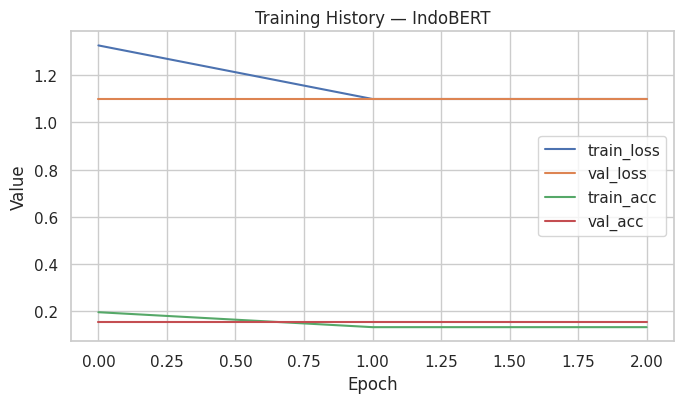

[OK] History disimpan: /content/outputs/hist_TRF_IndoBERT.png
[VAL] IndoBERT → Acc=0.1528 | Prec=0.1528 | Rec=0.1528 | F1=0.1528


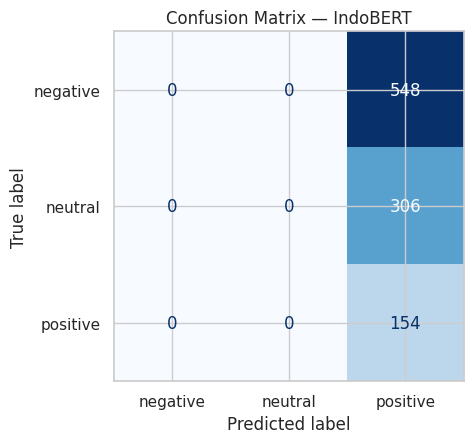

[OK] CM disimpan: /content/outputs/confmat_TRF_IndoBERT.png
[OK] Model disimpan: /content/outputs/TRF_IndoBERT.keras


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/512 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFXLMRobertaForSequenceClassification.

Some layers of TFXLMRobertaForSequenceClassification were not initialized from the model checkpoint at jplu/tf-xlm-roberta-base and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



[RUN] XLMR — epochs=3, batch=16, max_len=128, lr=2e-05
Epoch 1/3
289/289 [==============================] - 187s 495ms/step - loss: 1.2078 - accuracy: 0.2795 - val_loss: 1.0986 - val_accuracy: 0.1528
Epoch 2/3
289/289 [==============================] - 133s 459ms/step - loss: 1.0986 - accuracy: 0.2637 - val_loss: 1.0986 - val_accuracy: 0.1528
Epoch 3/3
289/289 [==============================] - 133s 459ms/step - loss: 1.0986 - accuracy: 0.2476 - val_loss: 1.0986 - val_accuracy: 0.1528
Restoring model weights from the end of the best epoch: 1.


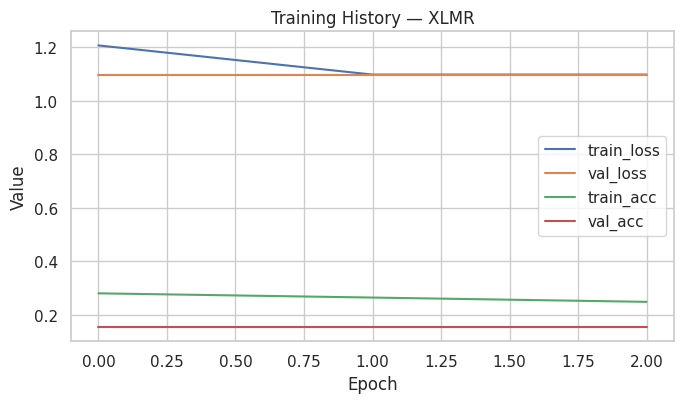

[OK] History disimpan: /content/outputs/hist_TRF_XLMR.png
[VAL] XLMR → Acc=0.1528 | Prec=0.1528 | Rec=0.1528 | F1=0.1528


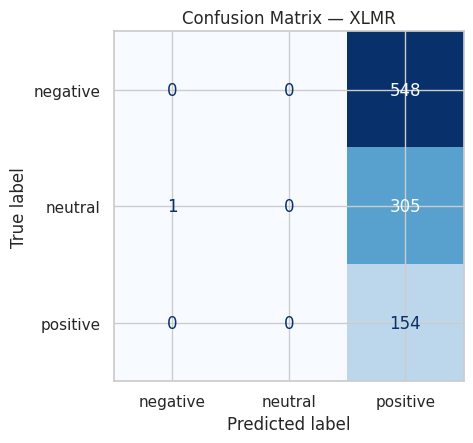

[OK] CM disimpan: /content/outputs/confmat_TRF_XLMR.png
[OK] Model disimpan: /content/outputs/TRF_XLMR.keras
[INFO] BERT+CNN sementara dinonaktifkan di mode TF (rawan error KerasTensor). Jika perlu, kita bisa pakai PyTorch untuk head CNN.

[OK] Simpan metrik Transformer → /content/outputs/metrics_recommended_trf.csv

[RESULT] Ringkasan metrik Transformer (urut F1 menurun):


,model,accuracy,precision,recall,f1
0,IndoBERT,0.1528,0.1528,0.1528,0.1528
1,XLMR,0.1528,0.1528,0.1528,0.1528


In [ ]:
# ====================================================
# Cell 10b (PATCH) — Jalankan Transformer pakai trainer baru
#   • IndoBERT (auto-skip kalau TF weights bermasalah)
#   • mBERT
#   • XLM-R
# ====================================================

import os, numpy as np, pandas as pd
from IPython.display import display

if "OUTPUT_DIR" not in globals(): OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ambil dataset rekomendasi (hasil 7b)
if "df_eval" in globals() and isinstance(df_eval, pd.DataFrame) and not df_eval.empty:
    _best_row = df_eval.sort_values("f1", ascending=False).iloc[0]
    RECOMMENDED_DATASET = _best_row["dataset"]
else:
    RECOMMENDED_DATASET = "tni1_manual"

label2id = DATA_SPLIT["label_map"]

if RECOMMENDED_DATASET == "tni1_manual":
    TRAIN_TEXTS = DATA_SPLIT["X_train"]
    TRAIN_LABELS = np.asarray(DATA_SPLIT["y_train"], dtype=int)
    RECO_NAME = "tni1_manual"
elif RECOMMENDED_DATASET == "tni2_auto":
    TRAIN_TEXTS = df2_auto["clean_text"].astype(str).values
    TRAIN_LABELS = np.asarray([label2id[s] for s in df2_auto["sentimen_auto"].astype(str).values], dtype=int)
    RECO_NAME = "tni2_auto"
elif RECOMMENDED_DATASET == "tni3_auto":
    TRAIN_TEXTS = df3_auto["clean_text"].astype(str).values
    TRAIN_LABELS = np.asarray([label2id[s] for s in df3_auto["sentimen_auto"].astype(str).values], dtype=int)
    RECO_NAME = "tni3_auto"
else:
    raise ValueError(f"Unknown recommended dataset: {RECOMMENDED_DATASET}")

X_VAL_TEXTS = DATA_SPLIT["X_val"]
Y_VAL       = np.asarray(DATA_SPLIT["y_val"], dtype=int)

print(f"[INFO] TRF — Train on: {RECO_NAME} (n={len(TRAIN_TEXTS)}) | Eval on: val tni1 (n={len(X_VAL_TEXTS)})")

# hyperparams (ambil dari globals fallback 10a)
max_len = MAX_BERT_LEN
batch   = BATCH_BERT
epochs  = EPOCHS_TRF
lr      = LR_TRF

trf_rows = []

if ENABLE_TRANSFORMER:

    if ENABLE_INDOBERT:
        res = train_trf_seqcls(
            "indobenchmark/indobert-base-p2",
            TRAIN_TEXTS, TRAIN_LABELS,
            X_VAL_TEXTS, Y_VAL,
            alias="IndoBERT",
            max_len=max_len, batch_size=batch, epochs=epochs, lr=lr,
            outdir=OUTPUT_DIR
        )
        if res: trf_rows.append(res)

    if ENABLE_MBERT_XLMR:
        res = train_trf_seqcls(
            "bert-base-multilingual-cased",
            TRAIN_TEXTS, TRAIN_LABELS,
            X_VAL_TEXTS, Y_VAL,
            alias="mBERT",
            max_len=max_len, batch_size=batch, epochs=epochs, lr=lr,
            outdir=OUTPUT_DIR
        )
        if res: trf_rows.append(res)

        res = train_trf_seqcls(
            "jplu/tf-xlm-roberta-base",
            TRAIN_TEXTS, TRAIN_LABELS,
            X_VAL_TEXTS, Y_VAL,
            alias="XLMR",
            max_len=max_len, batch_size=batch, epochs=epochs, lr=lr,
            outdir=OUTPUT_DIR
        )
        if res: trf_rows.append(res)

    if ENABLE_BERT_CNN:
        print("[INFO] BERT+CNN sementara dinonaktifkan di mode TF (rawan error KerasTensor). "
              "Jika perlu, kita bisa pakai PyTorch untuk head CNN.")

else:
    print("[SKIP] ENABLE_TRANSFORMER=False")

# simpan & tampilkan tabel
df_trf = pd.DataFrame(trf_rows).sort_values("f1", ascending=False) if trf_rows else pd.DataFrame(columns=["model","accuracy","precision","recall","f1"])
out_csv = os.path.join(OUTPUT_DIR, "metrics_recommended_trf.csv")
df_trf.to_csv(out_csv, index=False)
print(f"\n[OK] Simpan metrik Transformer → {out_csv}")

print("\n[RESULT] Ringkasan metrik Transformer (urut F1 menurun):")
try:
    display(df_trf.style.format({"accuracy":"{:.4f}","precision":"{:.4f}","recall":"{:.4f}","f1":"{:.4f}"}))
except Exception:
    print(df_trf.to_string(index=False))

[INFO] TRF — Train on: tni1_manual (n=4612) | Eval on: val tni1 (n=1008)


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



[RUN] IndoBERT — epochs=3, batch=16, max_len=128, lr=2e-05
Epoch 1/3
289/289 [==============================] - 247s 467ms/step - loss: 1.1740 - accuracy: 0.5748 - val_loss: 1.0986 - val_accuracy: 0.5456
Epoch 2/3
289/289 [==============================] - 127s 440ms/step - loss: 1.0984 - accuracy: 0.5709 - val_loss: 1.0986 - val_accuracy: 0.5456
Epoch 3/3
289/289 [==============================] - 127s 438ms/step - loss: 1.0984 - accuracy: 0.5739 - val_loss: 1.0986 - val_accuracy: 0.5456
Restoring model weights from the end of the best epoch: 1.


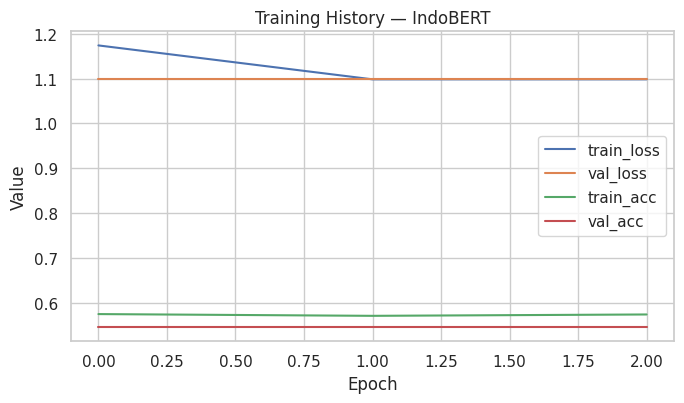

[OK] History disimpan: /content/outputs/hist_TRF_IndoBERT.png
[VAL] IndoBERT → Acc=0.5456 | Prec=0.5456 | Rec=0.5456 | F1=0.5456


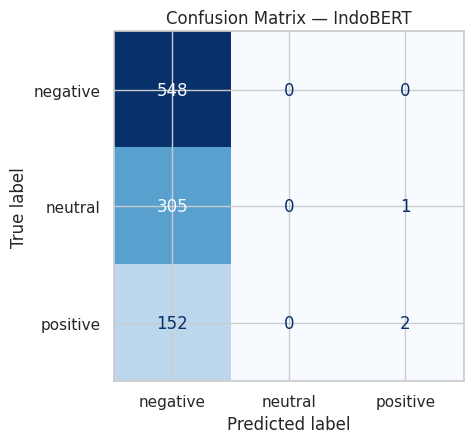

[OK] CM disimpan: /content/outputs/confmat_TRF_IndoBERT.png
[OK] Model disimpan: /content/outputs/TRF_IndoBERT.keras


pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[FALLBACK] Memuat 'bert-base-multilingual-cased' via from_pt=True (konversi dari PyTorch).

[RUN] mBERT — epochs=3, batch=16, max_len=128, lr=2e-05 [from_pt]
Epoch 1/3
289/289 [==============================] - 177s 468ms/step - loss: 1.1469 - accuracy: 0.3422 - val_loss: 1.0986 - val_accuracy: 0.3046
Epoch 2/3
289/289 [==============================] - 129s 448ms/step - loss: 1.0986 - accuracy: 0.3003 - val_loss: 1.0986 - val_accuracy: 0.3046
Epoch 3/3
289/289 [==============================] - 129s 446ms/step - loss: 1.0986 - accuracy: 0.2992 - val_loss: 1.0986 - val_accuracy: 0.3046
Restoring model weights from the end of the best epoch: 1.


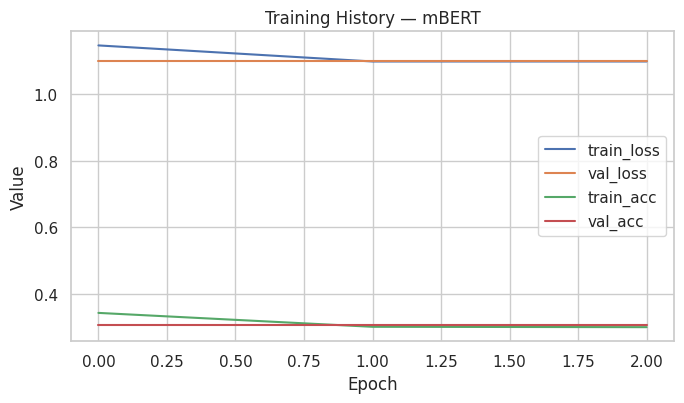

[OK] History disimpan: /content/outputs/hist_TRF_mBERT.png
[VAL] mBERT → Acc=0.3046 | Prec=0.3046 | Rec=0.3046 | F1=0.3046


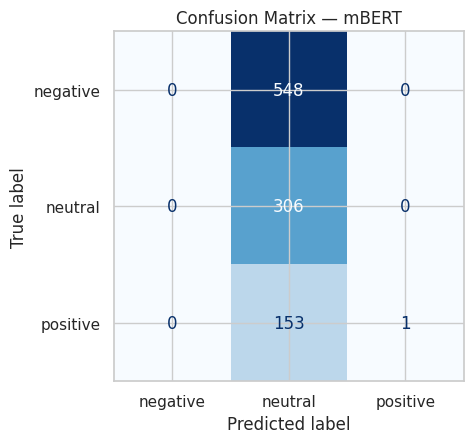

[OK] CM disimpan: /content/outputs/confmat_TRF_mBERT.png
[OK] Model disimpan: /content/outputs/TRF_mBERT.keras


All model checkpoint layers were used when initializing TFXLMRobertaForSequenceClassification.

Some layers of TFXLMRobertaForSequenceClassification were not initialized from the model checkpoint at jplu/tf-xlm-roberta-base and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



[RUN] XLMR — epochs=3, batch=16, max_len=128, lr=2e-05
Epoch 1/3
289/289 [==============================] - 190s 507ms/step - loss: 1.5500 - accuracy: 0.5215 - val_loss: 0.9060 - val_accuracy: 0.5437
Epoch 2/3
289/289 [==============================] - 136s 470ms/step - loss: 1.0079 - accuracy: 0.5624 - val_loss: 0.9546 - val_accuracy: 0.5437
Epoch 3/3
289/289 [==============================] - 136s 470ms/step - loss: 0.9402 - accuracy: 0.5722 - val_loss: 0.9897 - val_accuracy: 0.5962
Restoring model weights from the end of the best epoch: 1.


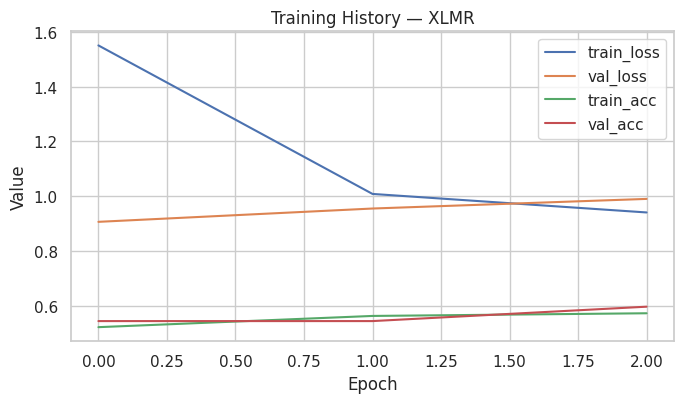

[OK] History disimpan: /content/outputs/hist_TRF_XLMR.png
[VAL] XLMR → Acc=0.5437 | Prec=0.5437 | Rec=0.5437 | F1=0.5437


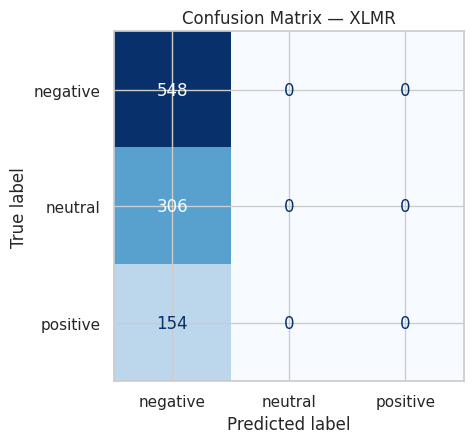

[OK] CM disimpan: /content/outputs/confmat_TRF_XLMR.png
[OK] Model disimpan: /content/outputs/TRF_XLMR.keras
[INFO] BERT+CNN head dimatikan di mode TF untuk kestabilan. Jika dibutuhkan, kita bisa sediakan versi PyTorch khusus.

[OK] Simpan metrik Transformer → /content/outputs/metrics_recommended_trf.csv

[RESULT] Ringkasan metrik Transformer (urut F1 menurun):


,model,accuracy,precision,recall,f1
0,IndoBERT,0.5456,0.5456,0.5456,0.5456
2,XLMR,0.5437,0.5437,0.5437,0.5437
1,mBERT,0.3046,0.3046,0.3046,0.3046


In [ ]:
# ====================================================
# Cell 10c — Transformer (final, robust loader + tf_keras)
#   • Trainer: TFAutoModelForSequenceClassification (compile+fit)
#   • Loader kuat: TF → fallback from_pt=True
#   • Optimizer & Callback: tf_keras (kompatibel)
#   • Output: gambar (history & CM), CSV, tabel metrik
# ====================================================

import os, gc, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display

sns.set(style="whitegrid")

# --------- fallback globals (aman bila belum didefinisikan) ---------
if "OUTPUT_DIR" not in globals(): OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if "SENTIMENT_ORDER" not in globals(): SENTIMENT_ORDER = ["negative","neutral","positive"]
if "MAX_BERT_LEN" not in globals():  MAX_BERT_LEN = 128
if "BATCH_BERT"  not in globals():   BATCH_BERT  = 16
if "EPOCHS_TRF"  not in globals():   EPOCHS_TRF  = 3
if "LR_TRF"      not in globals():   LR_TRF      = 2e-5
if "EARLY_STOP_PATIENCE" not in globals(): EARLY_STOP_PATIENCE = 2
if "SEED" not in globals(): SEED = 42

# --------- gunakan tf_keras agar cocok dengan stack HF-TF ---------
try:
    from tf_keras.optimizers import Adam as TF_KERAS_ADAM
    from tf_keras.callbacks import EarlyStopping as TF_KERAS_EARLYSTOP
except Exception:
    from tensorflow.keras.optimizers import Adam as TF_KERAS_ADAM
    from tensorflow.keras.callbacks import EarlyStopping as TF_KERAS_EARLYSTOP

# --------- dataset rekomendasi (dari hasil 7b) ---------
if "df_eval" in globals() and isinstance(df_eval, pd.DataFrame) and not df_eval.empty:
    _best_row = df_eval.sort_values("f1", ascending=False).iloc[0]
    RECOMMENDED_DATASET = _best_row["dataset"]
else:
    RECOMMENDED_DATASET = "tni1_manual"

label2id = DATA_SPLIT["label_map"]
id2label = DATA_SPLIT["id2label"]

if RECOMMENDED_DATASET == "tni1_manual":
    TRAIN_TEXTS = DATA_SPLIT["X_train"]
    TRAIN_LABELS = np.asarray(DATA_SPLIT["y_train"], dtype=int)
    RECO_NAME = "tni1_manual"
elif RECOMMENDED_DATASET == "tni2_auto":
    TRAIN_TEXTS = df2_auto["clean_text"].astype(str).values
    TRAIN_LABELS = np.asarray([label2id[s] for s in df2_auto["sentimen_auto"].astype(str).values], dtype=int)
    RECO_NAME = "tni2_auto"
elif RECOMMENDED_DATASET == "tni3_auto":
    TRAIN_TEXTS = df3_auto["clean_text"].astype(str).values
    TRAIN_LABELS = np.asarray([label2id[s] for s in df3_auto["sentimen_auto"].astype(str).values], dtype=int)
    RECO_NAME = "tni3_auto"
else:
    raise ValueError(f"Unknown recommended dataset: {RECOMMENDED_DATASET}")

X_VAL_TEXTS = DATA_SPLIT["X_val"]
Y_VAL       = np.asarray(DATA_SPLIT["y_val"], dtype=int)

print(f"[INFO] TRF — Train on: {RECO_NAME} (n={len(TRAIN_TEXTS)}) | Eval on: val tni1 (n={len(X_VAL_TEXTS)})")

# --------- util: dataset encoding ---------
def _make_ds(tokenizer, texts, labels=None, max_len=128, batch_size=16, shuffle=False, seed=42):
    enc = tokenizer(list(texts), padding="max_length", truncation=True, max_length=max_len, return_tensors="np")
    inputs = {
        "input_ids": enc["input_ids"].astype("int32"),
        "attention_mask": enc["attention_mask"].astype("int32")
    }
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(inputs)
    else:
        ds = tf.data.Dataset.from_tensor_slices((inputs, np.asarray(labels, dtype="int32")))
    if shuffle:
        ds = ds.shuffle(len(texts), seed=seed)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# --------- loader kuat: TF → fallback from_pt ---------
def _load_seqcls_model(model_name, num_labels):
    errors = []
    # coba TF weights dulu
    try:
        m = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
        return m, False
    except Exception as e1:
        errors.append(str(e1))
    # fallback: konversi dari PyTorch
    try:
        m = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, from_pt=True)
        print(f"[FALLBACK] Memuat '{model_name}' via from_pt=True (konversi dari PyTorch).")
        return m, True
    except Exception as e2:
        errors.append(str(e2))
        raise RuntimeError(" / ".join(errors))

# --------- trainer utama ---------
def train_trf_seqcls(
    model_name: str,
    train_texts, train_labels,
    val_texts,   val_labels,
    alias: str = "TRF",
    max_len: int = MAX_BERT_LEN,
    batch_size: int = BATCH_BERT,
    epochs: int = EPOCHS_TRF,
    lr: float = LR_TRF,
    outdir: str = OUTPUT_DIR
):
    os.makedirs(outdir, exist_ok=True)
    num_labels = len(SENTIMENT_ORDER)

    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model, used_from_pt = _load_seqcls_model(model_name, num_labels=num_labels)
    except Exception as e:
        print(f"[SKIP] {alias}: gagal memuat '{model_name}'. Detail: {e}")
        return None

    ds_tr = _make_ds(tokenizer, train_texts, train_labels, max_len=max_len, batch_size=batch_size, shuffle=True, seed=SEED)
    ds_va = _make_ds(tokenizer, val_texts,   val_labels,   max_len=max_len, batch_size=batch_size, shuffle=False, seed=SEED)

    opt = TF_KERAS_ADAM(learning_rate=lr)
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    cb = [TF_KERAS_EARLYSTOP(monitor="val_loss", patience=EARLY_STOP_PATIENCE,
                             restore_best_weights=True, verbose=1)]

    print(f"\n[RUN] {alias} — epochs={epochs}, batch={batch_size}, max_len={max_len}, lr={lr}"
          + (" [from_pt]" if used_from_pt else ""))

    hist = model.fit(ds_tr, validation_data=ds_va, epochs=epochs, callbacks=cb, verbose=1)

    # ===== history (show + save)
    hist_df = pd.DataFrame(hist.history)
    plt.figure(figsize=(7,4.2))
    plt.plot(hist_df["loss"], label="train_loss")
    plt.plot(hist_df["val_loss"], label="val_loss")
    if "accuracy" in hist_df: plt.plot(hist_df["accuracy"], label="train_acc")
    if "val_accuracy" in hist_df: plt.plot(hist_df["val_accuracy"], label="val_acc")
    plt.title(f"Training History — {alias}")
    plt.xlabel("Epoch"); plt.ylabel("Value"); plt.legend(); plt.tight_layout()
    hp = os.path.join(outdir, f"hist_TRF_{alias}.png")
    plt.savefig(hp, dpi=130); plt.show()
    print(f"[OK] History disimpan: {hp}")

    # ===== eval (show + save CM)
    probs = model.predict(ds_va, verbose=0).logits
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(val_labels, y_pred)
    pre = precision_score(val_labels, y_pred, average="micro", zero_division=0)
    rec = recall_score(val_labels, y_pred, average="micro", zero_division=0)
    f1  = f1_score(val_labels, y_pred, average="micro", zero_division=0)
    print(f"[VAL] {alias} → Acc={acc:.4f} | Prec={pre:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

    cm = confusion_matrix(val_labels, y_pred, labels=list(range(num_labels)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SENTIMENT_ORDER)
    fig, ax = plt.subplots(figsize=(5.6,4.6))
    disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix — {alias}")
    plt.tight_layout()
    cp = os.path.join(outdir, f"confmat_TRF_{alias}.png")
    plt.savefig(cp, dpi=130); plt.show()
    print(f"[OK] CM disimpan: {cp}")

    # simpan model
    mp = os.path.join(outdir, f"TRF_{alias}.keras")
    model.save(mp)
    print(f"[OK] Model disimpan: {mp}")

    gc.collect()
    return {"model": alias, "accuracy": acc, "precision": pre, "recall": rec, "f1": f1}

# --------- jalankan model sesuai flag ---------
trf_rows = []

if 'ENABLE_TRANSFORMER' in globals() and ENABLE_TRANSFORMER:

    if 'ENABLE_INDOBERT' in globals() and ENABLE_INDOBERT:
        res = train_trf_seqcls("indobenchmark/indobert-base-p2",
                               TRAIN_TEXTS, TRAIN_LABELS,
                               X_VAL_TEXTS, Y_VAL,
                               alias="IndoBERT")
        if res: trf_rows.append(res)

    if 'ENABLE_MBERT_XLMR' in globals() and ENABLE_MBERT_XLMR:
        # mBERT — fallback from_pt jika TF weights masalah
        res = train_trf_seqcls("bert-base-multilingual-cased",
                               TRAIN_TEXTS, TRAIN_LABELS,
                               X_VAL_TEXTS, Y_VAL,
                               alias="mBERT")
        if res: trf_rows.append(res)

        # XLM-R — punya TF weights, tapi patch fallback tetap aktif
        res = train_trf_seqcls("jplu/tf-xlm-roberta-base",
                               TRAIN_TEXTS, TRAIN_LABELS,
                               X_VAL_TEXTS, Y_VAL,
                               alias="XLMR")
        if res: trf_rows.append(res)

    if 'ENABLE_BERT_CNN' in globals() and ENABLE_BERT_CNN:
        print("[INFO] BERT+CNN head dimatikan di mode TF untuk kestabilan. "
              "Jika dibutuhkan, kita bisa sediakan versi PyTorch khusus.")

else:
    print("[SKIP] ENABLE_TRANSFORMER=False — tidak menjalankan model Transformer.")

# --------- simpan & tampilkan tabel hasil ---------
df_trf = pd.DataFrame(trf_rows).sort_values("f1", ascending=False) if trf_rows else pd.DataFrame(columns=["model","accuracy","precision","recall","f1"])
out_csv = os.path.join(OUTPUT_DIR, "metrics_recommended_trf.csv")
df_trf.to_csv(out_csv, index=False)
print(f"\n[OK] Simpan metrik Transformer → {out_csv}")

print("\n[RESULT] Ringkasan metrik Transformer (urut F1 menurun):")
try:
    display(df_trf.style.format({"accuracy":"{:.4f}","precision":"{:.4f}","recall":"{:.4f}","f1":"{:.4f}"}))
except Exception:
    print(df_trf.to_string(index=False))

#Evaluation Model

## Cell 1 - Rekap & Pemilihan Model Terbaik (TRAD vs DL vs TRF)

[OK] Simpan gabungan metrik → /content/outputs/metrics_all_models.csv

[RESULT] Komparasi semua model (urut F1 menurun):


,family,model,accuracy,precision,recall,f1
0,Traditional,RF,0.8016,0.8016,0.8016,0.8016
1,DeepLearning,BiLSTM,0.7867,0.7867,0.7867,0.7867
2,DeepLearning,BiLSTM_CNN,0.7857,0.7857,0.7857,0.7857
3,DeepLearning,CNN_Text,0.7758,0.7758,0.7758,0.7758
4,Traditional,SVM,0.7728,0.7728,0.7728,0.7728
5,Traditional,LR,0.7421,0.7421,0.7421,0.7421
6,Traditional,NB,0.7222,0.7222,0.7222,0.7222
7,Transformer,IndoBERT,0.5456,0.5456,0.5456,0.5456
8,Transformer,XLMR,0.5437,0.5437,0.5437,0.5437
9,Transformer,mBERT,0.3046,0.3046,0.3046,0.3046



[TOP-1 per Keluarga]


,family,model,accuracy,precision,recall,f1
0,Traditional,RF,0.8016,0.8016,0.8016,0.8016
1,DeepLearning,BiLSTM,0.7867,0.7867,0.7867,0.7867
7,Transformer,IndoBERT,0.5456,0.5456,0.5456,0.5456



[OVERALL BEST]
Dataset   : tni1_manual
Keluarga  : Traditional
Model     : RF
F1        : 0.8016 | Acc=0.8016 | Prec=0.8016 | Rec=0.8016
[OK] Simpan ringkasan best model → /content/outputs/best_model_summary.json


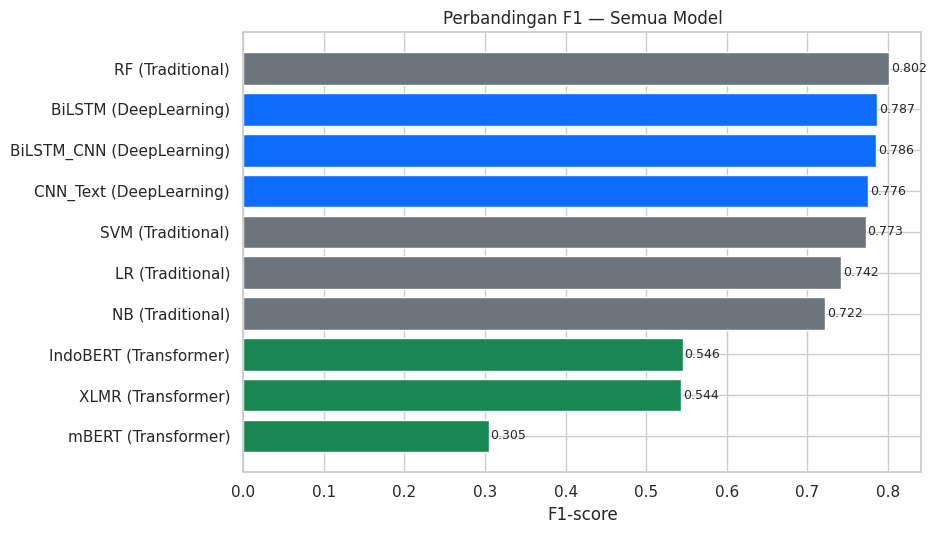

[OK] Simpan grafik F1 → /content/outputs/f1_comparison_all_models.png


In [ ]:
# ====================================================
# Cell 11 — Rekap & Pemilihan Model Terbaik (TRAD vs DL vs TRF)
#   • Baca metrik dari CSV hasil Cell 7b, 9, 10c
#   • Gabungkan → tabel komparasi
#   • Tampilkan Top-1 per keluarga & Top-1 overall (berdasarkan F1)
#   • Bar chart F1 semua model
#   • Simpan ringkasan ke outputs/
# ====================================================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set(style="whitegrid")
os.makedirs(OUTPUT_DIR, exist_ok=True)

path_trad = os.path.join(OUTPUT_DIR, "metrics_recommended_trad.csv")
path_dl   = os.path.join(OUTPUT_DIR, "metrics_recommended_dl.csv")
path_trf  = os.path.join(OUTPUT_DIR, "metrics_recommended_trf.csv")

def _safe_read(path, family_name):
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["family"] = family_name
        # normalisasi kolom yang mungkin hilang
        for col in ["model","accuracy","precision","recall","f1"]:
            if col not in df.columns:
                df[col] = np.nan
        # tipe numerik aman
        for col in ["accuracy","precision","recall","f1"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        # nama model str
        df["model"] = df["model"].astype(str)
        return df[["family","model","accuracy","precision","recall","f1"]]
    else:
        print(f"[INFO] File tidak ditemukan, lewati: {path}")
        return pd.DataFrame(columns=["family","model","accuracy","precision","recall","f1"])

df_trad = _safe_read(path_trad, "Traditional")
df_dl   = _safe_read(path_dl,   "DeepLearning")
df_trf  = _safe_read(path_trf,  "Transformer")

df_all = pd.concat([df_trad, df_dl, df_trf], ignore_index=True)
if df_all.empty:
    raise RuntimeError("Tidak ada metrik yang ditemukan. Pastikan Cell 7b (Trad), 9 (DL), dan 10c (Transformer) sudah dijalankan.")

# sort by F1 desc
df_all = df_all.sort_values("f1", ascending=False).reset_index(drop=True)

# Simpan gabungan
all_csv_path = os.path.join(OUTPUT_DIR, "metrics_all_models.csv")
df_all.to_csv(all_csv_path, index=False)
print(f"[OK] Simpan gabungan metrik → {all_csv_path}")

# ===== Tampilkan tabel ringkasan (semua model, urut F1) =====
print("\n[RESULT] Komparasi semua model (urut F1 menurun):")
try:
    display(
        df_all.style.format({
            "accuracy":"{:.4f}",
            "precision":"{:.4f}",
            "recall":"{:.4f}",
            "f1":"{:.4f}"
        })
    )
except Exception:
    print(df_all.to_string(index=False))

# ===== Top-1 per keluarga =====
tops = []
for fam in ["Traditional","DeepLearning","Transformer"]:
    sub = df_all[df_all["family"] == fam]
    if not sub.empty:
        tops.append(sub.iloc[0])

df_top_family = pd.DataFrame(tops) if tops else pd.DataFrame(columns=df_all.columns)

print("\n[TOP-1 per Keluarga]")
if not df_top_family.empty:
    try:
        display(
            df_top_family[["family","model","accuracy","precision","recall","f1"]]
            .style.format({"accuracy":"{:.4f}","precision":"{:.4f}","recall":"{:.4f}","f1":"{:.4f}"})
        )
    except Exception:
        print(df_top_family.to_string(index=False))
else:
    print("Belum ada top-1 per keluarga (mungkin ada keluarga yang belum dijalankan).")

# ===== Top-1 overall =====
best_row = df_all.iloc[0]
best_summary = {
    "recommended_dataset": RECOMMENDED_DATASET if "RECOMMENDED_DATASET" in globals() else "unknown",
    "best_family": best_row["family"],
    "best_model": best_row["model"],
    "metrics": {
        "accuracy": float(best_row["accuracy"]),
        "precision": float(best_row["precision"]),
        "recall": float(best_row["recall"]),
        "f1": float(best_row["f1"]),
    }
}

print("\n[OVERALL BEST]")
print(f"Dataset   : {best_summary['recommended_dataset']}")
print(f"Keluarga  : {best_summary['best_family']}")
print(f"Model     : {best_summary['best_model']}")
print(f"F1        : {best_summary['metrics']['f1']:.4f} | Acc={best_summary['metrics']['accuracy']:.4f} | "
      f"Prec={best_summary['metrics']['precision']:.4f} | Rec={best_summary['metrics']['recall']:.4f}")

# simpan JSON ringkasan
best_json_path = os.path.join(OUTPUT_DIR, "best_model_summary.json")
with open(best_json_path, "w") as f:
    json.dump(best_summary, f, indent=2)
print(f"[OK] Simpan ringkasan best model → {best_json_path}")

# ===== Bar chart F1 semua model =====
plt.figure(figsize=(9.5, 5.5))
order = df_all.index  # sudah di-sort
palette = {"Traditional":"#6c757d", "DeepLearning":"#0d6efd", "Transformer":"#198754"}
bar_colors = df_all["family"].map(palette).fillna("#999999")

plt.barh(range(len(df_all)), df_all["f1"], tick_label=[f"{m} ({fam})" for m, fam in zip(df_all["model"], df_all["family"])], color=bar_colors)
plt.gca().invert_yaxis()
plt.xlabel("F1-score")
plt.title("Perbandingan F1 — Semua Model")
for i, v in enumerate(df_all["f1"]):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
f1_png = os.path.join(OUTPUT_DIR, "f1_comparison_all_models.png")
plt.savefig(f1_png, dpi=140)
plt.show()
print(f"[OK] Simpan grafik F1 → {f1_png}")

#Visualisasi dan Topic Modelling

## Cell 1 - Distribusi Sentimen

[INFO] Dataset untuk grafik: tni1_manual | n=5040 | label='sentimen' | time='created_at'


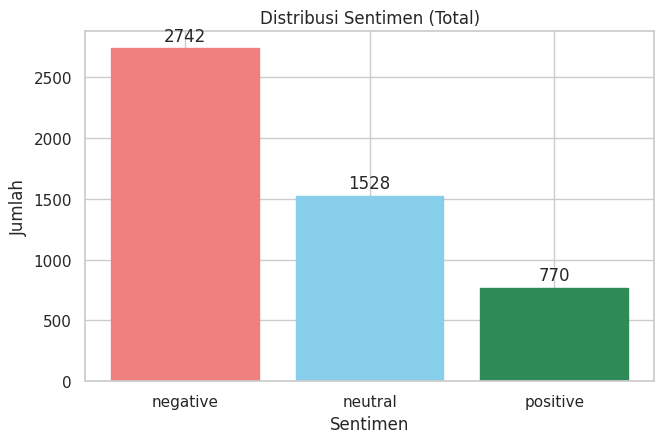

[OK] Simpan bar chart → /content/outputs/dist_total_tni1_manual.png


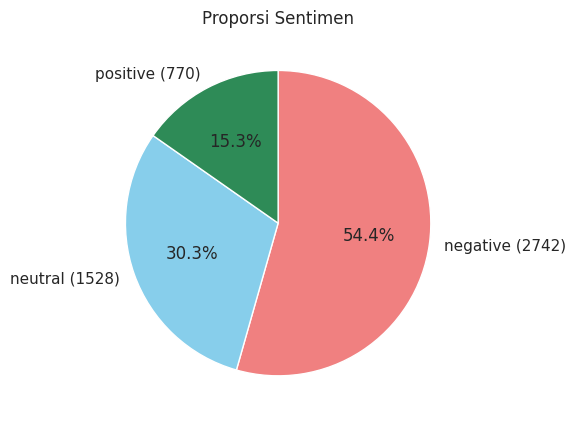

[OK] Simpan pie chart → /content/outputs/dist_pie_tni1_manual.png


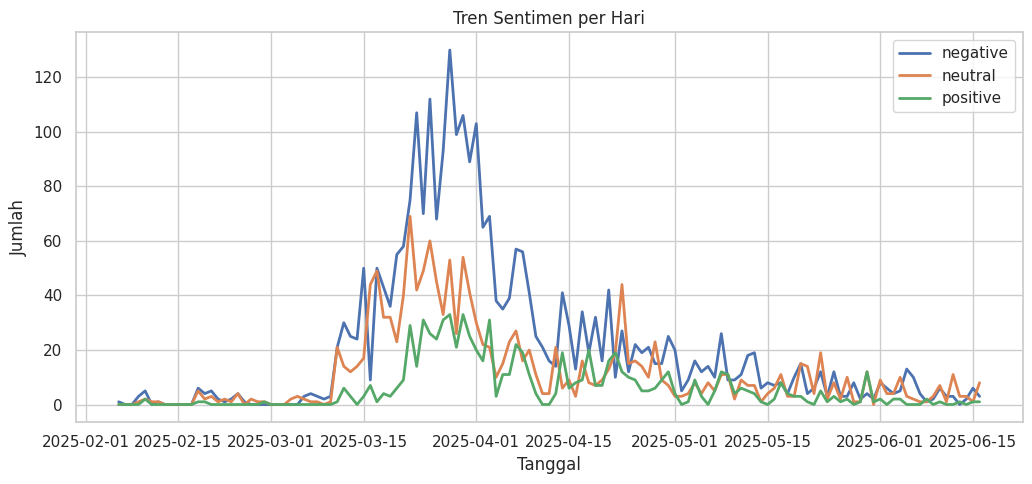

[OK] Simpan line chart harian → /content/outputs/trend_daily_line_tni1_manual.png


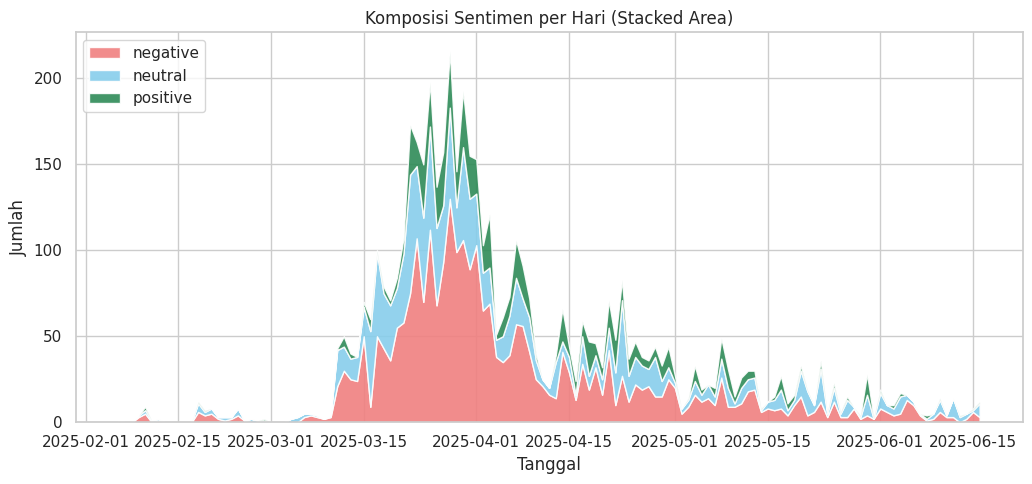

[OK] Simpan stacked area harian → /content/outputs/trend_daily_area_tni1_manual.png

[DONE] Distribusi sentimen lengkap sudah dibuat & disimpan.


In [ ]:
# ====================================================
# Cell 12 — Distribusi Sentimen
#   • Pakai dataset rekomendasi hasil 7b
#   • Plot:
#       (1) Bar chart distribusi total
#       (2) Pie chart proporsi
#       (3) Kurva per-hari per-sentimen (line)
#       (4) (opsional) Stacked area per-hari
#   • Simpan ke OUTPUT_DIR dan tampilkan
# ====================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- 1) Ambil dataset rekomendasi ----------
if "RECOMMENDED_DATASET" not in globals():
    # fallback dari df_eval bila ada
    if "df_eval" in globals() and isinstance(df_eval, pd.DataFrame) and not df_eval.empty:
        _best_row = df_eval.sort_values("f1", ascending=False).iloc[0]
        RECOMMENDED_DATASET = _best_row["dataset"]
    else:
        RECOMMENDED_DATASET = "tni1_manual"

if "SENTIMENT_ORDER" not in globals():
    SENTIMENT_ORDER = ["negative","neutral","positive"]

# mapping ambil dataframe dan kolom waktu sesuai track
def _get_df_and_timecol(name):
    if name == "tni1_manual":
        # tni1 (manual label)
        df = df1.copy()
        # kolom label final untuk plot: gunakan yang sudah distandardisasi di Cell 6/7
        if "sentimen" in df.columns:
            label_col = "sentimen"
        elif "label" in df.columns:
            label_col = "label"
        else:
            # fallback jika sudah ada mapping ke id dan id->label
            label_col = None
        time_col = TIME_COL_1 if "TIME_COL_1" in globals() else "created_at"
    elif name == "tni2_auto":
        # hasil auto-label tni2
        df = df2_auto.copy()
        label_col = "sentimen_auto"
        time_col = TIME_COL_2 if "TIME_COL_2" in globals() else "created_at"
    elif name == "tni3_auto":
        # hasil auto-label tni3
        df = df3_auto.copy()
        label_col = "sentimen_auto"
        time_col = TIME_COL_3 if "TIME_COL_3" in globals() else "created_at"
    else:
        raise ValueError(f"Unknown dataset name: {name}")
    return df, label_col, time_col

df_use, label_col, time_col = _get_df_and_timecol(RECOMMENDED_DATASET)

if label_col is None or label_col not in df_use.columns:
    # jika label text tidak ada, coba konversi dari id
    if "__label_id" in df_use.columns and "id2label" in globals():
        df_use["__label_txt"] = df_use["__label_id"].map(id2label)
        label_col = "__label_txt"
    else:
        raise RuntimeError("Kolom label teks tidak ditemukan. Pastikan preprocessing (Cell 6–7) sudah benar.")

# ---------- 2) Rapikan tipe waktu ----------
def _coerce_to_naive_datetime(s):
    # konversi ke datetime (aware → naive UTC atau local)
    ss = pd.to_datetime(s, errors="coerce", utc=True)
    # jadikan naive (tanpa tz) agar Matplotlib happy
    return ss.dt.tz_convert(None) if hasattr(ss.dt, "tz_convert") else ss

if time_col in df_use.columns:
    df_use[time_col] = _coerce_to_naive_datetime(df_use[time_col])
else:
    # jika kolom waktu tidak ada, tetap lanjut untuk chart non-time
    print(f"[WARN] Kolom waktu '{time_col}' tidak ditemukan. Grafik per-hari akan dilewati.")
    df_use[time_col] = pd.NaT

# filter hanya label yang kita kenal (SENTIMENT_ORDER)
df_use = df_use[df_use[label_col].isin(SENTIMENT_ORDER)].copy()

print(f"[INFO] Dataset untuk grafik: {RECOMMENDED_DATASET} | n={len(df_use)} | label='{label_col}' | time='{time_col}'")

# ---------- 3) Distribusi total (bar) ----------
cnt = df_use[label_col].value_counts().reindex(SENTIMENT_ORDER).fillna(0).astype(int)
fig = plt.figure(figsize=(6.8, 4.6))
bars = plt.bar(cnt.index, cnt.values)
# warna: negative=salmon, neutral=skyblue, positive=seagreen (biar konsisten dengan contoh sebelumnya)
color_map = {"negative":"#f08080", "neutral":"#87ceeb", "positive":"#2e8b57"}
for bar, lab in zip(bars, cnt.index):
    bar.set_color(color_map.get(lab, "#6c757d"))
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01*max(cnt.values), str(int(bar.get_height())),
             ha="center", va="bottom")
plt.title("Distribusi Sentimen (Total)")
plt.ylabel("Jumlah")
plt.xlabel("Sentimen")
plt.tight_layout()
bar_path = os.path.join(OUTPUT_DIR, f"dist_total_{RECOMMENDED_DATASET}.png")
plt.savefig(bar_path, dpi=140)
plt.show()
print(f"[OK] Simpan bar chart → {bar_path}")

# ---------- 4) Pie chart proporsi ----------
fig = plt.figure(figsize=(5.8, 5.8))
vals = cnt.values
labels = cnt.index
colors = [color_map.get(l, "#6c757d") for l in labels]
plt.pie(vals, labels=[f"{l} ({v})" for l, v in zip(labels, vals)], autopct="%1.1f%%",
        startangle=90, counterclock=False, colors=colors)
plt.title("Proporsi Sentimen")
plt.tight_layout()
pie_path = os.path.join(OUTPUT_DIR, f"dist_pie_{RECOMMENDED_DATASET}.png")
plt.savefig(pie_path, dpi=140)
plt.show()
print(f"[OK] Simpan pie chart → {pie_path}")

# ---------- 5) Kurva per-hari per-sentimen ----------
if df_use[time_col].notna().any():
    df_daily = (
        df_use
        .assign(_date = df_use[time_col].dt.normalize())  # ambil tanggal saja (per-hari)
        .groupby(["_date", label_col]).size()
        .unstack(label_col)
        .reindex(columns=SENTIMENT_ORDER)  # urut kolom
        .fillna(0)
        .astype(int)
        .sort_index()
    )
    # jika ada hari kosong di rentang, isi 0 (asfreq harian)
    if not df_daily.empty:
        full_index = pd.date_range(df_daily.index.min(), df_daily.index.max(), freq="D")
        df_daily = df_daily.reindex(full_index).fillna(0).astype(int)
        df_daily.index.name = "_date"

    # (a) Line chart per-sentimen
    plt.figure(figsize=(10.5, 5.0))
    for sent in SENTIMENT_ORDER:
        if sent in df_daily.columns:
            plt.plot(df_daily.index, df_daily[sent], label=sent, linewidth=2)
    plt.title("Tren Sentimen per Hari")
    plt.xlabel("Tanggal"); plt.ylabel("Jumlah")
    plt.legend()
    plt.tight_layout()
    line_path = os.path.join(OUTPUT_DIR, f"trend_daily_line_{RECOMMENDED_DATASET}.png")
    plt.savefig(line_path, dpi=140)
    plt.show()
    print(f"[OK] Simpan line chart harian → {line_path}")

    # (b) Stacked area (opsional, komposisi per hari)
    plt.figure(figsize=(10.5, 5.0))
    cols_avail = [c for c in SENTIMENT_ORDER if c in df_daily.columns]
    if cols_avail:
        plt.stackplot(df_daily.index, *[df_daily[c].values for c in cols_avail],
                      labels=cols_avail, alpha=0.9)
        # warna sesuai mapping
        for c, poly in zip(cols_avail, plt.gca().collections):
            poly.set_facecolor(color_map.get(c, "#6c757d"))
        plt.title("Komposisi Sentimen per Hari (Stacked Area)")
        plt.xlabel("Tanggal"); plt.ylabel("Jumlah")
        plt.legend(loc="upper left")
        plt.tight_layout()
        area_path = os.path.join(OUTPUT_DIR, f"trend_daily_area_{RECOMMENDED_DATASET}.png")
        plt.savefig(area_path, dpi=140)
        plt.show()
        print(f"[OK] Simpan stacked area harian → {area_path}")
    else:
        print("[INFO] Tidak ada kolom sentimen untuk stacked area.")

else:
    print("[INFO] Grafik harian dilewati karena kolom waktu kosong / tidak valid.")

print("\n[DONE] Distribusi sentimen lengkap sudah dibuat & disimpan.")

## Cell 2 - WordCloud per Sentimen

[INFO] WordCloud source: tni1_gold | n=4612 | text='clean_text' | label='sentimen_norm'


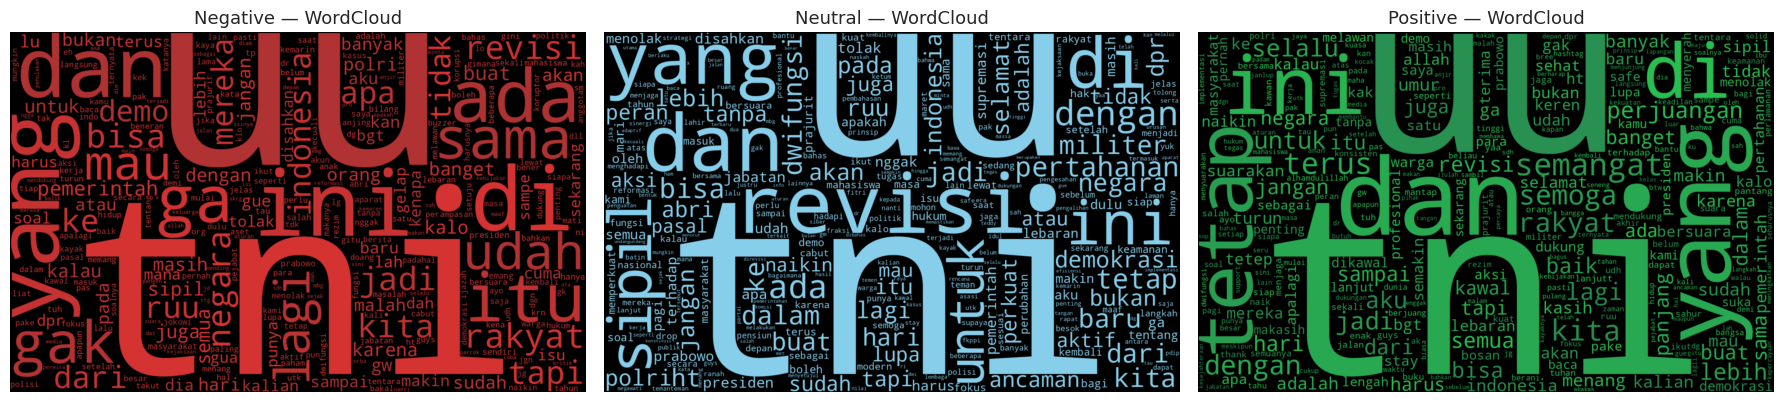

[OK] WordCloud disimpan:
  - /content/outputs/wordcloud_tni1_gold_negative.png
  - /content/outputs/wordcloud_tni1_gold_neutral.png
  - /content/outputs/wordcloud_tni1_gold_positive.png
  - /content/outputs/wordcloud_panel_tni1_gold.png


In [ ]:
# ====================================================
# Cell 13 — WordCloud per Sentimen (sejajar, bg putih)
#   • Dataset  : gold standard (df_agreed)
#   • Teks     : CLEAN_COL_NAME (fallback: 'clean_text' → 'full_text' → 'text')
#   • Label    : 'sentimen_norm'
#   • Tampilan : 3 kolom (negative, neutral, positive)
#   • Warna    : negative=merah, neutral=biru langit (#87ceeb), positive=hijau
#   • BG       : putih
#   • Output   : outputs/wordcloud_gold_{neg|neu|pos}.png, dan satu panel outputs/wordcloud_panel_gold.png
# ====================================================

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# ---------- 1) Dataset: df_agreed ----------
RECOMMENDED_DATASET = "tni1_gold"
df_wc = df_agreed.copy()
LABEL_COL = "sentimen_norm"
TEXT_COL = CLEAN_COL_NAME if "CLEAN_COL_NAME" in globals() and CLEAN_COL_NAME in df_wc.columns else "clean_text"
if TEXT_COL not in df_wc.columns:
    raise RuntimeError("Kolom teks bersih tidak ditemukan. Pastikan 'clean_text' tersedia atau set CLEAN_COL_NAME.")

if "SENTIMENT_ORDER" not in globals():
    SENTIMENT_ORDER = ["negative","neutral","positive"]

df_wc = df_wc[df_wc[LABEL_COL].isin(SENTIMENT_ORDER)].copy()
print(f"[INFO] WordCloud source: {RECOMMENDED_DATASET} | n={len(df_wc)} | text='{TEXT_COL}' | label='{LABEL_COL}'")

# ---------- 2) Stopwords & normalizer ----------
custom_stop = set(STOPWORDS) | {
    "https", "http", "rt", "amp", "co", "t", "…", "aja", "nih", "sih", "ya", "kok",
    "yg", "ygnya", "ygny", "nya", "nih", "loh", "dong", "deh", "si", "biar", "bikin"
}
_url_re   = re.compile(r"http\S+|www\.\S+")
_ment_re  = re.compile(r"@\w+")
_hash_re  = re.compile(r"#\w+")
_multi_sp = re.compile(r"\s+")

def clean_for_wc(s: str) -> str:
    if not isinstance(s, str):
        s = str(s)
    s = _url_re.sub(" ", s)
    s = _ment_re.sub(" ", s)
    s = _hash_re.sub(" ", s)
    s = _multi_sp.sub(" ", s)
    return s.strip()

# ---------- 3) Warna per sentimen ----------
def color_func_factory(sentiment):
    if sentiment == "neutral":
        def _cf(word, font_size, position, orientation, font_path, random_state):
            return "#87ceeb"
        return _cf
    elif sentiment == "negative":
        import random
        def _cf(word, font_size, position, orientation, font_path, random_state):
            r = random.randint(170, 220)
            return f"rgb({r}, 50, 50)"
        return _cf
    else:  # positive
        import random
        def _cf(word, font_size, position, orientation, font_path, random_state):
            g = random.randint(140, 200)
            return f"rgb(40, {g}, 80)"
        return _cf

# ---------- 4) Generate wordcloud ----------
def build_wc(text, sentiment, width=1200, height=800):
    wc = WordCloud(
        width=width, height=height,
        background_color="black",
        stopwords=custom_stop,
        collocations=False,
        max_words=300,
        prefer_horizontal=0.95,
        random_state=SEED if "SEED" in globals() else 42,
    ).generate(text)
    return wc.recolor(color_func=color_func_factory(sentiment))

def concat_text_of(sent):
    sub = df_wc[df_wc[LABEL_COL] == sent][TEXT_COL].dropna().astype(str).map(clean_for_wc)
    return " ".join(sub.tolist())

texts_by_sent = {s: concat_text_of(s) for s in SENTIMENT_ORDER}

# ---------- 5) Render & simpan ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = {"negative":"Negative", "neutral":"Neutral", "positive":"Positive"}

panel_paths = []
for ax, sent in zip(axes, SENTIMENT_ORDER):
    if texts_by_sent.get(sent, "").strip():
        wc_img = build_wc(texts_by_sent[sent], sentiment=sent, width=1600, height=1000)
        ax.imshow(wc_img, interpolation="bilinear")
        ax.set_title(f"{titles.get(sent, sent).title()} — WordCloud", fontsize=13)
        ax.axis("off")
        out_path = os.path.join(OUTPUT_DIR, f"wordcloud_{RECOMMENDED_DATASET}_{sent}.png")
        wc_img.to_file(out_path)
        panel_paths.append(out_path)
    else:
        ax.text(0.5, 0.5, f"Tidak ada teks untuk '{sent}'", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
panel_path = os.path.join(OUTPUT_DIR, f"wordcloud_panel_{RECOMMENDED_DATASET}.png")
plt.savefig(panel_path, dpi=140)
plt.show()

print("[OK] WordCloud disimpan:")
for p in panel_paths:
    print("  -", p)
print("  -", panel_path)

## Cell 3 - Topic Modeling LDA

In [ ]:
# ====================================================
# Cell 14 — Topic Modeling LDA (scikit-learn)
#   • Sumber  : df_agreed (gold standard)
#   • Teks    : CLEAN_COL_NAME (fallback: 'clean_text'/'full_text'/'text')
#   • Langkah : CountVectorizer → LatentDirichletAllocation
#   • Output  : outputs/lda_skl_topics_main.csv
#               outputs/lda_skl_model_main.joblib (opsional)
# ====================================================

import os, re, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --------- 1) Ambil dataset & kolom teks ---------
RECOMMENDED_DATASET = "tni1_gold"
df_main = df_agreed.copy()

# pilih kolom teks bersih
candidates = []
if "CLEAN_COL_NAME" in globals(): candidates.append(CLEAN_COL_NAME)
candidates += ["clean_text", "full_text", "text"]
TEXT_COL = next((c for c in candidates if c in df_main.columns), None)
if TEXT_COL is None:
    raise RuntimeError("Kolom teks bersih tidak ditemukan. Pastikan preprocessing menghasilkan 'clean_text'.")

texts = df_main[TEXT_COL].fillna("").astype(str).tolist()
print(f"[INFO] LDA (sklearn) — source={RECOMMENDED_DATASET} | n={len(texts)} | text='{TEXT_COL}'")

# --------- 2) Vectorizer (BoW) ---------
_url_re   = re.compile(r"http\S+|www\.\S+")
_ment_re  = re.compile(r"@\w+")
_hash_re  = re.compile(r"#\w+")
_multi_sp = re.compile(r"\s+")

def normalize(s: str) -> str:
    s = _url_re.sub(" ", s)
    s = _ment_re.sub(" ", s)
    s = _hash_re.sub(" ", s)
    s = s.lower()
    s = _multi_sp.sub(" ", s).strip()
    return s

texts_norm = [normalize(t) for t in texts]

STOP_ADD = {
    "https","http","rt","amp","co","t","aja","nih","sih","ya","yg","nya","dong","deh","si","dan","atau"
}

vectorizer = CountVectorizer(
    min_df=10, max_df=0.5,
    ngram_range=(1,2),
    stop_words=list(STOP_ADD),
)
X = vectorizer.fit_transform(texts_norm)
vocab = np.array(vectorizer.get_feature_names_out())
print(f"[INFO] Vocab size: {len(vocab)} | Matrix shape: {X.shape}")

# --------- 3) Latent Dirichlet Allocation ---------
LDA_NUM_TOPICS = 6
LDA_MAX_ITER   = 20
LDA_RANDOM     = SEED if "SEED" in globals() else 42

lda = LatentDirichletAllocation(
    n_components=LDA_NUM_TOPICS,
    learning_method="batch",
    max_iter=LDA_MAX_ITER,
    random_state=LDA_RANDOM,
    evaluate_every=5,
    n_jobs=-1
)
lda.fit(X)

joblib.dump({"lda": lda, "vectorizer": vectorizer}, os.path.join(OUTPUT_DIR, "lda_skl_model_main.joblib"))

# --------- 4) Top-kata per topik ---------
TOPN = 12
rows = []
for k, comp in enumerate(lda.components_):
    top_idx = np.argsort(comp)[::-1][:TOPN]
    rows.append({
        "topic_id": k,
        "keywords": ", ".join(vocab[top_idx])
    })
df_topics = pd.DataFrame(rows)
csv_path = os.path.join(OUTPUT_DIR, "lda_skl_topics_main.csv")
df_topics.to_csv(csv_path, index=False)
print(f"[OK] Topik (sklearn) → {csv_path}")

display(df_topics)

[INFO] LDA (sklearn) — source=tni1_gold | n=4612 | text='clean_text'
[INFO] Vocab size: 1403 | Matrix shape: (4612, 1403)
[OK] Topik (sklearn) → /content/outputs/lda_skl_topics_main.csv


,topic_id,keywords
0,0,"ini, gak, di, sama, ga, yang, mau, lagi, udah,..."
1,1,"yang, ini, di, rakyat, ada, itu, tidak, mereka..."
2,2,"revisi, revisi uu, yang, sipil, dwifungsi, dal..."
3,3,"udah, ga, sampai, ada, isu, ini, apa, itu, di,..."
4,4,"ruu, polri, jangan, indonesia, hari, tetap, te..."
5,5,"di, sipil, baru, yang, militer, bisa, jabatan,..."


## Cell 4 - pyLDAvis

In [ ]:
# ====================================================
# Cell 15a — pyLDAvis untuk Sentimen Positive
#   • Output: outputs/pyldavis_positive.html
# ====================================================

import os, re, numpy as np, pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------- Dataset: df_agreed (gold standard) --------
RECOMMENDED_DATASET = "tni1_gold"
df_src = df_agreed.copy()
LABEL_COL = "sentimen_norm"
TEXT_COL = CLEAN_COL_NAME if "CLEAN_COL_NAME" in globals() and CLEAN_COL_NAME in df_src.columns else "clean_text"
if TEXT_COL not in df_src.columns:
    raise RuntimeError("Kolom teks bersih tidak ditemukan. Pastikan preprocessing menghasilkan 'clean_text'.")

df_pos = df_src[df_src[LABEL_COL].astype(str) == "positive"].copy()
print(f"[INFO] pyLDAvis positive — n={len(df_pos)}")

MIN_DOCS = 50
if len(df_pos) < MIN_DOCS:
    raise RuntimeError(f"Dokumen 'positive' terlalu sedikit (<{MIN_DOCS}). Tambah data atau turunkan MIN_DOCS.")

# -------- Normalisasi ringan --------
_url_re   = re.compile(r"http\S+|www\.\S+")
_ment_re  = re.compile(r"@\w+")
_hash_re  = re.compile(r"#\w+")
_multi_sp = re.compile(r"\s+")
def normalize(s: str) -> str:
    s = _url_re.sub(" ", str(s))
    s = _ment_re.sub(" ", s)
    s = _hash_re.sub(" ", s)
    s = s.lower()
    return _multi_sp.sub(" ", s).strip()

texts = df_pos[TEXT_COL].fillna("").astype(str).map(normalize).tolist()

STOP_ADD = {"https","http","rt","amp","co","t","aja","nih","sih","ya","yg","nya","dong","deh","si","dan","atau"}

# -------- Vectorizer & matrix --------
vectorizer = CountVectorizer(
    min_df=5, max_df=0.6,
    ngram_range=(1,2),
    stop_words=list(STOP_ADD)
)
X = vectorizer.fit_transform(texts)
vocab = np.array(vectorizer.get_feature_names_out())
term_frequency = np.asarray(X.sum(axis=0)).ravel()
doc_lengths = np.asarray(X.sum(axis=1)).ravel()

# Buang dokumen kosong
nonzero_mask = doc_lengths > 0
if not np.all(nonzero_mask):
    X = X[nonzero_mask]
    doc_lengths = doc_lengths[nonzero_mask]

# -------- Train LDA --------
NUM_TOPICS = 4
lda = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    learning_method="batch",
    max_iter=20,
    random_state=SEED if "SEED" in globals() else 42,
    n_jobs=-1
).fit(X)

# -------- Build input pyLDAvis --------
topic_term = lda.components_.copy()
topic_term = topic_term / topic_term.sum(axis=1, keepdims=True)

doc_topic = lda.transform(X)
row_sums = doc_topic.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
doc_topic = doc_topic / row_sums

# -------- Simpan visualisasi --------
vis = pyLDAvis.prepare(
    topic_term_dists=topic_term,
    doc_topic_dists=doc_topic,
    doc_lengths=doc_lengths.tolist(),
    vocab=vocab.tolist(),
    term_frequency=term_frequency.tolist(),
    sort_topics=False
)
html_path = os.path.join(OUTPUT_DIR, "pyldavis_positive.html")
pyLDAvis.save_html(vis, html_path)
print(f"[OK] pyLDAvis positive (manual prepare) → {html_path}")

[INFO] pyLDAvis positive — n=613
[OK] pyLDAvis positive (manual prepare) → /content/outputs/pyldavis_positive.html


In [ ]:
# ====================================================
# Cell 15b — pyLDAvis untuk Sentimen Neutral
#   • Output: outputs/pyldavis_neutral.html
# ====================================================

import os, re, numpy as np, pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------- Dataset: df_agreed (gold standard) --------
RECOMMENDED_DATASET = "tni1_gold"
df_src = df_agreed.copy()
LABEL_COL = "sentimen_norm"
TEXT_COL = CLEAN_COL_NAME if "CLEAN_COL_NAME" in globals() and CLEAN_COL_NAME in df_src.columns else "clean_text"
if TEXT_COL not in df_src.columns:
    raise RuntimeError("Kolom teks bersih tidak ditemukan. Pastikan preprocessing menghasilkan 'clean_text'.")

df_neu = df_src[df_src[LABEL_COL].astype(str) == "neutral"].copy()
print(f"[INFO] pyLDAvis neutral — n={len(df_neu)}")

MIN_DOCS = 50
if len(df_neu) < MIN_DOCS:
    raise RuntimeError(f"Dokumen 'neutral' terlalu sedikit (<{MIN_DOCS}). Tambah data atau turunkan MIN_DOCS.")

# -------- Normalisasi ringan --------
_url_re   = re.compile(r"http\S+|www\.\S+")
_ment_re  = re.compile(r"@\w+")
_hash_re  = re.compile(r"#\w+")
_multi_sp = re.compile(r"\s+")
def normalize(s: str) -> str:
    s = _url_re.sub(" ", str(s))
    s = _ment_re.sub(" ", s)
    s = _hash_re.sub(" ", s)
    s = s.lower()
    return _multi_sp.sub(" ", s).strip()

texts = df_neu[TEXT_COL].fillna("").astype(str).map(normalize).tolist()

STOP_ADD = {"https","http","rt","amp","co","t","aja","nih","sih","ya","yg","nya","dong","deh","si","dan","atau"}

# -------- Vectorizer & matrix --------
vectorizer = CountVectorizer(
    min_df=5, max_df=0.6,
    ngram_range=(1,2),
    stop_words=list(STOP_ADD)
)
X = vectorizer.fit_transform(texts)
vocab = np.array(vectorizer.get_feature_names_out())
term_frequency = np.asarray(X.sum(axis=0)).ravel()
doc_lengths = np.asarray(X.sum(axis=1)).ravel()

# Buang dokumen kosong
nonzero_mask = doc_lengths > 0
if not np.all(nonzero_mask):
    X = X[nonzero_mask]
    doc_lengths = doc_lengths[nonzero_mask]

# -------- Train LDA --------
NUM_TOPICS = 4
lda = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    learning_method="batch",
    max_iter=20,
    random_state=SEED if "SEED" in globals() else 42,
    n_jobs=-1
).fit(X)

# -------- Build input pyLDAvis --------
topic_term = lda.components_.copy()
topic_term = topic_term / topic_term.sum(axis=1, keepdims=True)

doc_topic = lda.transform(X)
row_sums = doc_topic.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
doc_topic = doc_topic / row_sums

vis = pyLDAvis.prepare(
    topic_term_dists=topic_term,
    doc_topic_dists=doc_topic,
    doc_lengths=doc_lengths.tolist(),
    vocab=vocab.tolist(),
    term_frequency=term_frequency.tolist(),
    sort_topics=False
)
html_path = os.path.join(OUTPUT_DIR, "pyldavis_neutral.html")
pyLDAvis.save_html(vis, html_path)
print(f"[OK] pyLDAvis neutral (manual prepare) → {html_path}")

[INFO] pyLDAvis neutral — n=1370
[OK] pyLDAvis neutral (manual prepare) → /content/outputs/pyldavis_neutral.html


In [ ]:
# ====================================================
# Cell 15c — pyLDAvis untuk Sentimen Negative
#   • Output: outputs/pyldavis_negative.html
# ====================================================

import os, re, numpy as np, pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------- Dataset: df_agreed (gold standard) --------
RECOMMENDED_DATASET = "tni1_gold"
df_src = df_agreed.copy()
LABEL_COL = "sentimen_norm"
TEXT_COL = CLEAN_COL_NAME if "CLEAN_COL_NAME" in globals() and CLEAN_COL_NAME in df_src.columns else "clean_text"
if TEXT_COL not in df_src.columns:
    raise RuntimeError("Kolom teks bersih tidak ditemukan. Pastikan preprocessing menghasilkan 'clean_text'.")

df_neg = df_src[df_src[LABEL_COL].astype(str) == "negative"].copy()
print(f"[INFO] pyLDAvis negative — n={len(df_neg)}")

MIN_DOCS = 50
if len(df_neg) < MIN_DOCS:
    raise RuntimeError(f"Dokumen 'negative' terlalu sedikit (<{MIN_DOCS}). Tambah data atau turunkan MIN_DOCS.")

# -------- Normalisasi ringan --------
_url_re   = re.compile(r"http\S+|www\.\S+")
_ment_re  = re.compile(r"@\w+")
_hash_re  = re.compile(r"#\w+")
_multi_sp = re.compile(r"\s+")
def normalize(s: str) -> str:
    s = _url_re.sub(" ", str(s))
    s = _ment_re.sub(" ", s)
    s = _hash_re.sub(" ", s)
    s = s.lower()
    return _multi_sp.sub(" ", s).strip()

texts = df_neg[TEXT_COL].fillna("").astype(str).map(normalize).tolist()

STOP_ADD = {"https","http","rt","amp","co","t","aja","nih","sih","ya","yg","nya","dong","deh","si","dan","atau"}

# -------- Vectorizer & matrix --------
vectorizer = CountVectorizer(
    min_df=5, max_df=0.6,
    ngram_range=(1,2),
    stop_words=list(STOP_ADD)
)
X = vectorizer.fit_transform(texts)
vocab = np.array(vectorizer.get_feature_names_out())
term_frequency = np.asarray(X.sum(axis=0)).ravel()
doc_lengths = np.asarray(X.sum(axis=1)).ravel()

# Buang dokumen kosong
nonzero_mask = doc_lengths > 0
if not np.all(nonzero_mask):
    X = X[nonzero_mask]
    doc_lengths = doc_lengths[nonzero_mask]

# -------- Train LDA --------
NUM_TOPICS = 4
lda = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    learning_method="batch",
    max_iter=20,
    random_state=SEED if "SEED" in globals() else 42,
    n_jobs=-1
).fit(X)

# -------- Build input pyLDAvis --------
topic_term = lda.components_.copy()
topic_term = topic_term / topic_term.sum(axis=1, keepdims=True)

doc_topic = lda.transform(X)
row_sums = doc_topic.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
doc_topic = doc_topic / row_sums

vis = pyLDAvis.prepare(
    topic_term_dists=topic_term,
    doc_topic_dists=doc_topic,
    doc_lengths=doc_lengths.tolist(),
    vocab=vocab.tolist(),
    term_frequency=term_frequency.tolist(),
    sort_topics=False
)
html_path = os.path.join(OUTPUT_DIR, "pyldavis_negative.html")
pyLDAvis.save_html(vis, html_path)
print(f"[OK] pyLDAvis negative (manual prepare) → {html_path}")

[INFO] pyLDAvis negative — n=2629
[OK] pyLDAvis negative (manual prepare) → /content/outputs/pyldavis_negative.html


# Export All Results

In [ ]:
# ====================================================
# Cell 16 — Export isi OUTPUT_DIR ke Google Drive
#   • Buat folder: /content/drive/MyDrive/Results-dd-mm-yyyy
#   • Copy seluruh isi OUTPUT_DIR (file & subfolder)
# ====================================================

import os, shutil, glob
from datetime import datetime

# 1) Tentukan sumber OUTPUT_DIR
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = "./outputs"
if not os.path.exists(OUTPUT_DIR):
    raise FileNotFoundError(f"OUTPUT_DIR tidak ditemukan: {OUTPUT_DIR}")

# 2) Mount Google Drive (jika belum)
try:
    from google.colab import drive  # type: ignore
    if not os.path.ismount("/content/drive"):
        print("[INFO] Mounting Google Drive…")
        drive.mount("/content/drive", force_remount=False)
except Exception as e:
    raise RuntimeError("Gagal mengakses Google Drive dari Colab. Pastikan menjalankan di Google Colab.") from e

# 3) Buat folder tujuan di MyDrive dengan format nama aman (dd-mm-yyyy)
today_str = datetime.now().strftime("%d-%m-%Y")  # gunakan '-' karena '/' tidak valid di nama folder
dest_root = "/content/drive/MyDrive"
dest_dir  = os.path.join(dest_root, f"Results-{today_str}")
os.makedirs(dest_dir, exist_ok=True)
print(f"[INFO] Folder tujuan: {dest_dir}")

# 4) Salin seluruh isi OUTPUT_DIR
def copy_tree(src, dst):
    # salin semua file di root OUTPUT_DIR
    for path in glob.glob(os.path.join(src, "*")):
        name = os.path.basename(path)
        dst_path = os.path.join(dst, name)
        if os.path.isdir(path):
            # salin folder secara rekursif
            if os.path.exists(dst_path):
                # gabungkan isi jika folder tujuan sudah ada
                for root, dirs, files in os.walk(path):
                    rel = os.path.relpath(root, path)
                    target_root = os.path.join(dst_path, rel)
                    os.makedirs(target_root, exist_ok=True)
                    for f in files:
                        src_f = os.path.join(root, f)
                        dst_f = os.path.join(target_root, f)
                        shutil.copy2(src_f, dst_f)
            else:
                shutil.copytree(path, dst_path)
        else:
            shutil.copy2(path, dst_path)

print(f"[INFO] Menyalin isi dari: {OUTPUT_DIR}")
copy_tree(OUTPUT_DIR, dest_dir)

# 5) Ringkasan
total_files = 0
for _, _, files in os.walk(dest_dir):
    total_files += len(files)

print("\n[OK] Export selesai ✅")
print(f" - Sumber : {os.path.abspath(OUTPUT_DIR)}")
print(f" - Tujuan : {dest_dir}")
print(f" - Berkas : {total_files} file")

[INFO] Folder tujuan: /content/drive/MyDrive/Results-21-10-2025
[INFO] Menyalin isi dari: /content/outputs

[OK] Export selesai ✅
 - Sumber : /content/outputs
 - Tujuan : /content/drive/MyDrive/Results-21-10-2025
 - Berkas : 44 file


## **Previous Script**

### Old

In [ ]:
# @title
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python thinc albucore albumentations spacy dopamine-rl tensorflow numba tsfresh

In [ ]:
# @title
!pip install -U --force-reinstall "numpy==2.2.1" "pandas==2.2.2" "scipy==1.14.1"

In [ ]:
# @title
!pip install -q scikit-learn nltk Sastrawi gensim pyLDAvis wordcloud matplotlib transformers datasets accelerate torch torchvision torchaudio

### New

In [ ]:
# =====================================================
# Cell 1 - Setup environment & perbaiki dependency
# =====================================================
!pip install -q --upgrade pip setuptools wheel tqdm

from tqdm.notebook import tqdm
import os, sys, subprocess

# Uninstall library yang sering bikin konflik
pkgs_uninstall = [
    "opencv-python", "opencv-python-headless", "opencv-contrib-python",
    "thinc", "albucore", "albumentations", "spacy",
    "dopamine-rl", "tensorflow", "tsfresh",
    "numpy", "pandas", "scipy"
]

print("== Uninstall paket lama ==")
for p in tqdm(pkgs_uninstall):
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", p],
                   stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Install versi stabil & kompatibel (ikuti default Colab)
pkgs_install = [
    "numpy==2.2.1",
    "pandas==2.2.2",   # lock ke versi default Colab
    "scipy==1.14.1",
    "numba==0.59.1"    # numba wajib, dipakai oleh banyak lib
]

print("\n== Install ulang paket inti ==")
for p in tqdm(pkgs_install):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", p],
                   stdout=subprocess.PIPE, stderr=subprocess.PIPE)

print("\n[INFO] Selesai install ulang. "
      "Jika masih ada error import numpy/pandas, Jika Aman tidak ada error restart runtime manual.")


In [ ]:
# =====================================================
# Cell 2 - Install library NLP & ML
# =====================================================
!pip install -q --upgrade pip setuptools wheel tqdm

from tqdm.auto import tqdm
import importlib, subprocess, sys, os

def is_installed(pkg_name: str) -> bool:
    try:
        importlib.import_module(pkg_name)
        return True
    except Exception:
        return False

def pip_install(spec: str):
    """Install satu paket via pip dengan output yang ringkas."""
    return subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", spec],
        stdout=subprocess.PIPE, stderr=subprocess.PIPE
    )

# 1) Paket NLP/ML
pkgs_general = [
    "scikit-learn",
    "nltk",
    "Sastrawi",
    "gensim",
    "pyLDAvis",
    "wordcloud",
    "matplotlib"
]

print("== Install paket NLP/ML ==")
for p in tqdm(pkgs_general):
    if not is_installed(p.split("==")[0].split(">=")[0]):
        pip_install(p)

# 2) Paket Hugging Face
pkgs_hf = [
    "transformers>=4.44.0",
    "datasets",
    "accelerate>=0.33.0",
    "sentencepiece",     # untuk beberapa tokenizer
    "protobuf<5"         # aman buat ekosistem HF/Colab
]

print("\n== Install paket Hugging Face ==")
for p in tqdm(pkgs_hf):
    if not is_installed(p.split("==")[0].split(">=")[0]):
        pip_install(p)

# 3) Torch: hanya install jika belum ada
print("\n== Cek & Install PyTorch (jika belum ada) ==")
torch_installed = is_installed("torch")
if not torch_installed:
    has_nvidia = os.path.exists("/proc/driver/nvidia/version")
    if has_nvidia:
        print("GPU terdeteksi → coba install torch CUDA 12.1 ...")
        r = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q",
             "torch", "torchvision", "torchaudio",
             "--index-url", "https://download.pytorch.org/whl/cu121"],
            stdout=subprocess.PIPE, stderr=subprocess.PIPE
        )
        if r.returncode != 0:
            print("Gagal pasang CUDA wheel, fallback ke CPU.")
            pip_install("torch torchvision torchaudio")
    else:
        print("GPU tidak terdeteksi → install torch CPU.")
        pip_install("torch torchvision torchaudio")
else:
    print("PyTorch sudah terpasang, lewati tahap ini.")

# 4) Verifikasi ringkas
print("\n== Verifikasi versi utama ==")
import numpy as _np, pandas as _pd
print("numpy  :", _np.__version__)
print("pandas :", _pd.__version__)
try:
    import torch as _torch
    print("torch  :", _torch.__version__, "| CUDA:", _torch.cuda.is_available())
except Exception as e:
    print("torch  : belum tersedia atau gagal import →", e)

print("\n[OK] Cell 2 selesai. Lanjut ke Cell 3 untuk cek versi & CUDA secara detail.")


In [ ]:
# =====================================================
# Cell 3 - Cek versi & status CUDA/GPU
# =====================================================
import sys, platform, os
import importlib

def safe_ver(mod_name):
    try:
        m = importlib.import_module(mod_name)
        return getattr(m, "__version__", "unknown")
    except Exception as e:
        return f"not found ({e.__class__.__name__})"

print("== System Info ==")
print("Python  :", sys.version.split()[0])
print("Platform:", platform.platform())

print("\n== Core Libs ==")
print("numpy   :", safe_ver("numpy"))
print("pandas  :", safe_ver("pandas"))
print("scipy   :", safe_ver("scipy"))

# Torch & CUDA
print("\n== PyTorch & CUDA ==")
try:
    import torch
    print("torch   :", torch.__version__)
    gpu_available = torch.cuda.is_available()
    print("CUDA    :", gpu_available)
    if gpu_available:
        print("CUDA ver:", torch.version.cuda)
        print("cuDNN   :", torch.backends.cudnn.version())
        print("GPU cnt :", torch.cuda.device_count())
        for i in range(torch.cuda.device_count()):
            print(f"  - GPU[{i}] :", torch.cuda.get_device_name(i))
        device = "cuda"
    else:
        device = "cpu"
except Exception as e:
    print("torch   : not available →", e)
    device = "cpu"

# Transformers/Datasets/Accelerate (opsional)
print("\n== HuggingFace (opsional) ==")
print("transformers:", safe_ver("transformers"))
print("datasets    :", safe_ver("datasets"))
print("accelerate  :", safe_ver("accelerate"))
print("sentencepiece:", safe_ver("sentencepiece"))

# Ringkasan
print(f"\n[OK] Device yang akan dipakai: {device}")
if device == "cpu":
    print("Tips: aktifkan GPU di Colab (Runtime → Change runtime type → Hardware accelerator: GPU)")


In [ ]:
# =====================================================
# Cell 4 - Mount Google Drive
# =====================================================
from google.colab import drive
import os

# Cek apakah drive sudah ter-mount
if not os.path.exists("/content/drive/MyDrive/Data_Twitter"):
    drive.mount('/content/drive/MyDrive/Data_Twitter')
    print("[OK] Google Drive berhasil di-mount.")
else:
    print("[INFO] Google Drive sudah ter-mount.")


In [ ]:
# =====================================================
# Cell 5 - Definisikan DATA_PATHS (fleksibel & tervalidasi)
# =====================================================
import os, glob
from pathlib import Path

# ====== Opsi A: MANUAL (edit sesuai lokasi file di Drive ) ======
# Contoh sesuai yang di pakai sebelumnya:
DATA_PATHS = [
    "/content/drive/MyDrive/Data_Twitter/tni1.xlsx",
    "/content/drive/MyDrive/Data_Twitter/tni2.xlsx",
]

# ====== Opsi B: OTOMATIS (scan folder) ======
# Jika mau auto-scan, set AUTO_SCAN=True dan atur BASE_DIR
AUTO_SCAN = False
BASE_DIR = "/content/drive/MyDrive/Data_Twitter"   # ganti ke folder dataset
PATTERNS = ["*.csv", "*.xlsx", "*.xls"]            # pola file yang dicari
MAX_FILES = 50                                     # batas atas jumlah file

if AUTO_SCAN:
    found = []
    for pat in PATTERNS:
        found.extend(glob.glob(os.path.join(BASE_DIR, pat)))
    found = sorted(found)[:MAX_FILES]
    if found:
        DATA_PATHS = found

# ====== Validasi & Ringkasan ======
def _fmt_size(bytes_):
    try:
        for unit in ['B','KB','MB','GB','TB']:
            if bytes_ < 1024:
                return f"{bytes_:.1f} {unit}"
            bytes_ /= 1024
        return f"{bytes_:.1f} PB"
    except Exception:
        return "-"

print("== DATA_PATHS ==")
if not DATA_PATHS:
    print("[WARN] DATA_PATHS kosong. Set manual atau aktifkan AUTO_SCAN.")
else:
    ok, miss = 0, 0
    for p in DATA_PATHS:
        if os.path.exists(p):
            ok += 1
            try:
                size = _fmt_size(os.path.getsize(p))
            except Exception:
                size = "-"
            print(f"[OK ] {p}  | {size}")
        else:
            miss += 1
            print(f"[MISS] {p}")
    print(f"\nRingkasan: {ok} file ditemukan, {miss} tidak ditemukan.")

# Simpan path sebagai Path object
DATA_PATHS = [str(Path(p)) for p in DATA_PATHS]

# Jika ingin memastikan minimal 1 file valid sebelum lanjut, aktifkan assert di bawah:
# assert any(os.path.exists(p) for p in DATA_PATHS), "Tidak ada file valid di DATA_PATHS."


In [ ]:
# =====================================================
# Cell 6 - Konfigurasi umum & helper
# =====================================================
import os, random, re
from typing import List, Optional
import numpy as np
import pandas as pd

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Torch (opsional; aman kalau belum terpasang)
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        device = "cuda"
    else:
        device = "cpu"
except Exception:
    torch = None
    device = "cpu"

# Toggle model
ENABLE_TRAIN_RF        = True     # baseline cepat
ENABLE_TRAIN_BERT      = True     # aktif
ENABLE_TRAIN_BERT_CNN  = True     # aktif

# DATA_PATHS mungkin belum ada (misal Cell 5 belum jalan). Jangan assert.
if "DATA_PATHS" not in globals():
    DATA_PATHS = []
    print("[WARN] DATA_PATHS belum didefinisikan. Set di Cell 5.")

# Kandidat nama kolom (fleksibel untuk berbagai dataset)
TEXT_COL_CANDIDATES  = ["full_text", "text", "tweet", "content"]
LABEL_COL_CANDIDATES = ["label", "sentiment", "sentimen"]
TIME_COL_CANDIDATES  = ["created_at", "time", "tanggal", "date", "datetime"]
USER_COL_CANDIDATES  = ["username", "user", "screen_name", "author", "account"]

def pick_first_exist(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """Ambil nama kolom pertama dari daftar kandidat yang ada di DataFrame."""
    lower_map = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in lower_map:
            return lower_map[name]
    for name in candidates:
        if name in df.columns:
            return name
    return None

# Normalizer ringan (hapus URL, mention, hashtag, emoji; rapikan whitespace)
URL_RE = re.compile(r"https?://\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#\w+")
EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U00002600-\U000026FF"
    "\U00002700-\U000027BF"
    "\U00002B00-\U00002BFF"
    "]+", flags=re.UNICODE
)

def normalize_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.strip()
    s = URL_RE.sub(" ", s)
    s = MENTION_RE.sub(" ", s)
    s = HASHTAG_RE.sub(" ", s)
    s = EMOJI_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s)
    return s

def to_datetime_safe(x):
    """Konversi aman ke datetime (UTC). Gagal → NaT."""
    try:
        return pd.to_datetime(x, errors="coerce", utc=True)
    except Exception:
        return pd.NaT

print(
    f"Konfigurasi siap. Device: {device} | "
    f"RF={ENABLE_TRAIN_RF}, BERT={ENABLE_TRAIN_BERT}, BERT-CNN={ENABLE_TRAIN_BERT_CNN}"
)


In [ ]:
# =====================================================
# Cell 7 - Load & gabung dataset + deteksi kolom inti
# =====================================================
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd
import os, csv

def load_any(path: str) -> pd.DataFrame:
    p = str(path)
    p_low = p.lower()
    # Baca Excel
    if p_low.endswith((".xlsx", ".xls")):
        # sheet_name=None kalau mau semua sheet; di sini ambil default/pertama
        return pd.read_excel(p)  # bisa tambahkan sheet_name="Sheet1" jika perlu
    # Baca CSV
    if p_low.endswith(".csv"):
        # Coba beberapa encoding & delimiter secara berurutan
        tried = []
        for enc in ["utf-8", "utf-8-sig", "latin1"]:
            for delim in [",", ";", "\t", "|"]:
                try:
                    df = pd.read_csv(
                        p, encoding=enc, sep=delim,
                        engine="python", quoting=csv.QUOTE_MINIMAL, on_bad_lines="skip"
                    )
                    if df.shape[1] > 1 or delim == ",":
                        return df
                except Exception as e:
                    tried.append((enc, delim, str(e)[:120]))
        raise ValueError(f"Gagal membaca CSV {p}. Coba manual: encoding/delimiter. Tried={tried[:4]}")
    raise ValueError(f"Format file tidak didukung: {p}")

# --- Muat semua file yang ada ---
dfs = []
if not DATA_PATHS:
    print("[WARN] DATA_PATHS kosong. Set dulu di Cell 5.")
else:
    for p in tqdm(DATA_PATHS, desc="Loading files"):
        if not os.path.exists(p):
            print(f"[MISS] {p} (file tidak ditemukan)")
            continue
        try:
            df_i = load_any(p)
            df_i["__source_file"] = Path(p).name
            dfs.append(df_i)
            print(f"[OK ] {p} -> shape {df_i.shape}")
        except Exception as e:
            print(f"[ERR] {p}: {e}")

# --- Gabungkan ---
if len(dfs) == 0:
    df_raw = pd.DataFrame()
    print("\n[WARN] Tidak ada file valid yang berhasil dimuat. df_raw = DataFrame kosong.")
else:
    # Align kolom (union) agar concat tidak gagal
    all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))
    dfs_aligned = [d.reindex(columns=all_cols) for d in dfs]
    df_raw = pd.concat(dfs_aligned, ignore_index=True)
    print(f"\nCombined shape: {df_raw.shape}")
    display(df_raw.head(5))

# --- Deteksi kolom inti (menggunakan helper dari Cell 6) ---
text_col = label_col = time_col = user_col = None
if len(df_raw) > 0:
    text_col = pick_first_exist(df_raw, TEXT_COL_CANDIDATES)
    label_col = pick_first_exist(df_raw, LABEL_COL_CANDIDATES)
    time_col  = pick_first_exist(df_raw, TIME_COL_CANDIDATES)
    user_col  = pick_first_exist(df_raw, USER_COL_CANDIDATES)

    print("\n== Deteksi kolom inti ==")
    print("Text   :", text_col)
    print("Label  :", label_col)
    print("Time   :", time_col)
    print("User   :", user_col)

    # Simpan ke global untuk dipakai cell berikutnya
    SELECTED_COLS = {
        "text": text_col,
        "label": label_col,
        "time": time_col,
        "user": user_col,
    }

    # Konversi kolom waktu bila ada
    if time_col:
        df_raw[time_col] = df_raw[time_col].apply(to_datetime_safe)

    # Info ringkas & missing values
    cols_check = [c for c in [text_col, label_col, time_col, user_col] if c]
    print("\n== Ringkasan cepat ==")
    print("Baris:", len(df_raw))
    if text_col:
        sample_text = df_raw[text_col].dropna().astype(str).head(2).tolist()
        if sample_text:
            print("Contoh teks:", sample_text)
    if cols_check:
        print("\nMissing values per kolom penting:")
        display(df_raw[cols_check].isna().sum().to_frame("missing"))
else:
    print("\n[INFO] Lewati deteksi kolom karena df_raw kosong.")

# (Opsional) Sampling ringan untuk eksplorasi cepat
SAMPLE_N = 5
if len(df_raw) > 0 and text_col:
    print(f"\nContoh {SAMPLE_N} baris acak:")
    display(df_raw[[c for c in [text_col, label_col, time_col, user_col] if c]].sample(
        n=min(SAMPLE_N, len(df_raw)), random_state=SEED))


In [ ]:
# =====================================================
# Cell 8 - Siapkan resource Bahasa Indonesia (NLTK & Sastrawi)
# =====================================================
!pip install -q --disable-pip-version-check tqdm

from tqdm.auto import tqdm
import importlib, subprocess, sys

def is_installed(pkg: str) -> bool:
    try:
        importlib.import_module(pkg)
        return True
    except Exception:
        return False

def pip_install(spec: str):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", spec],
                   stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# 1) Pastikan paket tersedia (kalau sudah ada → dilewati)
for p in tqdm(["nltk", "Sastrawi"], desc="Checking/Installing packages"):
    if not is_installed(p):
        pip_install(p)

# 2) Download stopwords NLTK (sekali saja)
import nltk
try:
    nltk.data.find("corpora/stopwords")
    print("[OK] NLTK stopwords sudah tersedia.")
except LookupError:
    print("[INFO] Mengunduh NLTK stopwords ...")
    nltk.download("stopwords")

# 3) Siapkan objek stopwords & stemmer untuk dipakai di preprocessing
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

try:
    ID_STOPWORDS = set(stopwords.words("indonesian"))
except LookupError:
    nltk.download("stopwords")
    ID_STOPWORDS = set(stopwords.words("indonesian"))

# Tambahan stopwords opsional (domain tweak)
EXTRA_STOP = {
    "nya","nih","dong","loh","ya","aja","kayak","gitu","yg","dll","dst","krn","dgn",
    "rt","via","amp"
}
STOPWORDS = ID_STOPWORDS.union(EXTRA_STOP)

STEMMER = StemmerFactory().create_stemmer()

print(f"[OK] Resource siap. Stopwords={len(STOPWORDS)} kata | Stemmer=Sastrawi")

In [ ]:
# =====================================================
# Cell 9 — Preprocessing teks (normalize, stopwords, stem)
#   - Serial:  preprocess_series(...)
#   - Parallel: preprocess_series_parallel(..., n_jobs=-1)
#   - Otomatis: preprocess_auto(..., threshold=10000)
# =====================================================
import re
from typing import Optional
from tqdm.auto import tqdm
import pandas as pd
import multiprocessing
from joblib import Parallel, delayed

# --- Syarat: dari Cell 6 & 8 sudah ada normalize_text, STOPWORDS, STEMMER.
#   Agar tidak error saat eksperimen, sediakan fallback ringan.
try:
    normalize_text
except NameError:
    def normalize_text(s: str) -> str:
        # fallback minimal; sebaiknya jalankan Cell 6 agar lebih lengkap
        s = "" if not isinstance(s, str) else s
        s = re.sub(r"https?://\S+", " ", s)
        s = re.sub(r"@\w+", " ", s)
        s = re.sub(r"#\w+", " ", s)
        s = re.sub(r"\s+", " ", s).strip()
        return s

try:
    STOPWORDS
except NameError:
    STOPWORDS = set()

try:
    STEMMER
except NameError:
    class _DummyStem:
        def stem(self, w: str) -> str: return w
    STEMMER = _DummyStem()

# --- Regex token sederhana
_TOKEN_RE = re.compile(r"[a-zA-Z0-9_]+")

def preprocess_text(
    s: str,
    do_lower: bool = True,
    remove_stop: bool = True,
    do_stem: bool = True
) -> str:
    """Preprocess satu teks: normalize → lower → token → stopwords → stem."""
    if not isinstance(s, str) or not s.strip():
        return ""
    s = normalize_text(s)
    if do_lower:
        s = s.lower()
    toks = _TOKEN_RE.findall(s)
    if remove_stop:
        toks = [t for t in toks if t not in STOPWORDS and len(t) > 1]
    if do_stem:
        toks = [STEMMER.stem(t) for t in toks]
    return " ".join(toks)

def preprocess_series(
    ser: pd.Series,
    do_lower: bool = True,
    remove_stop: bool = True,
    do_stem: bool = True,
    show_progress: bool = True
) -> pd.Series:
    """Preprocess kolom teks secara serial."""
    s = ser.astype(str)
    if show_progress:
        tqdm.pandas(desc="Preprocess (serial)")
        return s.progress_apply(lambda x: preprocess_text(x, do_lower, remove_stop, do_stem))
    return s.apply(lambda x: preprocess_text(x, do_lower, remove_stop, do_stem))

def preprocess_series_parallel(
    ser: pd.Series,
    do_lower: bool = True,
    remove_stop: bool = True,
    do_stem: bool = True,
    n_jobs: int = -1,
    batch_size: Optional[int] = None
) -> pd.Series:
    """
    Preprocess kolom teks secara parallel (joblib).
    - n_jobs=-1 → gunakan semua CPU cores.
    - batch_size=None → biarkan joblib mengatur chunk.
    """
    data = ser.astype(str).tolist()
    n_cores = multiprocessing.cpu_count() if n_jobs == -1 else n_jobs
    print(f"[INFO] Parallel preprocessing dengan {n_cores} workers ...")
    processed = Parallel(n_jobs=n_jobs, batch_size=batch_size)(
        delayed(preprocess_text)(x, do_lower, remove_stop, do_stem) for x in data
    )
    return pd.Series(processed, index=ser.index)

def preprocess_auto(
    ser: pd.Series,
    do_lower: bool = True,
    remove_stop: bool = True,
    do_stem: bool = True,
    prefer_parallel: bool = True,
    threshold: int = 10000,
    n_jobs: int = -1
) -> pd.Series:
    """
    Pilih serial/parallel otomatis:
    - Jika prefer_parallel dan jumlah baris >= threshold → parallel
    - Selain itu → serial (lebih ringan untuk dataset kecil)
    """
    n = len(ser)
    if prefer_parallel and n >= threshold:
        return preprocess_series_parallel(
            ser, do_lower=do_lower, remove_stop=remove_stop, do_stem=do_stem, n_jobs=n_jobs
        )
    return preprocess_series(
        ser, do_lower=do_lower, remove_stop=remove_stop, do_stem=do_stem, show_progress=True
    )

# ====== Uji cepat (opsional) ======
_SAMPLE_TEXTS = [
    "UU TNI bikin resah warga. https://t.co/abc #RUUTNI @akun",
    "PROMO besar-besaran! Gratis ongkir, klik link yaa~ 😎🔥",
]
print("\n== Uji cepat preprocess_text ==")
for t in _SAMPLE_TEXTS:
    print("Ori   :", t)
    print("Bersih:", preprocess_text(t))
    print("---")
print("[OK] Cell 9 siap.")

In [ ]:
# =====================================================
# Cell 10 - Heuristik deteksi spam / bot sederhana
# =====================================================
import re
from typing import List, Optional
import pandas as pd

# --- Daftar kata kunci spam ---
SPAM_KEYWORDS = [
    "promo", "promosi", "diskon", "giveaway", "gratis", "hadiah",
    "kupon", "voucher", "klik link", "daftar di", "ikuti", "subscribe",
    "kunjungi", "beli sekarang", "deposit", "airdrop", "whatsapp",
    "wa.me", "http", "https"
]

# --- Pola regex mencurigakan ---
SUSPICIOUS_PATTERNS = [
    r"(?:rp|idr)\s?\d{3,}",         # angka uang (contoh: rp100000, idr 200k)
    r"\b\d{9,}\b",                  # deret angka panjang (biasanya nomor WA / rekening)
    r"\b(free|bonus|profit|win)\b", # kata spam umum dalam bahasa Inggris
]

# --- Petunjuk username bot ---
USERNAME_BOT_HINTS = [
    r"bot", r"promo", r"official", r"shop", r"store",
    r"airdrop", r"giveaway"
]

# --- Helper function ---
def contains_keywords(text: str, keywords: List[str]) -> bool:
    """Cek apakah teks mengandung kata kunci tertentu."""
    t = (text or "").lower()
    return any(k in t for k in keywords)

def matches_patterns(text: str, patterns: List[str]) -> bool:
    """Cek apakah teks cocok dengan pola regex mencurigakan."""
    for pat in patterns:
        if re.search(pat, text or "", flags=re.IGNORECASE):
            return True
    return False

def is_probably_bot(username: str) -> bool:
    """Cek apakah username terlihat seperti bot/promosi."""
    u = (username or "").lower()
    for pat in USERNAME_BOT_HINTS:
        if re.search(pat, u):
            return True
    if re.search(r"\d{4,}", u):  # banyak angka dalam username
        return True
    return False

def mark_spamlike(
    df: pd.DataFrame,
    text_col: str,
    user_col: Optional[str] = None
) -> pd.DataFrame:
    """
    Tandai baris DataFrame yang kemungkinan spam/bot.

    Args:
        df (pd.DataFrame): DataFrame input
        text_col (str): kolom teks utama
        user_col (str, opsional): kolom username/author

    Returns:
        pd.DataFrame: df dengan kolom tambahan:
            __is_spam_kw  : True jika teks mengandung kata kunci/pola spam
            __is_bot_name : True jika username terlihat botik
            __spamlike    : OR dari dua indikator di atas
    """
    if text_col not in df.columns:
        raise ValueError(f"text_col '{text_col}' tidak ada di DataFrame")

    out = df.copy()

    # Tandai berdasarkan isi teks
    out["__is_spam_kw"] = out[text_col].astype(str).apply(
        lambda s: contains_keywords(s, SPAM_KEYWORDS) or matches_patterns(s, SUSPICIOUS_PATTERNS)
    )

    # Tandai berdasarkan username (jika ada)
    if user_col and user_col in out.columns:
        out["__is_bot_name"] = out[user_col].astype(str).apply(is_probably_bot)
    else:
        out["__is_bot_name"] = False

    # Gabungkan indikator
    out["__spamlike"] = out["__is_spam_kw"] | out["__is_bot_name"]

    return out

print("[OK] Heuristik spam/bot siap dipakai.")

In [ ]:
# =====================================================
# Cell 11 — Mapping kolom, cleaning, encoding label, train/val split
#   • Parallel preprocessing (joblib) dengan fallback serial
#   • Progress bar pakai tqdm
# =====================================================
import re, os
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# ------------------------------
# Konfigurasi
# ------------------------------
CLEAN_COL_NAME      = "clean_text"
VAL_SIZE            = 0.2
RANDOM_STATE        = 42
PREFER_PARALLEL     = True
PARALLEL_THRESHOLD  = 10_000
N_JOBS              = -1

# ------------------------------
# Validasi input minimal
# ------------------------------
if "df_raw" not in globals() or not isinstance(df_raw, pd.DataFrame) or len(df_raw) == 0:
    raise RuntimeError("df_raw kosong/belum dibuat. Jalankan Cell 7 terlebih dahulu.")
if "SELECTED_COLS" not in globals() or not isinstance(SELECTED_COLS, dict):
    raise RuntimeError("SELECTED_COLS belum ada. Jalankan Cell 7.")

text_col = SELECTED_COLS.get("text")
label_col = SELECTED_COLS.get("label")
time_col  = SELECTED_COLS.get("time")
user_col  = SELECTED_COLS.get("user")
if not text_col or text_col not in df_raw.columns:
    raise RuntimeError("Kolom teks tidak terdeteksi di df_raw. Cek hasil Cell 7.")

print(f"[INFO] Kolom → text='{text_col}', label='{label_col}', time='{time_col}', user='{user_col}'")

# ------------------------------
# Fallback utilities (normalize_text, STOPWORDS, STEMMER)
# ------------------------------
if "normalize_text" not in globals():
    def normalize_text(s: str) -> str:
        if not isinstance(s, str): return ""
        s = re.sub(r"https?://\S+", " ", s)
        s = re.sub(r"@\w+", " ", s)
        s = re.sub(r"#\w+", " ", s)
        s = re.sub(r"\s+", " ", s).strip()
        return s

if "STOPWORDS" not in globals():
    STOPWORDS = set()
if "STEMMER" not in globals():
    class _DummyStem:
        def stem(self, w: str) -> str: return w
    STEMMER = _DummyStem()

_TOKEN_RE = re.compile(r"[a-zA-Z0-9_]+")

def _preprocess_text_basic(s: str,
                           do_lower: bool = True,
                           rm_stop: bool = True,
                           do_stem: bool = True) -> str:
    if not isinstance(s, str) or not s.strip():
        return ""
    s = normalize_text(s)
    if do_lower:
        s = s.lower()
    toks = _TOKEN_RE.findall(s)
    if rm_stop:
        toks = [t for t in toks if t not in STOPWORDS and len(t) > 1]
    if do_stem:
        toks = [STEMMER.stem(t) for t in toks]
    return " ".join(toks)

def _preprocess_series_serial(ser: pd.Series) -> pd.Series:
    tqdm.pandas(desc="Preprocess (serial)")
    return ser.astype(str).progress_apply(_preprocess_text_basic)

def _preprocess_series_parallel(ser: pd.Series, n_jobs=-1) -> pd.Series:
    try:
        from joblib import Parallel, delayed
        data = ser.astype(str).tolist()
        print(f"[INFO] Parallel preprocessing (workers={n_jobs}, n={len(data)}) …")
        processed = []
        for chunk in tqdm(
            Parallel(n_jobs=n_jobs)(
                delayed(_preprocess_text_basic)(x) for x in data
            ),
            total=len(data),
            desc="Preprocess (parallel)"
        ):
            processed.append(chunk)
        return pd.Series(processed, index=ser.index)
    except Exception as e:
        print(f"[WARN] Parallel gagal ({e}) → fallback ke serial.")
        return _preprocess_series_serial(ser)

def preprocess_auto(ser: pd.Series,
                    prefer_parallel: bool = True,
                    threshold: int = 10_000,
                    n_jobs: int = -1) -> pd.Series:
    n = len(ser)
    if prefer_parallel and n >= threshold:
        return _preprocess_series_parallel(ser, n_jobs=n_jobs)
    return _preprocess_series_serial(ser)

# ------------------------------
# Susun dataframe kerja
# ------------------------------
df_work = df_raw.copy()

if "__spamlike" in df_work.columns:
    before = len(df_work)
    df_work = df_work[~df_work["__spamlike"].fillna(False)].copy()
    print(f"[INFO] Drop spamlike: {before - len(df_work)} baris.")

if time_col and time_col in df_work.columns:
    df_work[time_col] = pd.to_datetime(df_work[time_col], errors="coerce", utc=True)

# ------------------------------
# Buat kolom clean text (pakai auto: serial/parallel)
# ------------------------------
if CLEAN_COL_NAME not in df_work.columns:
    df_work[CLEAN_COL_NAME] = preprocess_auto(
        df_work[text_col],
        prefer_parallel=PREFER_PARALLEL,
        threshold=PARALLEL_THRESHOLD,
        n_jobs=N_JOBS
    )

before = len(df_work)
df_work = df_work[df_work[CLEAN_COL_NAME].astype(str).str.len() > 0].copy()
print(f"[INFO] Drop teks kosong: {before - len(df_work)} baris.")

# ------------------------------
# Label encoding (jika label tersedia)
# ------------------------------
LABEL_MAP = None
has_label_ids = False
if label_col and label_col in df_work.columns:
    def _norm_label(v):
        if pd.isna(v): return np.nan
        s = str(v).strip().lower()
        mapping = {
            "positif":"positive","positive":"positive","pos":"positive","1":"1",
            "negatif":"negative","negative":"negative","neg":"negative","-1":"-1",
            "netral":"neutral","neutral":"neutral","neu":"neutral","0":"0"
        }
        return mapping.get(s, s)

    df_work["__label_norm"] = df_work[label_col].apply(_norm_label)
    df_work = df_work[~df_work["__label_norm"].isna()].copy()

    num = pd.to_numeric(df_work["__label_norm"], errors="coerce")
    if num.notna().all():
        df_work["__label_id"] = num.astype(int)
        classes = sorted(df_work["__label_id"].unique().tolist())
        LABEL_MAP = {str(c): int(c) for c in classes}
    else:
        classes = sorted(df_work["__label_norm"].astype(str).unique().tolist())
        LABEL_MAP = {c: i for i, c in enumerate(classes)}
        df_work["__label_id"] = df_work["__label_norm"].astype(str).map(LABEL_MAP)

    has_label_ids = "__label_id" in df_work.columns
    print(f"[INFO] Label classes: {LABEL_MAP}")

# ------------------------------
# df_model final
# ------------------------------
cols_keep = [CLEAN_COL_NAME]
if has_label_ids: cols_keep.append("__label_id")
if user_col and user_col in df_work.columns: cols_keep.append(user_col)
if time_col and time_col in df_work.columns: cols_keep.append(time_col)
if "__source_file" in df_work.columns: cols_keep.append("__source_file")

df_model = df_work[cols_keep].reset_index(drop=True)
print(f"[OK] df_model shape: {df_model.shape}")
display(df_model.head(5))

if has_label_ids:
    cnt = Counter(df_model["__label_id"])
    print("Distribusi kelas:", dict(cnt))

# ------------------------------
# Train / Validation split
# ------------------------------
if has_label_ids and len(df_model) >= 3:
    X = df_model[CLEAN_COL_NAME].astype(str).values
    y = df_model["__label_id"].values
    try:
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y
        )
        print(f"[OK] Split stratified: train={len(X_train)}, val={len(X_val)}")
    except Exception as e:
        print(f"[WARN] Stratified gagal ({e}) → fallback non-stratified.")
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=VAL_SIZE, random_state=RANDOM_STATE, shuffle=True
        )
        print(f"[OK] Split non-stratified: train={len(X_train)}, val={len(X_val)}")

    DATA_SPLIT = {
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val,     "y_val": y_val,
        "label_map": LABEL_MAP,
        "clean_col": CLEAN_COL_NAME
    }
else:
    DATA_SPLIT = {
        "X_all": df_model[CLEAN_COL_NAME].astype(str).values,
        "clean_col": CLEAN_COL_NAME
    }
    if not has_label_ids:
        print("[INFO] Label tidak tersedia → mode unsupervised/EDA.")

print("\n[READY] Data siap untuk baseline TF-IDF+RF dan/atau BERT / BERT+CNN.")

In [ ]:
# =====================================================
# Cell 12 — Baseline: TF-IDF + LinearSVC (+ optional RandomForest)
#   • Progress bar
#   • Metrik lengkap
#   • Confusion Matrix sebagai gambar (heatmap)
# =====================================================
import time, gc
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.utils.multiclass import unique_labels

import matplotlib.pyplot as plt

# ------------------------------
# Guard: pastikan data supervised tersedia
# ------------------------------
if "DATA_SPLIT" not in globals() or not isinstance(DATA_SPLIT, dict):
    raise RuntimeError("DATA_SPLIT belum ada. Jalankan Cell 11 terlebih dahulu.")

if not all(k in DATA_SPLIT for k in ["X_train", "X_val", "y_train", "y_val"]):
    print("[INFO] Label tidak tersedia atau belum di-split → lewati baseline supervised.")
else:
    X_train = DATA_SPLIT["X_train"]
    y_train = DATA_SPLIT["y_train"]
    X_val   = DATA_SPLIT["X_val"]
    y_val   = DATA_SPLIT["y_val"]
    label_map = DATA_SPLIT.get("label_map", None)

    print(f"[INFO] Train  : {len(X_train)} contoh")
    print(f"[INFO] Val    : {len(X_val)} contoh")
    if label_map:
        inv_map = {v: k for k, v in label_map.items()}
        print(f"[INFO] Kelas : {sorted(inv_map.keys())} → {sorted(inv_map.values())}")

    # ------------------------------
    # TF-IDF Vectorizer
    # ------------------------------
    tfidf = TfidfVectorizer(
        max_features=150_000,
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 2),
        sublinear_tf=True,
        dtype=np.float32
    )

    t0 = time.time()
    print("\n[TF-IDF] Fitting & transform train …")
    Xtr = tfidf.fit_transform(tqdm(X_train, desc="TF-IDF fit"))
    print("[TF-IDF] Transform val …")
    Xva = tfidf.transform(tqdm(X_val, desc="TF-IDF val"))
    print(f"[TF-IDF] shape train={Xtr.shape}, val={Xva.shape} | waktu: {time.time()-t0:.2f}s")

    # ------------------------------
    # Baseline cepat: LinearSVC
    # ------------------------------
    print("\n[LinearSVC] Training …")
    svc = LinearSVC(random_state=42)
    svc.fit(Xtr, y_train)
    y_pred = svc.predict(Xva)

    acc  = accuracy_score(y_val, y_pred)
    f1m  = f1_score(y_val, y_pred, average="macro")
    f1w  = f1_score(y_val, y_pred, average="weighted")
    print(f"[LinearSVC] ACC={acc:.4f} | F1-macro={f1m:.4f} | F1-weighted={f1w:.4f}")

    print("\n[LinearSVC] Classification report:")
    print(classification_report(y_val, y_pred, digits=4, zero_division=0))

    # ------------------------------
    # Confusion matrix — gambar heatmap
    # ------------------------------
    labels_seen = sorted(unique_labels(y_val, y_pred))
    cm = confusion_matrix(y_val, y_pred, labels=labels_seen)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels_seen)),
        yticks=np.arange(len(labels_seen)),
        xticklabels=labels_seen,
        yticklabels=labels_seen,
        ylabel="True Label",
        xlabel="Predicted Label",
        title="Confusion Matrix — LinearSVC"
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Tampilkan angka di dalam kotak
    fmt = "d"
    thresh = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], fmt),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

    # ------------------------------
    # Opsional: RandomForest (hanya bila aman untuk dense)
    # ------------------------------
    RUN_RF = True
    threshold_elems = 15_000_000  # ~60MB float32 (perkiraan)
    total_elems_tr = Xtr.shape[0] * Xtr.shape[1]

    if RUN_RF and total_elems_tr <= threshold_elems:
        print("\n[RF] Matriks cukup kecil → jalankan RandomForest (dense).")
        Xtr_dense = Xtr.toarray()
        Xva_dense = Xva.toarray()

        rf = RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            n_jobs=-1,
            random_state=42
        )
        print("[RF] Training …")
        rf.fit(Xtr_dense, y_train)
        yp = rf.predict(Xva_dense)

        acc_rf  = accuracy_score(y_val, yp)
        f1m_rf  = f1_score(y_val, yp, average="macro")
        f1w_rf  = f1_score(y_val, yp, average="weighted")
        print(f"[RF] ACC={acc_rf:.4f} | F1-macro={f1m_rf:.4f} | F1-weighted={f1w_rf:.4f}")

        # Confusion matrix RF (gambar)
        labels_seen_rf = sorted(unique_labels(y_val, yp))
        cm_rf = confusion_matrix(y_val, yp, labels=labels_seen_rf)

        fig, ax = plt.subplots(figsize=(6.5, 5.5))
        im = ax.imshow(cm_rf, interpolation="nearest", cmap=plt.cm.Blues)
        ax.figure.colorbar(im, ax=ax)
        ax.set(
            xticks=np.arange(len(labels_seen_rf)),
            yticks=np.arange(len(labels_seen_rf)),
            xticklabels=labels_seen_rf,
            yticklabels=labels_seen_rf,
            ylabel="True Label",
            xlabel="Predicted Label",
            title="Confusion Matrix — RandomForest"
        )
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        fmt = "d"
        thresh = cm_rf.max() / 2.0 if cm_rf.size else 0
        for i in range(cm_rf.shape[0]):
            for j in range(cm_rf.shape[1]):
                ax.text(
                    j, i, format(cm_rf[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm_rf[i, j] > thresh else "black"
                )
        plt.tight_layout()
        plt.show()

        # Bersih-bersih memori
        del Xtr_dense, Xva_dense
        gc.collect()
    else:
        if RUN_RF:
            print("\n[RF] Skip: matriks terlalu besar untuk di-densify "
                  f"({Xtr.shape[0]}×{Xtr.shape[1]} = {total_elems_tr:,} elemen). "
                  "Naikkan threshold_elems atau kecilkan max_features TF-IDF jika ingin memaksa.")

    print("\n[DONE] Baseline selesai. Siap lanjut ke BERT / BERT+CNN (Cell berikutnya).")

In [ ]:
# =====================================================
# Cell 13 — Fine-tuning BERT (robust ke berbagai versi Transformers)
# =====================================================
import os, sys, math, time, gc, inspect
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed
)

print("[INFO] transformers version:", transformers.__version__)

# ------------------------------
# Guard: pastikan data supervised tersedia
# ------------------------------
if "DATA_SPLIT" not in globals() or not isinstance(DATA_SPLIT, dict):
    raise RuntimeError("DATA_SPLIT belum ada. Jalankan Cell 11 terlebih dahulu.")
for k in ["X_train", "X_val", "y_train", "y_val"]:
    if k not in DATA_SPLIT:
        raise RuntimeError("Label belum tersedia (mode unsupervised). Jalankan Cell 11 dengan label.")

X_train = DATA_SPLIT["X_train"]; y_train = DATA_SPLIT["y_train"]
X_val   = DATA_SPLIT["X_val"];   y_val   = DATA_SPLIT["y_val"]
label_map = DATA_SPLIT.get("label_map", None)

print(f"[INFO] Train: {len(X_train)} | Val: {len(X_val)} | Classes: {len(set(y_train))}")

# ------------------------------
# Konfigurasi & device
# ------------------------------
SEED = 42
set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
try:
    major_cc = torch.cuda.get_device_capability(0)[0] if device == "cuda" else 0
except Exception:
    major_cc = 0
use_bf16 = (device == "cuda" and major_cc >= 8)  # Ampere+ (A100, etc.)
use_fp16 = (device == "cuda" and not use_bf16)

MODEL_NAME = "indobenchmark/indobert-base-p2"
OUTPUT_DIR = "/content/bert_indobert_cls"
NUM_LABELS = len(set(y_train))

print(f"[INFO] Device: {device} | AMP: {'bf16' if use_bf16 else ('fp16' if use_fp16 else 'fp32')}")
print(f"[INFO] Model: {MODEL_NAME} | Num labels: {NUM_LABELS}")

# ------------------------------
# Dataset → HuggingFace
# ------------------------------
df_train = pd.DataFrame({"text": X_train, "label": y_train})
df_val   = pd.DataFrame({"text": X_val,   "label": y_val})

hf_train = Dataset.from_pandas(df_train, preserve_index=False)
hf_val   = Dataset.from_pandas(df_val,   preserve_index=False)
ds = DatasetDict({"train": hf_train, "validation": hf_val})

# ------------------------------
# Tokenizer
# ------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tok_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256, padding=False)

ds = ds.map(tok_fn, batched=True, desc="Tokenizing")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ------------------------------
# Model & label mapping
# ------------------------------
id2label = {i: str(i) for i in range(NUM_LABELS)}
label2id = {v: k for k, v in id2label.items()}
if label_map and isinstance(label_map, dict):
    id2label = {v: str(k) for k, v in label_map.items()}
    label2id = {str(k): int(v) for k, v in label_map.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

# ------------------------------
# Metrics
# ------------------------------
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]
    yhat = np.argmax(preds, axis=1)
    return {
        "accuracy": accuracy_score(labels, yhat),
        "f1_macro": f1_score(labels, yhat, average="macro"),
        "f1_weighted": f1_score(labels, yhat, average="weighted"),
    }

# ------------------------------
# TrainingArguments (kompatibel lintas versi)
# ------------------------------
BATCH_SIZE = 32
EPOCHS     = 3
LR         = 2e-5
WARMUP     = 0.1

# Semua kandidat argumen yang “modern”
candidate_kwargs = dict(
    output_dir=OUTPUT_DIR,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    fp16=use_fp16,
    bf16=use_bf16,
    gradient_accumulation_steps=1,
    warmup_ratio=WARMUP
)

# Saring hanya argumen yang tersedia di versi transformers yang sedang terpasang
sig = inspect.signature(TrainingArguments.__init__)
valid_params = set(sig.parameters.keys())
filtered_kwargs = {k: v for k, v in candidate_kwargs.items() if k in valid_params}

# Jika tidak ada eval/save strategy yang valid, gunakan fallback lama (do_eval post-train)
if ("evaluation_strategy" not in filtered_kwargs) and ("eval_strategy" in valid_params):
    filtered_kwargs["eval_strategy"] = "epoch"
if ("save_strategy" not in filtered_kwargs) and ("save_steps" in valid_params):
    # fallback: simpan tiap epoch ~ kira-kira 1k steps (bisa disesuaikan)
    filtered_kwargs["save_steps"] = 1000
if "report_to" not in valid_params and "report_to" in filtered_kwargs:
    filtered_kwargs.pop("report_to", None)

args = TrainingArguments(**filtered_kwargs)
print("[INFO] TrainingArguments fields:", sorted(filtered_kwargs.keys()))

# ------------------------------
# Trainer
# ------------------------------
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ------------------------------
# Train
# ------------------------------
print("\n[TRAIN] Fine-tuning BERT …")
train_result = trainer.train()
try:
    trainer.save_model(OUTPUT_DIR)
except Exception:
    pass
print("[TRAIN] done.")

# ------------------------------
# Evaluate (selalu dilakukan pasca-train)
# ------------------------------
print("\n[EVAL] Evaluating …")
metrics_eval = trainer.evaluate()
print("[EVAL] metrics:", metrics_eval)

# ------------------------------
# Predict & Confusion Matrix (gambar)
# ------------------------------
print("\n[PRED] Predict validation …")
pred_out = trainer.predict(ds["validation"])
logits = pred_out.predictions if isinstance(pred_out.predictions, np.ndarray) else pred_out.predictions[0]
y_pred = np.argmax(logits, axis=1)

print("\nClassification Report (Validation):")
try:
    target_names = [id2label[i] for i in sorted(set(list(y_val) + list(y_pred)))]
    print(classification_report(y_val, y_pred, digits=4, zero_division=0, target_names=target_names))
except Exception:
    print(classification_report(y_val, y_pred, digits=4, zero_division=0))

labels_seen = sorted(unique_labels(y_val, y_pred))
cm = confusion_matrix(y_val, y_pred, labels=labels_seen)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

xt = [id2label[i] if i in id2label else str(i) for i in labels_seen]
yt = [id2label[i] if i in id2label else str(i) for i in labels_seen]
ax.set(
    xticks=np.arange(len(labels_seen)),
    yticks=np.arange(len(labels_seen)),
    xticklabels=xt,
    yticklabels=yt,
    ylabel="True Label",
    xlabel="Predicted Label",
    title=f"Confusion Matrix — {MODEL_NAME.split('/')[-1]}"
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

fmt = "d"
thresh = cm.max() / 2.0 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], fmt),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

print("\n[DONE] BERT fine-tuning selesai. Model tersimpan di:", OUTPUT_DIR)

In [ ]:
# =====================================================
# Cell 14 — BERT + CNN head (Conv1d + GlobalMaxPool) w/ Accelerate
# =====================================================
import math, os, gc, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, set_seed
from accelerate import Accelerator

# ------------------------------
# Guard: pastikan data supervised tersedia
# ------------------------------
if "DATA_SPLIT" not in globals() or not isinstance(DATA_SPLIT, dict):
    raise RuntimeError("DATA_SPLIT belum ada. Jalankan Cell 11 terlebih dahulu.")
for k in ["X_train", "X_val", "y_train", "y_val"]:
    if k not in DATA_SPLIT:
        raise RuntimeError("Label belum tersedia (mode unsupervised). Jalankan Cell 11 dengan label.")

X_train = DATA_SPLIT["X_train"]; y_train = DATA_SPLIT["y_train"]
X_val   = DATA_SPLIT["X_val"];   y_val   = DATA_SPLIT["y_val"]
label_map = DATA_SPLIT.get("label_map", None)

NUM_LABELS = len(set(y_train))
print(f"[INFO] BERT+CNN — Train={len(X_train)}, Val={len(X_val)}, Classes={NUM_LABELS}")

# ------------------------------
# Konfigurasi
# ------------------------------
SEED        = 42
MODEL_NAME  = "indobenchmark/indobert-base-p2"
MAX_LEN     = 256
BATCH_SIZE  = 32
EPOCHS      = 3
LR          = 2e-5
WARMUP_FRAC = 0.1
DROPOUT     = 0.2
FILTERS     = [100, 100, 100]
KERNELS     = [3, 4, 5]

set_seed(SEED)
accelerator = Accelerator(gradient_accumulation_steps=1)
device = accelerator.device
print(f"[INFO] Device: {device}, mixed precision: {accelerator.state.mixed_precision or 'fp32'}")

# ------------------------------
# Dataset & Tokenizer
# ------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class TextClsDS(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = list(texts)
        self.labels = None if labels is None else list(labels)
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True, max_length=MAX_LEN, padding="max_length",
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

ds_tr = TextClsDS(X_train, y_train)
ds_va = TextClsDS(X_val, y_val)

def collate_fn(batch):
    keys = batch[0].keys()
    out = {}
    for k in keys:
        out[k] = torch.stack([b[k] for b in batch])
    return out

dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True, collate_fn=collate_fn)
dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_fn)

# ------------------------------
# Model: BERT encoder + CNN head
# ------------------------------
class BertCNN(nn.Module):
    def __init__(self, model_name, num_labels, filters, kernels, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=hidden, out_channels=f, kernel_size=k) for f, k in zip(filters, kernels)
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(sum(filters), num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        x = out.last_hidden_state          # (B,T,H)
        x = x.transpose(1, 2)              # (B,H,T)
        xs = [torch.max(torch.relu(conv(x)), dim=2).values for conv in self.convs]
        xcat = torch.cat(xs, dim=1)
        xcat = self.dropout(xcat)
        logits = self.classifier(xcat)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}

model = BertCNN(MODEL_NAME, NUM_LABELS, FILTERS, KERNELS, dropout=DROPOUT)

# Optimizer & Scheduler
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {"params": [p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)], "weight_decay": 0.01},
    {"params": [p for n,p in model.named_parameters() if any(nd in n for nd in no_decay)], "weight_decay": 0.0}
]
optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=LR)

num_update_steps_per_epoch = math.ceil(len(dl_tr))
t_total = EPOCHS * num_update_steps_per_epoch
num_warmup = int(WARMUP_FRAC * t_total)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=num_warmup, num_training_steps=t_total)

model, optimizer, dl_tr, dl_va, scheduler = accelerator.prepare(model, optimizer, dl_tr, dl_va, scheduler)

# ------------------------------
# Train loop
# ------------------------------
best_f1 = -1.0
best_state = None

for epoch in range(EPOCHS):
    model.train()
    tot_loss = 0.0
    pbar = tqdm(dl_tr, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    for step, batch in enumerate(pbar):
        with accelerator.autocast():
            out = model(batch["input_ids"], batch["attention_mask"], labels=batch["labels"])
            loss = out["loss"]
        accelerator.backward(loss)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        tot_loss += loss.item()
        if step % 50 == 0:
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    avg_loss = tot_loss / max(1, len(dl_tr))
    accelerator.print(f"[Train] Epoch {epoch+1}: loss={avg_loss:.4f}")

    # Eval
    model.eval()
    y_true, y_pred = [], []
    pbarv = tqdm(dl_va, desc=f"Epoch {epoch+1}/{EPOCHS} [eval]")
    with torch.no_grad():
        for batch in pbarv:
            out = model(batch["input_ids"], batch["attention_mask"])
            preds = out["logits"].argmax(dim=-1)
            y_pred.append(accelerator.gather_for_metrics(preds).cpu().numpy())
            y_true.append(accelerator.gather_for_metrics(batch["labels"]).cpu().numpy())
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    f1w = f1_score(y_true, y_pred, average="weighted")
    accelerator.print(f"[Eval ] Epoch {epoch+1}: ACC={acc:.4f} | F1-macro={f1m:.4f} | F1-weighted={f1w:.4f}")

    if f1m > best_f1:
        best_f1 = f1m
        if accelerator.is_main_process:
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}

# Load best state
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k,v in best_state.items()})

# ------------------------------
# Final evaluation + Confusion Matrix
# ------------------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in dl_va:
        out = model(batch["input_ids"], batch["attention_mask"])
        preds = out["logits"].argmax(dim=-1)
        y_pred.append(accelerator.gather_for_metrics(preds).cpu().numpy())
        y_true.append(accelerator.gather_for_metrics(batch["labels"]).cpu().numpy())
y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)

acc = accuracy_score(y_true, y_pred)
f1m = f1_score(y_true, y_pred, average="macro")
f1w = f1_score(y_true, y_pred, average="weighted")
print(f"\n[FINAL] BERT+CNN — ACC={acc:.4f} | F1-macro={f1m:.4f} | F1-weighted={f1w:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

# Confusion Matrix (gambar)
labels_seen = sorted(unique_labels(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred, labels=labels_seen)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

xt = yt = [str(i) for i in labels_seen]
if label_map:
    id2label = {v: str(k) for k,v in label_map.items()}
    xt = [id2label.get(i, str(i)) for i in labels_seen]
    yt = xt

ax.set(
    xticks=np.arange(len(labels_seen)),
    yticks=np.arange(len(labels_seen)),
    xticklabels=xt,
    yticklabels=yt,
    ylabel="True Label",
    xlabel="Predicted Label",
    title=f"Confusion Matrix — BERT+CNN"
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

fmt = "d"
thresh = cm.max()/2.0 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i,j], fmt),
                ha="center", va="center",
                color="white" if cm[i,j] > thresh else "black")
plt.tight_layout()
plt.show()

torch.cuda.empty_cache() if torch.cuda.is_available() else None
gc.collect()
print("[DONE] BERT+CNN selesai.")

In [ ]:
# =====================================================
# Cell 15 — Inference & Export
#   • Single & batch predict untuk:
#       - TF-IDF + LinearSVC (Cell 12)
#       - BERT (Trainer) (Cell 13)
#       - BERT+CNN (Cell 14)
#   • Progress bar & export CSV
# =====================================================
import os, json, gc
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ------------------------------
# Label mapping utilities
# ------------------------------
def get_id2label():
    """
    Ambil id2label dari DATA_SPLIT['label_map'] bila tersedia.
    Jika tidak ada, pakai mapping identitas (id -> string(id)).
    """
    if "DATA_SPLIT" in globals() and isinstance(DATA_SPLIT.get("label_map", None), dict):
        lm = DATA_SPLIT["label_map"]
        # label_map: label_str -> id
        return {v: str(k) for k, v in lm.items()}
    return None  # biarkan None; downstream akan fallback str(id)

def ids_to_labels(ids, id2label=None):
    if id2label is None:
        return [str(i) for i in ids]
    return [id2label.get(int(i), str(i)) for i in ids]

# =====================================================
# A) TF-IDF + LinearSVC (Cell 12)
# =====================================================
def baseline_available():
    return all(x in globals() for x in ["tfidf", "svc"])

def baseline_predict(texts):
    """
    Prediksi batch menggunakan TF-IDF + LinearSVC.
    texts: list/Series of str
    return: np.array pred_ids, list pred_labels
    """
    if not baseline_available():
        raise RuntimeError("Baseline TF-IDF + LinearSVC belum tersedia. Jalankan Cell 12.")

    if isinstance(texts, (pd.Series, pd.DataFrame)):
        texts = texts.squeeze().astype(str).tolist()
    elif isinstance(texts, np.ndarray):
        texts = list(map(str, texts))
    else:
        texts = list(map(str, texts))

    X = tfidf.transform(tqdm(texts, desc="TF-IDF transform"))
    pred_ids = svc.predict(X)
    id2label = get_id2label()
    pred_labels = ids_to_labels(pred_ids, id2label)
    return np.array(pred_ids), pred_labels

def save_baseline(save_dir="/content/baseline_tfidf_svc"):
    if not baseline_available():
        raise RuntimeError("Baseline belum ada di memori.")
    os.makedirs(save_dir, exist_ok=True)
    # simpan vectorizer & model via joblib
    try:
        import joblib
    except Exception:
        raise RuntimeError("joblib belum terpasang. Install: pip install joblib")
    joblib.dump(tfidf, os.path.join(save_dir, "tfidf.joblib"))
    joblib.dump(svc,   os.path.join(save_dir, "svc.joblib"))
    # simpan id2label (opsional)
    id2label = get_id2label()
    if id2label:
        with open(os.path.join(save_dir, "id2label.json"), "w") as f:
            json.dump(id2label, f, ensure_ascii=False, indent=2)
    print("[OK] Baseline disimpan di:", save_dir)

def load_baseline(load_dir="/content/baseline_tfidf_svc"):
    global tfidf, svc
    try:
        import joblib
    except Exception:
        raise RuntimeError("joblib belum terpasang. Install: pip install joblib")
    tfidf = joblib.load(os.path.join(load_dir, "tfidf.joblib"))
    svc   = joblib.load(os.path.join(load_dir, "svc.joblib"))
    print("[OK] Baseline dimuat dari:", load_dir)

# =====================================================
# B) BERT (Trainer) — Cell 13
# =====================================================
def bert_trainer_available():
    return "trainer" in globals()

def bert_trainer_predict(texts, batch_size=64):
    """
    Prediksi batch menggunakan Trainer (BERT dari Cell 13).
    """
    if not bert_trainer_available():
        raise RuntimeError("Trainer BERT belum tersedia. Jalankan Cell 13.")

    from datasets import Dataset
    if isinstance(texts, (pd.Series, pd.DataFrame)):
        texts = texts.squeeze().astype(str).tolist()
    elif isinstance(texts, np.ndarray):
        texts = list(map(str, texts))
    else:
        texts = list(map(str, texts))

    # buat dataset sementara
    ds = Dataset.from_dict({"text": texts})
    # ambil tokenizer dari trainer jika ada
    tok = trainer.tokenizer if hasattr(trainer, "tokenizer") else None
    if tok is None:
        raise RuntimeError("Tokenizer tidak ditemukan pada Trainer.")
    def tok_fn(batch):
        return tok(batch["text"], truncation=True, max_length=256, padding=False)
    ds = ds.map(tok_fn, batched=True, desc="Tokenizing")
    # predict
    pred_output = trainer.predict(ds)
    logits = pred_output.predictions if isinstance(pred_output.predictions, np.ndarray) else pred_output.predictions[0]
    pred_ids = np.argmax(logits, axis=1)
    id2label = get_id2label()
    pred_labels = ids_to_labels(pred_ids, id2label)
    return np.array(pred_ids), pred_labels

# =====================================================
# C) BERT+CNN (Cell 14)
# =====================================================
def bert_cnn_available():
    return "model" in globals() and hasattr(model, "encoder") and hasattr(model, "classifier")

def bert_cnn_predict(texts, batch_size=64, max_len=256):
    """
    Prediksi batch menggunakan model BERT+CNN (Cell 14).
    """
    if not bert_cnn_available():
        raise RuntimeError("Model BERT+CNN belum tersedia. Jalankan Cell 14.")

    import torch
    from torch.utils.data import Dataset, DataLoader
    from transformers import AutoTokenizer
    from tqdm.auto import tqdm

    device = next(model.parameters()).device
    model.eval()

    # Ambil nama model dari encoder untuk tokenizer yang sama
    try:
        model_name = model.encoder.name_or_path
    except Exception:
        model_name = "indobenchmark/indobert-base-p2"

    tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    class _DS(Dataset):
        def __init__(self, texts):
            self.texts = list(map(str, texts))
        def __len__(self): return len(self.texts)
        def __getitem__(self, idx):
            enc = tok(self.texts[idx], truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
            return {k: v.squeeze(0) for k, v in enc.items()}

    def _collate(batch):
        keys = batch[0].keys()
        out = {}
        for k in keys:
            out[k] = torch.stack([b[k] for b in batch])
        return out

    if isinstance(texts, (pd.Series, pd.DataFrame)):
        texts = texts.squeeze().astype(str).tolist()
    elif isinstance(texts, np.ndarray):
        texts = list(map(str, texts))
    else:
        texts = list(map(str, texts))

    ds = _DS(texts)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True, collate_fn=_collate)

    preds_all = []
    with torch.no_grad():
        for batch in tqdm(dl, desc="BERT+CNN predict"):
            for k in batch:
                batch[k] = batch[k].to(device)
            logits = model(batch["input_ids"], batch["attention_mask"])["logits"]
            preds = logits.argmax(dim=-1).detach().cpu().numpy()
            preds_all.append(preds)
    pred_ids = np.concatenate(preds_all) if len(preds_all) else np.array([], dtype=int)

    id2label = get_id2label()
    pred_labels = ids_to_labels(pred_ids, id2label)
    return np.array(pred_ids), pred_labels

# =====================================================
# D) Helper: predict single & batch, plus export CSV
# =====================================================
def predict_single(text, prefer="bert_trainer"):
    """
    Prediksi satu teks. prefer: 'bert_trainer' | 'bert_cnn' | 'baseline'
    Akan fallback otomatis jika prefer tidak tersedia.
    """
    candidates = {
        "bert_trainer": bert_trainer_available,
        "bert_cnn": bert_cnn_available,
        "baseline": baseline_available
    }
    fns = {
        "bert_trainer": lambda tx: bert_trainer_predict([tx]),
        "bert_cnn": lambda tx: bert_cnn_predict([tx]),
        "baseline": lambda tx: baseline_predict([tx])
    }
    order = [prefer] + [k for k in ["bert_trainer","bert_cnn","baseline"] if k != prefer]
    for key in order:
        try:
            if candidates[key]():
                pred_ids, pred_labels = fns[key](text)
                return int(pred_ids[0]), pred_labels[0], key
        except Exception as e:
            print(f"[WARN] Prediksi via {key} gagal: {e}")
            continue
    raise RuntimeError("Tidak ada model inference yang tersedia.")

def predict_batch(texts, prefer="bert_trainer"):
    """
    Prediksi banyak teks. prefer: 'bert_trainer' | 'bert_cnn' | 'baseline'
    return: DataFrame (text, pred_id, pred_label, model_used)
    """
    if isinstance(texts, pd.DataFrame):
        if texts.shape[1] == 1:
            texts = texts.iloc[:,0].astype(str)
        elif "text" in texts.columns:
            texts = texts["text"].astype(str)
        else:
            raise ValueError("DataFrame harus punya 1 kolom atau kolom 'text'.")
    if isinstance(texts, pd.Series):
        texts = texts.astype(str).tolist()
    elif isinstance(texts, np.ndarray):
        texts = list(map(str, texts))
    else:
        texts = list(map(str, texts))

    candidates = {
        "bert_trainer": bert_trainer_available,
        "bert_cnn": bert_cnn_available,
        "baseline": baseline_available
    }
    fns = {
        "bert_trainer": bert_trainer_predict,
        "bert_cnn": bert_cnn_predict,
        "baseline": baseline_predict
    }
    order = [prefer] + [k for k in ["bert_trainer","bert_cnn","baseline"] if k != prefer]

    last_err = None
    for key in order:
        try:
            if candidates[key]():
                pred_ids, pred_labels = fns[key](texts)
                return pd.DataFrame({
                    "text": texts,
                    "pred_id": pred_ids,
                    "pred_label": pred_labels,
                    "model_used": key
                })
        except Exception as e:
            print(f"[WARN] Prediksi via {key} gagal: {e}")
            last_err = e
            continue
    raise RuntimeError(f"Tidak ada model inference yang tersedia. Terakhir error: {last_err}")

def export_predictions_csv(df_pred, path="/content/predictions.csv"):
    """
    Simpan DataFrame prediksi ke CSV.
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df_pred.to_csv(path, index=False, encoding="utf-8")
    print("[OK] Disimpan ke:", path)
    return path

# =====================================================
# E) Contoh penggunaan cepat
# =====================================================
# 1) Single text
sample_text = "UU baru ini bikin masyarakat resah, gimana tanggapanmu?"
try:
    pid, plabel, used = predict_single(sample_text, prefer="bert_trainer")
    print(f"[Single] text='{sample_text[:60]}...' → pred_id={pid}, pred_label='{plabel}', model={used}")
except Exception as e:
    print("[Single] Gagal prediksi:", e)

# 2) Batch dari X_val (contoh 10 baris)
try:
    sample_batch = DATA_SPLIT.get("X_val", [])[:10] if "DATA_SPLIT" in globals() else []
    if len(sample_batch):
        df_pred = predict_batch(sample_batch, prefer="bert_trainer")
        display(df_pred.head(10))
        # Simpan
        export_predictions_csv(df_pred, "/content/pred_sample.csv")
except Exception as e:
    print("[Batch] Gagal prediksi batch:", e)

gc.collect();

In [ ]:
# =====================================================
# Cell 17 — Ringkasan Hasil (tanpa weighted/macro) + Barplot
#   • Accuracy, Precision (micro), Recall (micro), F1 (micro)
#   • Model: RandomForest (baseline), BERT-fast, BERT-CNN
#   • Bar plot F1, label baseline ditetapkan "RandomForest"
# =====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rows = []

# ---------- Baseline → pakai RandomForest jika ada, else fallback ke LinearSVC ----------
try:
    # y_true dari DATA_SPLIT
    y_true_base = np.array(DATA_SPLIT["y_val"])
    # siapkan fitur
    Xva_sparse = tfidf.transform(DATA_SPLIT["X_val"])

    y_pred_base = None
    # Jika ada RF yang sudah terlatih, pakai dia
    if "rf" in globals():
        total_elems = Xva_sparse.shape[0] * Xva_sparse.shape[1]
        threshold_elems = 15_000_000  # sama seperti di Cell 12 (aman untuk densify)
        if total_elems <= threshold_elems:
            Xva_dense = Xva_sparse.toarray()
            try:
                y_pred_base = rf.predict(Xva_dense)
            except Exception as e:
                print(f"[Baseline] RF predict gagal ({e}) → fallback ke SVC.")
        else:
            print("[Baseline] Skip RF (matriks besar) → fallback ke SVC.")

    # Fallback ke LinearSVC bila RF tidak dipakai/ada
    if y_pred_base is None:
        y_pred_base = svc.predict(Xva_sparse)

    # Metrik micro
    rows.append({
        "model": "RandomForest",
        "accuracy": accuracy_score(y_true_base, y_pred_base),
        "precision": precision_score(y_true_base, y_pred_base, average="micro", zero_division=0),
        "recall":    recall_score(y_true_base, y_pred_base, average="micro", zero_division=0),
        "f1":        f1_score(y_true_base, y_pred_base, average="micro"),
    })
except Exception as e:
    print("[RandomForest] skip:", e)

# ---------- BERT (Trainer) ----------
try:
    if "trainer" in globals() and "ds" in globals():
        pred_out = trainer.predict(ds["validation"])
        logits = pred_out.predictions if isinstance(pred_out.predictions, np.ndarray) else pred_out.predictions[0]
        y_pred_bert = np.argmax(logits, axis=1)
        y_true_bert = np.array(DATA_SPLIT["y_val"])

        rows.append({
            "model": "BERT-fast",
            "accuracy": accuracy_score(y_true_bert, y_pred_bert),
            "precision": precision_score(y_true_bert, y_pred_bert, average="micro", zero_division=0),
            "recall":    recall_score(y_true_bert, y_pred_bert, average="micro", zero_division=0),
            "f1":        f1_score(y_true_bert, y_pred_bert, average="micro"),
        })
except Exception as e:
    print("[BERT-fast] skip:", e)

# ---------- BERT+CNN ----------
try:
    if "y_true" in globals() and "y_pred" in globals():
        rows.append({
            "model": "BERT-CNN",
            "accuracy": accuracy_score(np.array(y_true), np.array(y_pred)),
            "precision": precision_score(np.array(y_true), np.array(y_pred), average="micro", zero_division=0),
            "recall":    recall_score(np.array(y_true), np.array(y_pred), average="micro", zero_division=0),
            "f1":        f1_score(np.array(y_true), np.array(y_pred), average="micro"),
        })
except Exception as e:
    print("[BERT-CNN] skip:", e)

# ---------- Tabel & Simpan ----------
if not rows:
    raise RuntimeError("Tidak ada metrik yang bisa dirangkum. Pastikan Cell 12–14 sudah dijalankan.")

df_summary = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
print("Ringkasan metrik (diurutkan F1 desc):")
display(df_summary)

save_path = "/content/metrics_summary.csv"
df_summary.to_csv(save_path, index=False)
print(f"[OK] Metrik disimpan ke: {save_path}")

# ---------- Barplot F1 ----------
plt.figure(figsize=(8,6))
bars = plt.bar(df_summary["model"], df_summary["f1"])
plt.title("Perbandingan F1 antar model")
plt.ylim(0, 1.0)
plt.ylabel("F1")
for bar, val in zip(bars, df_summary["f1"]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f"{val:.3f}", ha="center", va="bottom")
plt.show()

In [ ]:
# =====================================================
# Cell 18 — Distribusi Sentimen (Bar Total & Kurva Harian)
#   • Rentang tanggal (harian) dari Excel: tni1.xlsx & tni2.xlsx (kolom created_at)
#   • Nilai sentimen dari hasil preprocessing (df_work/df_model + LABEL_MAP)
#   • Kurva dijamin per HARI (locator harian adaptif)
# =====================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==== KONFIGURASI PATH EXCEL (ubah jika filemu di folder lain) ====
PATH_TNI1 = "/content/drive/MyDrive/Data_Twitter/tni1.xlsx"
PATH_TNI2 = "/content/drive/MyDrive/Data_Twitter/tni2.xlsx"

# ==== 1) AMBIL RENTANG TANGGAL DARI EXCEL (created_at) ====
def _read_created_at(path):
    if not os.path.exists(path):
        print(f"[WARN] File tidak ditemukan: {path}")
        return pd.Series([], dtype="datetime64[ns, UTC]")
    try:
        s = pd.read_excel(path, usecols=["created_at"])["created_at"]
    except Exception:
        # fallback: coba huruf besar-kecil lain
        df_tmp = pd.read_excel(path)
        col = None
        for c in df_tmp.columns:
            if str(c).strip().lower() == "created_at":
                col = c; break
        if col is None:
            print(f"[WARN] Kolom 'created_at' tidak ditemukan di {path}.")
            return pd.Series([], dtype="datetime64[ns, UTC]")
        s = df_tmp[col]
    s = pd.to_datetime(s, errors="coerce", utc=True)
    s = s.dropna()
    return s

ca1 = _read_created_at(PATH_TNI1)
ca2 = _read_created_at(PATH_TNI2)
created_all = pd.concat([ca1, ca2], ignore_index=True)

if created_all.empty:
    # fallback: pakai dari df_work jika excel kosong
    if "df_work" in globals() and "created_at" in df_work.columns:
        created_all = pd.to_datetime(df_work["created_at"], errors="coerce", utc=True).dropna()
        print("[INFO] Rentang tanggal diambil dari df_work karena Excel kosong/tidak ditemukan.")
    else:
        raise RuntimeError("Tidak ada sumber 'created_at' dari Excel maupun df_work.")

date_min = created_all.min().floor("D")
date_max = created_all.max().floor("D")
full_days = pd.date_range(start=date_min, end=date_max, freq="D", tz="UTC")
print(f"[INFO] Rentang tanggal EXCEL (harian): {date_min.date()} s/d {date_max.date()} (total {len(full_days)} hari)")

# ==== 2) AMBIL SENTIMEN DARI HASIL PREPROCESSING ====
#   Prefer df_work (punya 'created_at'), jika tidak ada pakai df_model + map id ke nama.
if "df_work" in globals():
    df_sent = df_work.copy()
elif "df_model" in globals():
    df_sent = df_model.copy()
else:
    raise RuntimeError("Tidak menemukan df_work/df_model dari preprocessing. Jalankan Cell 11 terlebih dahulu.")

# pastikan ada kolom waktu
time_col_candidates = [c for c in df_sent.columns if str(c).lower() in ("created_at","time","tanggal","date")]
if len(time_col_candidates) == 0:
    raise RuntimeError("Tidak menemukan kolom waktu di hasil preprocessing (df_work/df_model).")
TIME_COL = time_col_candidates[0]

# pastikan datetime UTC
df_sent[TIME_COL] = pd.to_datetime(df_sent[TIME_COL], errors="coerce", utc=True)
df_sent = df_sent.dropna(subset=[TIME_COL]).copy()

# buat kolom sentimen string (‘negative’, ‘neutral’, ‘positive’)
ORDER = ["negative", "neutral", "positive"]
MAP_NAME = {
    "negatif":"negative","negative":"negative",
    "netral":"neutral","neutral":"neutral",
    "positif":"positive","positive":"positive"
}

sent_col = None
for c in ["sentimen","label","label_text","__label_norm"]:
    if c in df_sent.columns:
        sent_col = c
        break

if sent_col is not None:
    df_sent["sentimen_name"] = df_sent[sent_col].astype(str).str.lower().map(MAP_NAME).fillna(df_sent[sent_col].astype(str).str.lower())
elif "__label_id" in df_sent.columns:
    # gunakan LABEL_MAP dari Cell 11 bila ada
    if "DATA_SPLIT" in globals() and isinstance(DATA_SPLIT.get("label_map", None), dict):
        inv_map = {int(v): str(k).lower() for k, v in DATA_SPLIT["label_map"].items()}
        df_sent["sentimen_name"] = df_sent["__label_id"].map(inv_map).map(MAP_NAME).fillna(df_sent["__label_id"].astype(str))
    else:
        # fallback: asumsikan 0/1/2 -> neg/neu/pos
        fallback = {0:"negative",1:"neutral",2:"positive"}
        df_sent["sentimen_name"] = df_sent["__label_id"].map(fallback).fillna(df_sent["__label_id"].astype(str))
else:
    raise RuntimeError("Tidak menemukan kolom sentimen di hasil preprocessing (mis. 'sentimen' atau '__label_id').")

# filter hanya tanggal dalam rentang excel
df_sent = df_sent[(df_sent[TIME_COL] >= date_min) & (df_sent[TIME_COL] <= date_max)].copy()

# normalisasi hanya 3 kelas target (yang lain dibuang agar fokus)
df_sent["sentimen_name"] = df_sent["sentimen_name"].str.lower().map(MAP_NAME).dropna()

# ==== 3) DIAGRAM BATANG — TOTAL ====
tot = df_sent["sentimen_name"].value_counts().reindex(ORDER).fillna(0).astype(int)

plt.figure(figsize=(7,5))
bars = plt.bar(tot.index, tot.values, color=["red","gray","green"])
plt.title("Distribusi Sentimen (Total)")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Tweet")
for bar, val in zip(bars, tot.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{val}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

# ==== 4) KURVA HARIAN — JUMLAH PER HARI PER SENTIMEN ====
daily = (
    df_sent
    .set_index(TIME_COL)
    .groupby("sentimen_name")
    .resample("D").size()
    .unstack(level=0)
    .reindex(columns=ORDER)
)

# penuhi seluruh hari dari excel dan isi 0 untuk hari tanpa data
daily = daily.reindex(full_days).fillna(0)
daily.index.name = "date"

# Plot harian dengan locator HARI (adaptif agar tidak terlalu rapat)
plt.figure(figsize=(11,6))
colors = {"negative":"red","neutral":"gray","positive":"green"}
for label in ORDER:
    if label in daily.columns:
        plt.plot(daily.index, daily[label], label=label, color=colors[label])

# Locator harian adaptif
total_days = len(daily.index)
if total_days <= 31:
    major_locator = mdates.DayLocator(interval=1)
    major_fmt = mdates.DateFormatter("%d-%b")
elif total_days <= 90:
    major_locator = mdates.DayLocator(interval=3)
    major_fmt = mdates.DateFormatter("%d-%b")
elif total_days <= 180:
    major_locator = mdates.DayLocator(interval=7)
    major_fmt = mdates.DateFormatter("%d-%b")
else:
    major_locator = mdates.DayLocator(interval=14)
    major_fmt = mdates.DateFormatter("%d-%b")

ax = plt.gca()
ax.xaxis.set_major_locator(major_locator)
ax.xaxis.set_major_formatter(major_fmt)
plt.xticks(rotation=45, ha="right")

plt.title("Distribusi Sentimen per Hari")
plt.xlabel("Tanggal (harian)")
plt.ylabel("Jumlah Tweet per Hari")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# ==== (opsional) SIMPAN CSV AGREGASI HARIAN ====
SAVE_DAILY_CSV = False
if SAVE_DAILY_CSV:
    out_path = "/content/daily_sentiment_counts.csv"
    daily.to_csv(out_path, index=True)
    print(f"[OK] Disimpan ke: {out_path}")

In [ ]:
# =====================================================
# Cell 19 — WordCloud per Sentimen (sejajar, background putih, judul persis contoh)
# =====================================================
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ---- pilih dataframe hasil preprocessing ----
if "df_work" in globals():
    df_wc = df_work.copy()
elif "df_model" in globals():
    df_wc = df_model.copy()
else:
    raise RuntimeError("Tidak menemukan df_work/df_model. Jalankan Cell 11 dulu.")

# ---- cek kolom sentimen ----
sent_col = None
for c in ["sentimen","label","label_text","__label_norm","__label_id"]:
    if c in df_wc.columns:
        sent_col = c
        break
if sent_col is None:
    raise RuntimeError("Tidak menemukan kolom sentimen di data preprocessing.")

# ---- cek kolom teks bersih ----
text_col = None
for c in ["clean_text","text_clean","preprocessed_text","full_text","text"]:
    if c in df_wc.columns:
        text_col = c
        break
if text_col is None:
    raise RuntimeError("Tidak menemukan kolom teks bersih. Pastikan Cell 9–10 sudah jalan.")

# ---- normalisasi label sentimen ----
MAP = {
    "negatif":"negative","negative":"negative",
    "netral":"neutral","neutral":"neutral",
    "positif":"positive","positive":"positive"
}
df_wc["sentimen_name"] = df_wc[sent_col].astype(str).str.lower().map(MAP).fillna(df_wc[sent_col])

# ---- buat WordCloud sejajar untuk tiap sentimen ----
ORDER = ["negative","neutral","positive"]
colors = {
    "negative": "Reds",
    "neutral":  "Blues",    # biru langit
    "positive": "Greens"
}

plt.figure(figsize=(20,7))
for i, label in enumerate(ORDER, 1):
    texts = df_wc.loc[df_wc["sentimen_name"]==label, text_col].dropna().astype(str)
    combined_text = " ".join(texts.tolist())
    if not combined_text.strip():
        print(f"[WARN] Tidak ada teks untuk sentimen {label}.")
        continue
    wc = WordCloud(
        width=1000, height=700,
        background_color="black",
        colormap=colors[label],
        collocations=False
    ).generate(combined_text)

    plt.subplot(1,3,i)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud — {label}", fontsize=16, color="black", pad=15)

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# Cell 20 — Topic Modeling LDA (gensim) dari teks preprocessed
#   • Ambil df_work/df_model
#   • Tokenisasi ringan + (opsional) bigram/trigram
#   • Dictionary + Corpus
#   • Train LDA, tampilkan topik
#   • Hitung Coherence dan simpan artefak utk pyLDAvis (Cell 21)
# =====================================================
import re, gc
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.models.phrases import Phrases, Phraser

print("[INFO] gensim version:", gensim.__version__)

# ---------- 1) Ambil data ----------
if "df_work" in globals():
    df_lda = df_work.copy()
elif "df_model" in globals():
    df_lda = df_model.copy()
else:
    raise RuntimeError("Tidak menemukan df_work/df_model. Jalankan Cell 11 terlebih dahulu.")

# cari kolom teks bersih
TEXT_COL = None
for c in ["clean_text", "text_clean", "preprocessed_text", "full_text", "text"]:
    if c in df_lda.columns:
        TEXT_COL = c; break
if TEXT_COL is None:
    raise RuntimeError("Kolom teks bersih tidak ditemukan (clean_text/text_clean/preprocessed_text/full_text/text).")

texts_raw = df_lda[TEXT_COL].dropna().astype(str).tolist()
print(f"[INFO] Dokumen untuk LDA: {len(texts_raw)}")

# ---------- 2) Tokenisasi sederhana ----------
TOKEN_RE = re.compile(r"[A-Za-zÀ-ÖØ-öø-ÿ_#@]+", re.UNICODE)

def tokenize(s: str):
    toks = [t.lower() for t in TOKEN_RE.findall(s)]
    return [t for t in toks if len(t) > 1]  # buang 1 huruf

docs_tok = [tokenize(s) for s in tqdm(texts_raw, desc="Tokenizing")]

# ---------- 3) Bigram/Trigram (opsional) ----------
USE_PHRASES = True   # set False jika mau lebih cepat
PH_MIN_COUNT = 10
PH_THRESHOLD = 10.0

if USE_PHRASES:
    # PERBAIKAN: delimiter harus string "_", bukan b"_"
    bigram = Phrases(docs_tok, min_count=PH_MIN_COUNT, threshold=PH_THRESHOLD, delimiter="_")
    trigram = Phrases(bigram[docs_tok], min_count=PH_MIN_COUNT, threshold=PH_THRESHOLD, delimiter="_")
    bigram_phraser = Phraser(bigram)
    trigram_phraser = Phraser(trigram)
    docs_tok = [trigram_phraser[bigram_phraser[doc]] for doc in tqdm(docs_tok, desc="Apply bi/tri-grams")]

# ---------- 4) Dictionary & Corpus ----------
# filter kata terlalu jarang/terlalu umum (silakan sesuaikan)
NO_BELOW = 10       # minimal muncul di 10 dokumen
NO_ABOVE = 0.5      # buang jika muncul di >50% dokumen
KEEP_N   = 100_000  # ambil paling banyak 100k token

dictionary = corpora.Dictionary(docs_tok)
dictionary.filter_extremes(no_below=NO_BELOW, no_above=NO_ABOVE, keep_n=KEEP_N)
corpus = [dictionary.doc2bow(doc) for doc in tqdm(docs_tok, desc="BOW corpus")]

print(f"[INFO] Dictionary size: {len(dictionary)} | Dokumen: {len(corpus)}")

# ---------- 5) Train LDA ----------
NUM_TOPICS   = 8       # ubah sesuai kebutuhan (5–15 umum)
PASSES       = 10
ITERATIONS   = 400
RANDOM_STATE = 42
CHUNK_SIZE   = 2000

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=RANDOM_STATE,
    update_every=1,
    chunksize=CHUNK_SIZE,
    passes=PASSES,
    iterations=ITERATIONS,
    alpha="auto",
    eta="auto",
    eval_every=None
)

# ---------- 6) Ringkasan topik ----------
TOPN = 12  # jumlah kata/term per topik untuk ditampilkan
print("\n=== Topik & kata kunci (top-N terms) ===")
for t in range(NUM_TOPICS):
    terms = lda_model.show_topic(t, topn=TOPN)
    pretty = ", ".join([f"{w} ({prob:.3f})" for w, prob in terms])
    print(f"Topik {t:02d}: {pretty}")

# ---------- 7) Coherence ----------
cm = CoherenceModel(model=lda_model, texts=docs_tok, dictionary=dictionary, coherence="c_v")
coh = cm.get_coherence()
print(f"\n[INFO] Coherence (c_v) = {coh:.4f}")

# ---------- 8) Simpan artefak untuk pyLDAvis (Cell 21) ----------
LDA_ARTIFACTS = {
    "model": lda_model,
    "dictionary": dictionary,
    "corpus": corpus,
    "texts_tok": docs_tok,
    "num_topics": NUM_TOPICS,
    "coherence_c_v": coh
}
print("[OK] LDA selesai & artefak disiapkan untuk pyLDAvis (lanjutkan ke Cell 21).")
gc.collect();

In [ ]:
# =====================================================
# Cell 21 — pyLDAvis per Sentimen (negative, neutral, positive)
# =====================================================
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import re
from gensim.corpora import Dictionary
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# pastikan df_work sudah ada
if "df_work" not in globals():
    raise RuntimeError("df_work tidak ditemukan. Jalankan Cell 11 dulu.")

# pastikan kolom teks bersih
TEXT_COL = None
for c in ["clean_text","text_clean","preprocessed_text","full_text","text"]:
    if c in df_work.columns:
        TEXT_COL = c; break
if TEXT_COL is None:
    raise RuntimeError("Kolom teks bersih tidak ditemukan.")

# pastikan kolom sentimen
SENT_COL = None
for c in ["sentimen","label","label_text","__label_norm","__label_id"]:
    if c in df_work.columns:
        SENT_COL = c; break
if SENT_COL is None:
    raise RuntimeError("Kolom sentimen tidak ditemukan.")

# normalisasi label
MAP = {
    "negatif":"negative","negative":"negative",
    "netral":"neutral","neutral":"neutral",
    "positif":"positive","positive":"positive"
}
df_work["sentimen_name"] = df_work[SENT_COL].astype(str).str.lower().map(MAP).fillna(df_work[SENT_COL])

# fungsi helper
TOKEN_RE = re.compile(r"[A-Za-zÀ-ÖØ-öø-ÿ_#@]+", re.UNICODE)

def run_lda_for_subset(df_subset, label, num_topics=5, passes=8, iterations=200):
    texts_raw = df_subset[TEXT_COL].dropna().astype(str).tolist()
    if len(texts_raw) < max(20, num_topics*10):
        print(f"[WARN] Data {label} terlalu sedikit ({len(texts_raw)}). Skip.")
        return None, None

    docs_tok = [[t.lower() for t in TOKEN_RE.findall(s) if len(t) > 1] for s in texts_raw]
    dictionary = Dictionary(docs_tok)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(doc) for doc in docs_tok]

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=passes,
        iterations=iterations,
        random_state=42,
        alpha="auto",
        eta="auto"
    )

    print(f"\n=== Topik untuk sentimen {label} ===")
    for t in range(num_topics):
        terms = lda_model.show_topic(t, topn=10)
        print(f"Topik {t}: {', '.join([w for w, _ in terms])}")

    vis_data = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
    out_html = f"/content/lda_{label}.html"
    pyLDAvis.save_html(vis_data, out_html)
    print(f"[OK] pyLDAvis {label} disimpan ke: {out_html}")

    return lda_model, vis_data

# jalankan per sentimen
results = {}
for label in ["negative","neutral","positive"]:
    df_subset = df_work[df_work["sentimen_name"]==label]
    model, vis = run_lda_for_subset(df_subset, label, num_topics=5)
    if vis:
        results[label] = vis
        display(pyLDAvis.display(vis))  # tampilkan inline

In [ ]:
# =====================================================
# Cell 22 — Ringkasan Topik per Sentimen (tabel + ekspor CSV)
# =====================================================
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import re
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import LdaModel

# guard: pastikan df_work ada
if "df_work" not in globals():
    raise RuntimeError("df_work tidak ditemukan. Jalankan Cell 11 dulu.")

# cari kolom teks
TEXT_COL = None
for c in ["clean_text","text_clean","preprocessed_text","full_text","text"]:
    if c in df_work.columns:
        TEXT_COL = c; break
if TEXT_COL is None:
    raise RuntimeError("Kolom teks bersih tidak ditemukan.")

# cari kolom sentimen
SENT_COL = None
for c in ["sentimen","label","label_text","__label_norm","__label_id"]:
    if c in df_work.columns:
        SENT_COL = c; break
if SENT_COL is None:
    raise RuntimeError("Kolom sentimen tidak ditemukan.")

# normalisasi label
MAP = {
    "negatif":"negative","negative":"negative",
    "netral":"neutral","neutral":"neutral",
    "positif":"positive","positive":"positive"
}
df_tmp = df_work.copy()
df_tmp["sentimen_name"] = df_tmp[SENT_COL].astype(str).str.lower().map(MAP).fillna(df_tmp[SENT_COL].astype(str).str.lower())

ORDER = ["negative","neutral","positive"]
TOKEN_RE = re.compile(r"[A-Za-zÀ-ÖØ-öø-ÿ_#@]+", re.UNICODE)

def tokenize_list(texts):
    return [[t.lower() for t in TOKEN_RE.findall(s) if len(t) > 1] for s in texts]

def lda_summary(df_subset, num_topics=5, passes=8, iterations=200, no_below=5, no_above=0.5, topn=12):
    texts_raw = df_subset[TEXT_COL].dropna().astype(str).tolist()
    if len(texts_raw) < max(20, num_topics*10):
        return []
    docs_tok = tokenize_list(texts_raw)
    dictionary = Dictionary(docs_tok)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(doc) for doc in docs_tok]
    if len(dictionary) == 0 or len(corpus) == 0:
        return []
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=passes,
        iterations=iterations,
        random_state=42,
        alpha="auto",
        eta="auto"
    )
    rows = []
    for t in range(num_topics):
        terms = lda.show_topic(t, topn=topn)
        top_terms = ", ".join([w for w, _ in terms])
        top_terms_w = ", ".join([f"{w} ({wt:.3f})" for w, wt in terms])
        rows.append({"topic_id": t, "top_terms": top_terms, "top_terms_with_weight": top_terms_w})
    return rows

# jalankan untuk tiap sentimen
summary_rows = []
for sent in ORDER:
    df_s = df_tmp[df_tmp["sentimen_name"] == sent]
    rows = lda_summary(df_s, num_topics=5, passes=8, iterations=200, no_below=5, no_above=0.5, topn=12)
    if not rows:
        print(f"[WARN] Data {sent} terlalu sedikit — dilewati.")
        continue
    for r in rows:
        summary_rows.append({"sentiment": sent, **r})

if not summary_rows:
    raise RuntimeError("Tidak ada ringkasan topik dihasilkan.")

df_topics = pd.DataFrame(summary_rows).sort_values(["sentiment","topic_id"]).reset_index(drop=True)

print("== Ringkasan Topik per Sentimen ==")
display(df_topics)

# simpan CSV
out_csv = "/content/lda_topic_summary.csv"
df_topics.to_csv(out_csv, index=False, encoding="utf-8")
print(f"[OK] Ringkasan topik disimpan ke: {out_csv}")

# pivot view
df_pivot = df_topics.pivot(index="sentiment", columns="topic_id", values="top_terms")
print("\n== Pivot (top_terms per topic) ==")
display(df_pivot)